# 串扰仿真 v220 —— 双 tcode + 累计 FPGA 延时 + 雷达对射

> v220 从 v21 重新向后扩展，不继承 v22 的新增 cell，避免重复与逻辑交叉。
> v13、v20、v21 的既有内容完整保留。

## v220 新增部分的阅读顺序

1. 参数与变量命名
2. 导入发光时序并画图
3. 导入两套 tcode 并画码矩阵
4. 验证“散开 + 避真峰”并画约束余量
5. 距离扫描并画 tcode 滤除效果
6. 定义 FPGA 累计随机延时模型
7. 画随机增量与累计延时轨迹
8. 画一次雷达对射：真实信号 + 对射落点，看两者是否重叠
9. 解析 + 蒙特卡洛：FPGA 随机空间 vs 对射残留概率
10. 总结

## 两套保留方案

- `XM_RATIO=1.5`：tcode 预算 56ns，模组内鬼影扫描残留为 0
- `XM_RATIO=2.5`：tcode 预算 24ns，模组内鬼影扫描残留为 0

## FPGA 延时模型（本版纠正）

随机数不是每个 kick 的绝对延时，而是**增量**：

`actual_delay[l,k] = global_delay + sum(random_increment[l,0:k+1])`

例如增量依次为 `16ns, 8ns`，实际累计延时就是 `16ns, 24ns`。


# 串扰仿真 v21 —— tcode 编码实装（64 ns 预算内做到鬼影残留 0）

> **本 notebook = v20 原封不动 + 末尾追加 tcode 部分。**
> 而 v20 又 = v13 原封不动 + XM 部分。所以 v13 的 cell5（kick 栅格）、cell9（逐回波堆叠柱）
> 和 v20 的整个 XM 链路都还在，一个都没删。v21 的新增内容从 **「v21 新增部分」** 往后开始。

## v20 留下的问题

v20 证明了 XM（XtalkMark，串扰标记）本身实现是对的，但用 Excel 现有的 `tx_trig_dly`
**一个鬼影都滤不掉** —— 因为每个激光器 4 个 kick 的码是同一个值，
同一条串扰 4 次落到同一个 bin，`hist_add` 也累到 4，和真目标数值上完全一样。

**瓶颈在编码，不在算法。** v21 就是把编码补上。

## v21 给出的编码

| 项 | 值 |
|---|---|
| 编码对象 | `tx_trig_dly`（1 ns 步长） |
| 单光子脉宽 | 8 ns |
| **落点最小间隔（峰宽裕度）** | **12 ns** |
| **码预算** | **64 ns**（实际用到 63 ns） |
| 码预算上限 | `KICK_SPACING − TOF_WINDOW` = 2200 − 2000 = 200 ns |
| 求解方式 | 数值搜索（`docs/tcode/solve_tcode.py`），非解析构造 |
| **实测（1~600m）** | **鬼影残留 0.000 %，真目标误杀 0** |

## 为什么是「搜索」而不是「公式」

`docs/tcode/tcode_scheme.md` 里推导过一个解析构造（线性同余 + 二次偏移），
它的问题是**只保证同 kick 串扰那一类**，跨 kick 混叠和自身混叠靠运气，
而且要 184 ns 码范围 —— 几乎吃满 200 ns 的 kick 间隙。

v21 改成把**三类鬼影源写成统一约束**再数值求解：

> 对每一类鬼影源（发射器 a、kick 偏移 Δk），接收器 b 在它 4 次 shot 里收到的该类鬼影，
> 落点由 `c[a][k−Δk] − c[b][k]` 决定；要求这 4 个值**两两相差 ≥ 12 ns**。

结果只用 **63 ns** 就把残留压到 0，比解析构造省 2/3 的时间、成绩还更好。

| 方案 | 码范围 | 残留率(ratio=1.6) | 误杀 |
|---|---|---|---|
| Excel 现状 | 50 ns | 100 % | 0 |
| 解析构造（tcode_scheme.md） | 184 ns | 5.59 % | 0 |
| **v21 搜索解** | **63 ns** | **0.000 %** | **0** |

## ⚠ 两条使用前提

1. **码表是针对这张具体时序表搜出来的**（哪个激光器在哪 4 个 kick 发光）。
   时序表一改就必须重跑 `docs/tcode/solve_tcode.py` 重搜。
2. **仿真仍是理想 δ 回波模型**。峰宽是靠「落点间隔 ≥ 12 ns」这条**约束**保证的，
   不是在仿真里用真实宽度验证的。要坐实，需要把回波展宽（`PULSE_W`）加进仿真再跑一遍。

## 新增 cell 一览

| cell | 内容 |
|---|---|
| 「v21 新增部分」md | tcode 原理速览 + 本版码表的来历 |
| TC-1 | 码表 + 码预算核查 + 构建发光事件表 |
| TC-2 | **编码自检**（不跑仿真，直接验证三类约束是否都满足） |
| TC-3 | 图E 码矩阵对比（Excel vs v21） |
| TC-4 | 图F「最大重复次数」热图 —— 全绿即通过 |
| TC-5 | 图G 16 宫格 XM 滤前/滤后 |
| TC-6 | 图H 距离扫描验收 |
| TC-7 | 总结 + 下一步（FPGA 逐 kick 全局抖动打外来雷达） |


# 串扰仿真 v20 —— 在 v13 之上加 crosstalk mark（XM）串扰滤除

> **本 notebook = v13 原封不动 + 末尾追加 XM 部分。**
> 下面 cell 1~10 全部是 v13 的原始内容（kick 栅格图、记录距离分布图、逐回波堆叠柱……
> 一个都没删、一行都没改）。v20 的新增内容从 **「v20 新增部分」** 那个标题往后开始。

## v20 做了什么

| | v13 | v20 新增 |
|---|---|---|
| 输出形式 | 回波**记录列表**（谁发的、被谁收到、算成多远） | 在记录之上再落成**真正的直方图波形** |
| 每个激光器 | 4 次发光的回波混在一起看 | 4 次 shot **分别留存** + 累加波形 `hist_add` |
| 算法 | 无（只忠实记录） | **crosstalk mark（XM）**：把串扰峰标出来并丢弃 |
| 结果 | 鬼影有多少 | 鬼影 **XM 前有多少 / XM 后剩多少 / 误杀了几个真目标** |

## 新增 cell 一览

| cell | 内容 |
|---|---|
| 「v20 新增部分」md | **XM 算法逐步讲解**（含具体数字例子），必读 |
| XM-1 | 直方图层：逐 shot 波形 → `hist_add` / `hist_max` |
| XM-2 | XM 核心（只有十几行，就是用户要求的那一条判据） |
| XM-3 | 统计：峰级混淆矩阵 + 记录级分类 |
| XM-4 | 图A 单激光器 XM 全链路解剖（4 次 shot → 判据 → 滤前/滤后） |
| XM-5 | 图B 16 个激光器滤前/滤后对比 |
| XM-6 | 图C 统计柱状图 + tcode 对比表 |
| XM-7 | 图D 距离扫描 1~600m 的鬼影残留率 |
| XM-8 | 总结 + v21（tcode 编码）预告 |

## ⚠ 先说结论

用 Excel 现有的 `tx_trig_dly`（每个激光器 4 个 kick 的码是**同一个值**）跑，
**XM 几乎滤不掉任何鬼影**。这不是 bug，是必然结果，原因在下面的 md 里推导。
要让 XM 生效，必须先做 **tcode（各激光器之间的发光时刻编码）**——那是 v21 的事，
原理和图解见 `docs/tcode/tcode_scheme.md`。
本版提供 `TCODE_MODE = "lcg2"` 预览开关（**默认仍是 `"excel"`，不改用户参数**），
它就是 tcode 文档里推荐的两层编码，用来证明 XM 本身实现是对的。


# 串扰仿真 v13 —— 长焦 A 组 16 激光器编码鬼影检测（理想 δ 回波）

> **目标**：忠实记录"谁发光 → 碰到多远的物体 → 被谁在自己的 TOF 窗里收到 → 算成了多远"，
> 用几个特定距离验证仿真逻辑是否正确。暂不做全距离扫描、不做波形/蒙卡（那是 v44 的事）。
>
> **v13 相对 v12**：
> ① **cell5 只保留 kick 栅格图**（删掉时间轴放大下图），比例改约 4:3 更紧凑；
>    格内文字改为编码 **`tx + delta/12`**（如 `50+3/12`），delta 取 Excel tdelay 原值仅展示；
> ② **cell9 加开关 `PLOT_NEGLIGIBLE`**（默认 False，不画空间可忽略鬼影）；柱内文字改为 **`LxKx`**；
> ③ 删除所有 `plt.savefig`——只在 notebook 内展示，不落地 PNG。
>
> 继承 v12：全图统一配色 `laser_color`（同一激光器恒定同色）；逐回波堆叠柱；
> 全局 `CROSSTALK_MAX_GAP`（激光器编号间隔 > 此值的串扰视为空间可忽略，默认 2）。

## 一、物理模型（理想化）
- 回波是 **δ 函数**，被 **100% 确定性** 记录到准确时刻。
- 物体回波 **被每一个激光器接收**：只要回波时刻落在某激光器的 TOF 窗内，就被它记录。
- 因此天然涌现三类鬼影：
  1. **同 kick 串扰**：同一 kick 内多个激光器几乎同时发光，回波互相落进对方的窗；
  2. **距离混叠（TOF 外鬼影）**：D>300m 的回波超过 2μs 窗，落入后续 kick 的窗；
  3. **编码残差**：接收器按【自己】的编码扣延迟测距，残留 (发射编码−接收编码) 决定鬼影落点。

## 二、时间 / 距离公式
```
t_fire = kick×KICK_SPACING + tx_trig_dly·1ns + delta_dly·(1/12)ns + fpga·8ns
t_ref  = t_fire − delta_dly·(1/12)ns          # "激光器(除去 delta_dly 的延时)"
t_echo = t_fire_发 + 2D/c
记录条件： t_fire_收 ≤ t_echo ≤ t_fire_收 + TOF_WINDOW
rec_tof = t_echo − t_ref_收        rec_dist = rec_tof · c / 2
is_true = (发激光==收激光) 且 (同一 kick)     # 其余均为鬼影
```

## 三、本版参数
- 数据源：`Elephant 时序表.xlsx` 的 **长焦** tab、**A 组**（16 激光器，每个发 4 次光）。
- `KICK_SPACING = 2.2 μs`，`TOF_WINDOW = 2000 ns`（固定），`1ns bin = 15cm`，`2000ns = 300m`。
- 编码：`tx_trig_dly` 用 Excel(0/50ns)；`delta_dly=0`（留接口）；`fpga_jitter=0`（留接口）。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import openpyxl

# 中文字体
for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]; break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

# ---- 物理常数 ----
C_LIGHT = 2.99792458e8      # 光速 [m/s]
NS = 1e-9                   # 1 ns [s]

# ---- 系统时序常数（用户设定，勿擅改）----
KICK_SPACING = 2.2e-6       # 相邻 kick 基线间隔 [s]（2.2 μs）
TOF_WINDOW   = 2000e-9      # 固定 TOF 窗宽 [s]（2000 ns）
D_UNAMBIG    = TOF_WINDOW * C_LIGHT / 2.0   # 最大无模糊距离 [m]（=300m）

# ---- 串扰空间可忽略阈值（v12 新增全局）----
#   认为激光器【编号间隔 > CROSSTALK_MAX_GAP】的两者，空间上离得远，其相互串扰可忽略。
#   例：阈值=2 时，L1 与 L2/L3 不可忽略（gap=1/2），L1 与 L4 可忽略（gap=3）。
#   仅用于【分析/统计/标注】层面把远距离串扰过滤掉；核心 detect_echoes 仍忠实记录全部回波。
CROSSTALK_MAX_GAP = 2       # 可改：编号间隔 ≤ 此值才算"不可忽略的串扰"

print("模块导入完成。")
print(f"  光速          = {C_LIGHT:.6e} m/s")
print(f"  1 ns 往返距离 = {C_LIGHT*NS/2*100:.2f} cm")
print(f"  KICK_SPACING  = {KICK_SPACING*1e6:.2f} μs")
print(f"  TOF_WINDOW    = {TOF_WINDOW*1e9:.0f} ns  ->  最大无模糊距离 D_UNAMBIG = {D_UNAMBIG:.1f} m")
print(f"  kick 窗间隙   = {(KICK_SPACING-TOF_WINDOW)*1e9:.0f} ns  ->  对应距离 {(KICK_SPACING-TOF_WINDOW)*C_LIGHT/2:.1f} m")
print(f"  串扰可忽略阈值 CROSSTALK_MAX_GAP = {CROSSTALK_MAX_GAP}（激光器编号间隔 > 此值则串扰忽略）")


模块导入完成。
  光速          = 2.997925e+08 m/s
  1 ns 往返距离 = 14.99 cm
  KICK_SPACING  = 2.20 μs
  TOF_WINDOW    = 2000 ns  ->  最大无模糊距离 D_UNAMBIG = 299.8 m
  kick 窗间隙   = 200 ns  ->  对应距离 30.0 m
  串扰可忽略阈值 CROSSTALK_MAX_GAP = 2（激光器编号间隔 > 此值则串扰忽略）


In [2]:
# ============================================================================
# 读取时序：长焦 tab、A 组（列 8~23 = kick 0~15）
# ============================================================================
# 表结构（长焦 tab）：
#   R3 = 各 kick 的 TOF(us)   R4 = tdelay(=delta_dly, 1/12ns 步长)   R6 = kick 编号
#   数据行：C2=HDC C3=TX_TRG C5=CHG C6=LASER，列 8~23 = 各 kick 的 tx_trig_dly（空=该 kick 不发光）
EXCEL_FILE = "Elephant 时序表.xlsx"
wb = openpyxl.load_workbook(EXCEL_FILE, data_only=True)
ws = wb["长焦"]                       # 第一个 tab = 长焦
COL_A = range(8, 24)                   # A 组 16 个 kick 所在列

# ---- A 组每个 kick 的 delta_dly（Excel 第 4 行 tdelay，单位 1/12 ns）----
#   本版 use_delta_dly=False 时不参与计算，但先解析保留，方便以后打开。
tdelay_A = {}
for c in COL_A:
    v = ws.cell(4, c).value
    tdelay_A[c - 8] = int(v) if v is not None else 0

# ---- A 组每个 kick 的 TOF(us)（Excel 第 3 行；本版统一用固定 TOF_WINDOW，这里仅供参考）----
tof_excel_A = {}
for c in COL_A:
    v = ws.cell(3, c).value
    tof_excel_A[c - 8] = float(v) if v is not None else None

# ---- 解析所有激光器发光行 ----
#   每个发光单元： (laser_id, kick_idx, tx_trig_dly)
laser_fires_raw = []      # 原始发光记录（未算时间）
laser_ids = []
for r in range(7, 106):
    las = ws.cell(r, 6).value
    if las is None:
        continue
    try:
        lid = int(las)
    except (ValueError, TypeError):
        continue
    laser_ids.append(lid)
    for k, c in enumerate(COL_A):
        v = ws.cell(r, c).value
        if v is not None:
            laser_fires_raw.append((lid, k, int(v)))    # (激光器, kick, tx_trig_dly)

laser_ids = sorted(set(laser_ids))
N_LASERS = len(laser_ids)

print(f"从 {EXCEL_FILE} [长焦/A组] 读取：{N_LASERS} 个激光器，{len(laser_fires_raw)} 次发光事件")
print(f"\nA 组各 kick 参数：")
print(f"  kick   : " + " ".join(f"{k:>3d}" for k in range(16)))
print(f"  delta  : " + " ".join(f"{tdelay_A[k]:>3d}" for k in range(16)) + "   (1/12 ns, 本版=0)")
print(f"  tof(us): " + " ".join(f"{str(tof_excel_A[k]):>3s}" for k in range(16)) + "   (Excel原值, 本版统一2μs)")

print(f"\n各激光器发光次数：")
for lid in laser_ids:
    fires = [(k, tx) for (l, k, tx) in laser_fires_raw if l == lid]
    ks = ",".join(f"K{k}(tx={tx})" for k, tx in fires)
    print(f"  L{lid:>2d}: {len(fires)}次 -> {ks}")


从 Elephant 时序表.xlsx [长焦/A组] 读取：16 个激光器，64 次发光事件

A 组各 kick 参数：
  kick   :   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15
  delta  :   0   3   6   0   3   6   9   0   3   6   9   0   3   6   9   9   (1/12 ns, 本版=0)
  tof(us): 2.0 2.0 2.0 2.0 2.0 2.0 2.0 1.0 1.0 1.0 2.0 1.0 1.0 1.0 1.0 1.0   (Excel原值, 本版统一2μs)

各激光器发光次数：
  L 1: 4次 -> K7(tx=0),K8(tx=0),K9(tx=0),K15(tx=0)
  L 2: 4次 -> K11(tx=0),K12(tx=0),K13(tx=0),K14(tx=0)
  L 3: 4次 -> K7(tx=50),K8(tx=50),K9(tx=50),K15(tx=50)
  L 4: 4次 -> K11(tx=50),K12(tx=50),K13(tx=50),K14(tx=50)
  L 5: 4次 -> K0(tx=0),K1(tx=0),K2(tx=0),K6(tx=0)
  L 6: 4次 -> K3(tx=0),K4(tx=0),K5(tx=0),K10(tx=0)
  L 7: 4次 -> K0(tx=50),K1(tx=50),K2(tx=50),K6(tx=50)
  L 8: 4次 -> K3(tx=50),K4(tx=50),K5(tx=50),K10(tx=50)
  L 9: 4次 -> K0(tx=0),K1(tx=0),K2(tx=0),K6(tx=0)
  L10: 4次 -> K3(tx=0),K4(tx=0),K5(tx=0),K10(tx=0)
  L11: 4次 -> K0(tx=50),K1(tx=50),K2(tx=50),K6(tx=50)
  L12: 4次 -> K3(tx=50),K4(tx=50),K5(tx=50),K10(tx=50)
  L13: 4次 -> K7(tx=0),K8(tx=0),K9(tx

In [3]:
# ============================================================================
# 编码配置（三参数开关 + 数值接口）与发光时刻计算
# ============================================================================
# ---- v12：全局统一配色 ----
#   v11 用 tab20，它是"深浅成对"设计（0/1深浅蓝、2/3深浅橙…），导致相邻激光器一深一浅。
#   改为 HSV 只变色相、明度/饱和度恒定 —— 同一激光器在所有图里恒定同色，且深浅一致。
import matplotlib.colors as _mcolors
def laser_color(laser_id):
    """激光器 -> 固定颜色（明度/饱和度恒定，只按编号变色相）。全图统一调用此函数。"""
    idx = (laser_id - 1) % max(N_LASERS, 1)
    h = idx / max(N_LASERS, 1)              # 色相均匀铺满
    return _mcolors.hsv_to_rgb((h, 0.65, 0.92))   # 固定饱和度0.65、明度0.92 => 深浅一致

# ---- v12：串扰是否可忽略（按激光器编号间隔）----
def crosstalk_negligible(emit_laser, recv_laser):
    """编号间隔 > CROSSTALK_MAX_GAP 视为空间上离得远、串扰可忽略。返回 True=可忽略。"""
    return abs(emit_laser - recv_laser) > CROSSTALK_MAX_GAP

# 三个编码块（需求第 4 行）：
#   1) tx_trig_dly : 1 ns 步长 —— 本版按 Excel 用 0 / 50 ns
#   2) delta_dly   : 1/12 ns 步长 —— 本版全设 0（探高反目标才用；接口保留）
#   3) fpga_jitter : 8 ns 步长的 FPGA 随机抖动 —— 本版全设 0（重要编码方式；接口保留）
ENC = {
    "use_tx_trig_dly": True,    # True: 用 Excel 的 0/50ns；False: 全当 0
    "use_delta_dly":   False,   # 本版 False（全 0）。改 True 则启用 Excel 第4行 tdelay
    "use_fpga_jitter": False,   # 本版 False（全 0）。改 True 则启用 FPGA_JITTER_STEPS
}

# FPGA 抖动接口：每激光器的抖动步数（×8ns）。本版全 0。
#   注：真实 FPGA 抖动可能逐 shot 随机；此处先做"每激光器一个固定步数"的占位接口。
FPGA_JITTER_STEPS = {lid: 0 for lid in laser_ids}


def delta_offset(kick_idx):
    """该 kick 的 delta_dly 贡献 [s]（1/12 ns 步长）。use_delta_dly=False 时恒为 0。"""
    if not ENC["use_delta_dly"]:
        return 0.0
    return tdelay_A.get(kick_idx, 0) * (NS / 12.0)


def fpga_offset(laser_id):
    """该激光器的 FPGA 抖动贡献 [s]（8 ns 步长）。use_fpga_jitter=False 时恒为 0。"""
    if not ENC["use_fpga_jitter"]:
        return 0.0
    return FPGA_JITTER_STEPS.get(laser_id, 0) * 8.0 * NS


def fire_time(laser_id, kick_idx, tx_trig_dly):
    """激光器实际发光时刻 [s]（绝对时间轴）。
       = kick 基线 + tx_trig_dly·1ns + delta_dly·(1/12)ns + fpga·8ns"""
    base = kick_idx * KICK_SPACING
    t_tx = (tx_trig_dly * NS) if ENC["use_tx_trig_dly"] else 0.0
    return base + t_tx + delta_offset(kick_idx) + fpga_offset(laser_id)


def ref_time(laser_id, kick_idx, tx_trig_dly):
    """测距参考零点 [s] = t_fire − delta_dly 部分（"激光器除去 delta_dly 的延时"）。
       接收器用它把回波时刻换算成 rec_tof。delta=0 时 ref==fire。"""
    return fire_time(laser_id, kick_idx, tx_trig_dly) - delta_offset(kick_idx)


# ---- 构建【发光事件表】：每一行既是一次发射，也开启一个 2μs 接收窗 ----
#   字段：laser, kick, tx, t_fire(实际发光), t_ref(测距参考零点)
firings = []
for (lid, k, tx) in laser_fires_raw:
    firings.append({
        "laser":  lid,
        "kick":   k,
        "tx":     tx,
        "t_fire": fire_time(lid, k, tx),
        "t_ref":  ref_time(lid, k, tx),
    })
firings.sort(key=lambda e: e["t_fire"])
N_FIRE = len(firings)

print(f"编码开关：{ENC}")
print(f"发光事件表：共 {N_FIRE} 行（每行 = 一次发射 + 一个 {TOF_WINDOW*1e9:.0f}ns 接收窗）\n")
print(f"  {'#':>3} {'Laser':>5} {'Kick':>4} {'tx[ns]':>6} {'t_fire[ns]':>13} {'窗口[ns]':>22}")
print(f"  {'-'*3} {'-'*5} {'-'*4} {'-'*6} {'-'*13} {'-'*22}")
for i, e in enumerate(firings):
    win = f"[{e['t_fire']*1e9:.0f}, {(e['t_fire']+TOF_WINDOW)*1e9:.0f}]"
    print(f"  {i:>3d} {e['laser']:>5d} {e['kick']:>4d} {e['tx']:>6d} {e['t_fire']*1e9:>13.2f} {win:>22}")


编码开关：{'use_tx_trig_dly': True, 'use_delta_dly': False, 'use_fpga_jitter': False}
发光事件表：共 64 行（每行 = 一次发射 + 一个 2000ns 接收窗）

    # Laser Kick tx[ns]    t_fire[ns]                 窗口[ns]
  --- ----- ---- ------ ------------- ----------------------
    0     5    0      0          0.00              [0, 2000]
    1     9    0      0          0.00              [0, 2000]
    2     7    0     50         50.00             [50, 2050]
    3    11    0     50         50.00             [50, 2050]
    4     5    1      0       2200.00           [2200, 4200]
    5     9    1      0       2200.00           [2200, 4200]
    6     7    1     50       2250.00           [2250, 4250]
    7    11    1     50       2250.00           [2250, 4250]
    8     5    2      0       4400.00           [4400, 6400]
    9     9    2      0       4400.00           [4400, 6400]
   10     7    2     50       4450.00           [4450, 6450]
   11    11    2     50       4450.00           [4450, 6450]
   12     6    3      0 

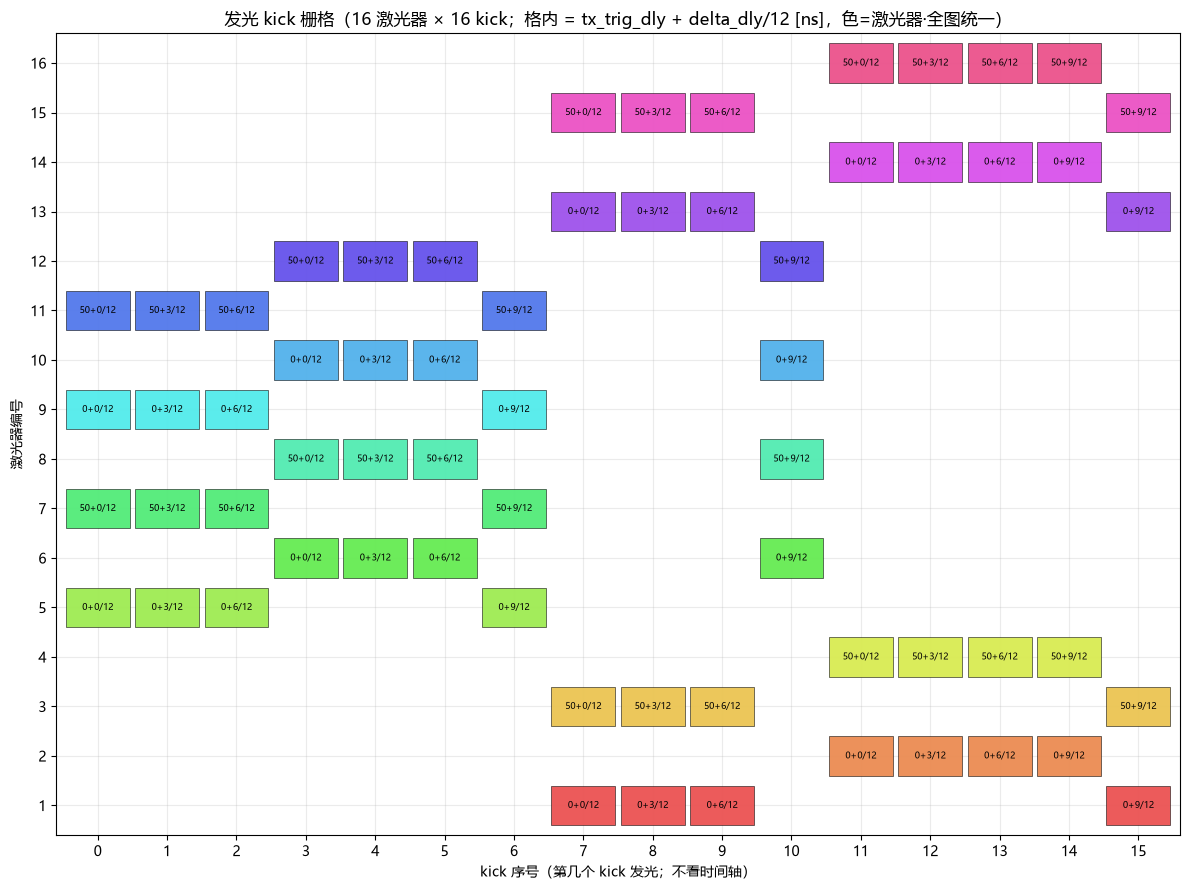

In [4]:
# ============================================================================
# 绘图 1：激光发光 kick 栅格（v13：只留此图，删掉时间轴放大下图）
# ============================================================================
# 【kick 栅格】：x 轴 = kick 序号(0~15)，y 轴 = 激光器；只看"第几 kick 发光"，不看时间轴。
#   格内文字 = 该激光器在该 kick 的编码：tx_trig_dly + delta_dly·(1/12)  写作 "50+3/12"。
#   （delta_dly 取自 Excel 第4行 tdelay，本版计算时全 0；此处仅【展示】其原始编码值。）
# 比例约 4:3（横:纵），更紧凑。
fig, ax = plt.subplots(figsize=(12, 9))

# 每个激光器在每个 kick 是否发光：画方块 + 标编码。颜色用全局统一 laser_color()。
for e in firings:
    col = laser_color(e["laser"])
    ax.add_patch(plt.Rectangle((e["kick"] - 0.46, e["laser"] - 0.40), 0.92, 0.80,
                               facecolor=col, edgecolor="k", linewidth=0.4, alpha=0.95, zorder=2))
    # 编码标注：tx + delta/12（delta 取该 kick 的 Excel tdelay 原值，仅展示）
    _dd = tdelay_A.get(e["kick"], 0)
    ax.text(e["kick"], e["laser"], f"{e['tx']}+{_dd}/12", fontsize=6.5, ha="center", va="center",
            color="k", zorder=3)
# 栅格线
ax.set_xticks(range(16)); ax.set_yticks(laser_ids)
ax.set_xlim(-0.6, 15.6); ax.set_ylim(0.4, N_LASERS + 0.6)
ax.set_xlabel("kick 序号（第几个 kick 发光；不看时间轴）")
ax.set_ylabel("激光器编号")
ax.set_title(f"发光 kick 栅格（{N_LASERS} 激光器 × 16 kick；格内 = tx_trig_dly + delta_dly/12 [ns]，色=激光器·全图统一）")
ax.grid(alpha=0.25, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


In [5]:
# ============================================================================
# 核心检测：对给定物体距离 D，记录所有回波被各激光器接收的情况
# ============================================================================
def detect_echoes(D):
    """对距离 D 处的单个物体，返回所有"被记录的回波"列表。

    每条记录（dict）字段：
      emit_laser / emit_kick : 回波由哪个激光器、哪次 kick 发出
      recv_laser / recv_kick : 被哪个激光器、在它哪次 kick 的 TOF 窗里收到
      target_D               : 物体真实距离 [m]
      true_tof               : 真实飞行时间 2D/c [s]
      t_echo                 : 回波到达绝对时刻 [s]
      rec_tof                : 记录的飞行时间 = t_echo − t_ref_收 [s]
      rec_dist               : 记录的距离 = rec_tof·c/2 [m]（鬼影会 ≠ D）
      is_true                : 是否真回波（发==收 且 同一 kick）
      negligible             : 该串扰是否【空间可忽略】(编号间隔>CROSSTALK_MAX_GAP)；真回波恒 False
    """
    t_tof = 2.0 * D / C_LIGHT
    recs = []
    for e in firings:                       # 每个发射事件
        t_echo = e["t_fire"] + t_tof
        for w in firings:                   # 检查每个接收窗（含自己）
            if w["t_fire"] <= t_echo <= w["t_fire"] + TOF_WINDOW:
                rec_tof = t_echo - w["t_ref"]
                is_true = (e["laser"] == w["laser"] and e["kick"] == w["kick"])
                recs.append({
                    "emit_laser": e["laser"], "emit_kick": e["kick"],
                    "recv_laser": w["laser"], "recv_kick": w["kick"],
                    "target_D": D, "true_tof": t_tof, "t_echo": t_echo,
                    "rec_tof": rec_tof, "rec_dist": rec_tof * C_LIGHT / 2.0,
                    "is_true": is_true,
                    # 空间可忽略：非真回波 且 收发编号间隔 > 阈值。真回波恒 False。
                    "negligible": (not is_true) and crosstalk_negligible(e["laser"], w["laser"]),
                })
    return recs


# ---- 快速自检：一个近距离物体 ----
_D = 30.0
_r = detect_echoes(_D)
_nt = sum(1 for x in _r if x["is_true"])
_ng = sum(1 for x in _r if x["negligible"])
_gkeep = sum(1 for x in _r if (not x["is_true"]) and (not x["negligible"]))
print(f"自检 D={_D:.0f}m：共 {len(_r)} 条记录，其中真回波 {_nt} 条、鬼影 {len(_r)-_nt} 条")
print(f"  鬼影里：空间可忽略(编号间隔>{CROSSTALK_MAX_GAP}) {_ng} 条、不可忽略 {_gkeep} 条")
print(f"  真实 tof = {2*_D/C_LIGHT*1e9:.2f} ns（真实距离 {_D:.1f} m）")
if _r:
    _g = [x for x in _r if not x["is_true"]]
    _gd = sorted(set(round(x["rec_dist"], 2) for x in _g))
    print(f"  鬼影出现的记录距离（去重）：{_gd} m")


自检 D=30m：共 256 条记录，其中真回波 64 条、鬼影 192 条
  鬼影里：空间可忽略(编号间隔>2) 112 条、不可忽略 80 条
  真实 tof = 200.14 ns（真实距离 30.0 m）
  鬼影出现的记录距离（去重）：[22.51, 30.0, 37.49] m


In [6]:
# ============================================================================
# 验证：几个特定距离的鬼影分布（仿真 vs 解析预测）
# ============================================================================
# 选点用意：
#   D=30m  (2D/c=200ns)  —— 远小于窗，只有同 kick 串扰；tx=0/50ns → 预期 ±7.5m 鬼影
#   D=150m (2D/c=1000ns) —— 窗内正常测距；同 kick 串扰
#   D=330m (2D/c=2200ns) —— 恰好 = 1 个 KICK_SPACING！真回波超窗丢失，混叠进下一 kick
#   D=480m (2D/c=3202ns) —— 超窗，混叠进下一 kick 窗；预期伪装成 ~150m
D_TEST = [30.0, 150.0, 330.0, 480.0]

def dist_offset_from_tx(dtx_ns):
    """tx 差 dtx(ns) 对应的鬼影距离偏移 [m]。"""
    return dtx_ns * NS * C_LIGHT / 2.0

print("=" * 84)
print("特定距离验证（KICK_SPACING={:.1f}μs, TOF_WINDOW={:.0f}ns, D_UNAMBIG={:.0f}m）".format(
    KICK_SPACING*1e6, TOF_WINDOW*1e9, D_UNAMBIG))
print("=" * 84)

verify_cache = {}
for D in D_TEST:
    recs = detect_echoes(D)
    verify_cache[D] = recs
    n_true = sum(1 for x in recs if x["is_true"])
    n_ghost = len(recs) - n_true
    tof_ns = 2*D/C_LIGHT*1e9

    # 记录距离直方（按 0.1m 归并去重，看鬼影落在哪些"假距离"）
    from collections import Counter
    dist_cnt = Counter(round(x["rec_dist"], 1) for x in recs)
    ghost_cnt = Counter(round(x["rec_dist"], 1) for x in recs if not x["is_true"])

    print(f"\n【D = {D:.0f} m】 真实 tof = {tof_ns:.1f} ns  (2D/c)")
    print(f"  记录总数 {len(recs)}：真回波 {n_true}，鬼影 {n_ghost}")
    if 2*D/C_LIGHT > TOF_WINDOW:
        print(f"  ⚠ 2D/c={tof_ns:.0f}ns > 窗{TOF_WINDOW*1e9:.0f}ns  → 真回波超窗，本距离【无法被正确测距】(n_true应=0)")
    print(f"  各记录距离(≥1条) : " +
          ", ".join(f"{d}m×{c}" for d, c in sorted(dist_cnt.items())))

    # ---- 解析预测 ----
    if D <= D_UNAMBIG:
        # 同 kick 串扰：发/收 tx 差 ∈ {-50,0,+50} → 距离偏移 {-7.5,0,+7.5} m
        preds = sorted(set(round(D + dist_offset_from_tx(dtx), 1) for dtx in (-50, 0, 50)))
        print(f"  解析预测(同kick, tx差±50ns→±7.5m)：鬼影/真值应落在 {preds} m")
    else:
        # 混叠：回波落入下一个 kick 窗，rec_tof = 2D/c − KICK_SPACING (+ tx差)
        base_alias_ns = (2*D/C_LIGHT - KICK_SPACING) * 1e9
        base_alias_m = base_alias_ns * NS * C_LIGHT / 2.0
        preds = sorted(set(round(base_alias_m + dist_offset_from_tx(dtx), 1) for dtx in (-50, 0, 50)))
        print(f"  解析预测(混叠到下一kick: 2D/c−KICK_SPACING={base_alias_ns:.0f}ns)：鬼影应落在 {preds} m")

    # ---- 比对 ----
    sim_ghost = sorted(ghost_cnt.keys())
    ok = set(sim_ghost).issubset(set(preds)) or set(preds).issubset(set(sim_ghost + ([round(D,1)] if D<=D_UNAMBIG else [])))
    print(f"  仿真鬼影距离 = {sim_ghost} m   →  与解析预测 {'✔ 一致' if set(sim_ghost)<=set(preds) else '⚠ 需检查'}")


特定距离验证（KICK_SPACING=2.2μs, TOF_WINDOW=2000ns, D_UNAMBIG=300m）

【D = 30 m】 真实 tof = 200.1 ns  (2D/c)
  记录总数 256：真回波 64，鬼影 192
  各记录距离(≥1条) : 22.5m×64, 30.0m×128, 37.5m×64
  解析预测(同kick, tx差±50ns→±7.5m)：鬼影/真值应落在 [22.5, 30.0, 37.5] m
  仿真鬼影距离 = [22.5, 30.0, 37.5] m   →  与解析预测 ✔ 一致

【D = 150 m】 真实 tof = 1000.7 ns  (2D/c)
  记录总数 256：真回波 64，鬼影 192
  各记录距离(≥1条) : 142.5m×64, 150.0m×128, 157.5m×64
  解析预测(同kick, tx差±50ns→±7.5m)：鬼影/真值应落在 [142.5, 150.0, 157.5] m
  仿真鬼影距离 = [142.5, 150.0, 157.5] m   →  与解析预测 ✔ 一致

【D = 330 m】 真实 tof = 2201.5 ns  (2D/c)
  记录总数 180：真回波 0，鬼影 180
  ⚠ 2D/c=2202ns > 窗2000ns  → 真回波超窗，本距离【无法被正确测距】(n_true应=0)
  各记录距离(≥1条) : 0.2m×120, 7.7m×60
  解析预测(混叠到下一kick: 2D/c−KICK_SPACING=2ns)：鬼影应落在 [-7.3, 0.2, 7.7] m
  仿真鬼影距离 = [0.2, 7.7] m   →  与解析预测 ✔ 一致

【D = 480 m】 真实 tof = 3202.2 ns  (2D/c)
  记录总数 240：真回波 0，鬼影 240
  ⚠ 2D/c=3202ns > 窗2000ns  → 真回波超窗，本距离【无法被正确测距】(n_true应=0)
  各记录距离(≥1条) : 142.7m×60, 150.2m×120, 157.7m×60
  解析预测(混叠到下一kick: 2D/c−KICK_SPACING=1002ns)：鬼影应落在 [142.7, 150.

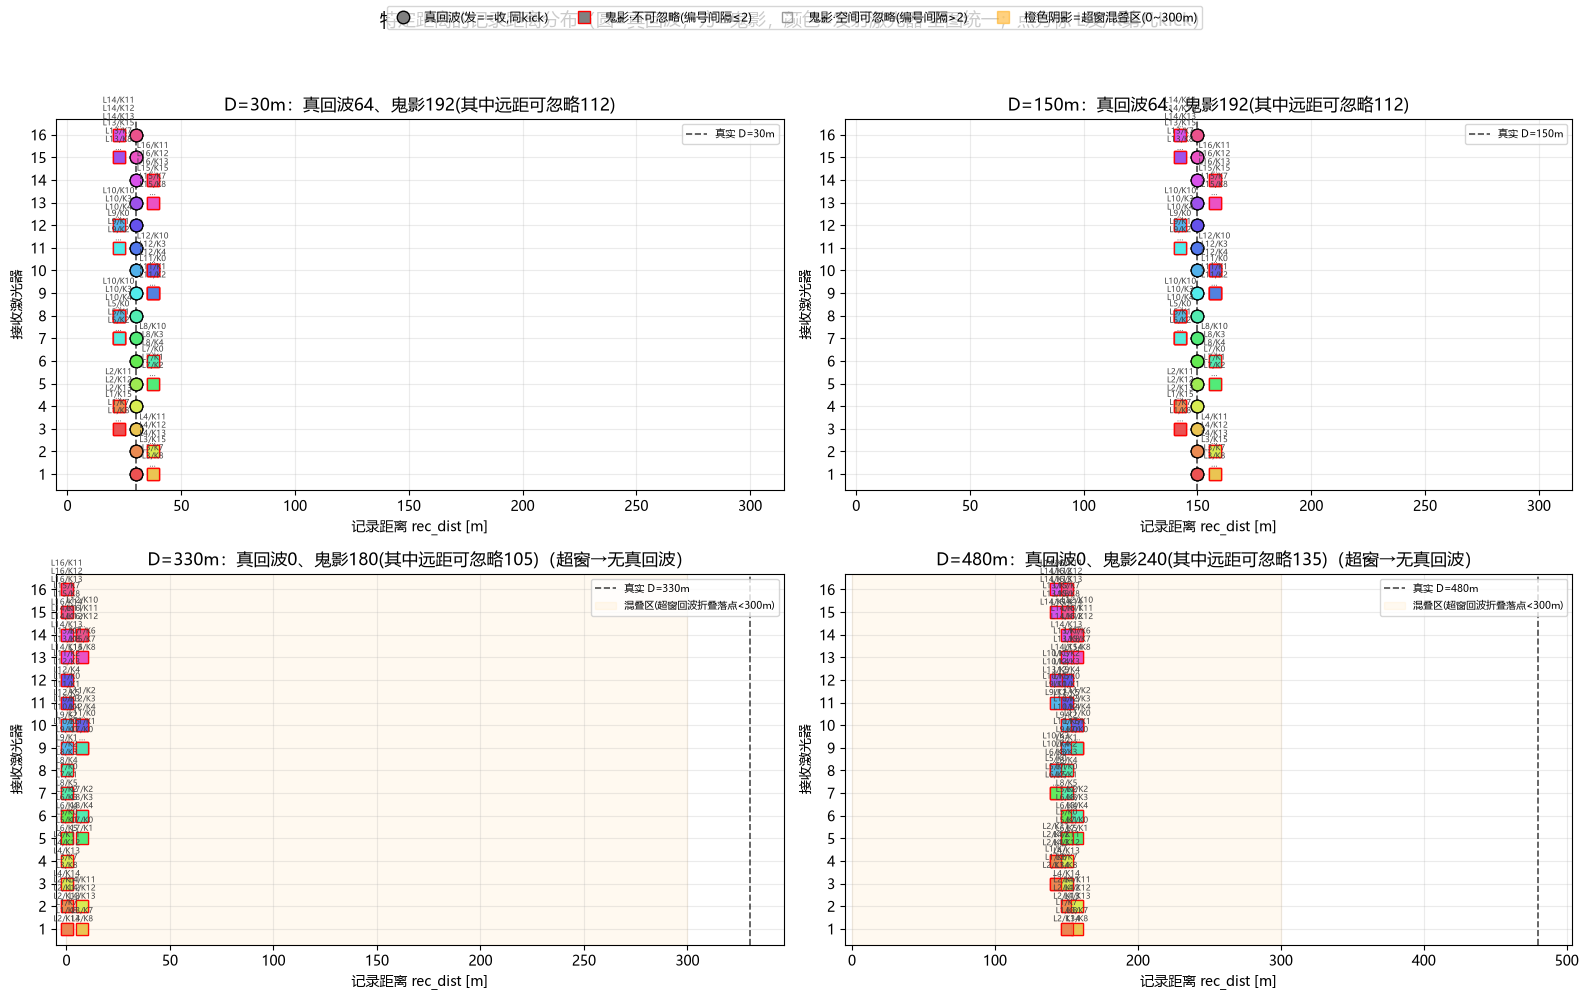


鬼影来源明细：每条鬼影 = 某激光器某 kick 发射的回波，被别的接收器记录成错误距离

【D=30m】 鬼影 192 条（按 记录距离→接收器 归并；显示 发射来源×次数）
      记录距离    接收器  发射来源(L发/K第几kick × 次数)
  -------- ------  --------------------------------------------------
     22.5m     L3  L1/K15, L1/K7, L1/K8, L1/K9, L13/K15, L13/K7, L13/K8, L13/K9
     22.5m     L4  L14/K11, L14/K12, L14/K13, L14/K14, L2/K11, L2/K12, L2/K13, L2/K14
     22.5m     L7  L5/K0, L5/K1, L5/K2, L5/K6, L9/K0, L9/K1, L9/K2, L9/K6
     22.5m     L8  L10/K10, L10/K3, L10/K4, L10/K5, L6/K10, L6/K3, L6/K4, L6/K5
     22.5m    L11  L5/K0, L5/K1, L5/K2, L5/K6, L9/K0, L9/K1, L9/K2, L9/K6
     22.5m    L12  L10/K10, L10/K3, L10/K4, L10/K5, L6/K10, L6/K3, L6/K4, L6/K5
     22.5m    L15  L1/K15, L1/K7, L1/K8, L1/K9, L13/K15, L13/K7, L13/K8, L13/K9
     22.5m    L16  L14/K11, L14/K12, L14/K13, L14/K14, L2/K11, L2/K12, L2/K13, L2/K14
     30.0m     L1  L13/K15, L13/K7, L13/K8, L13/K9
     30.0m     L2  L14/K11, L14/K12, L14/K13, L14/K14
     30.0m     L3  L15/K15, L15/K7, L15/K8, L15/K9
   

In [7]:
# ============================================================================
# 绘图 2：特定距离的"记录距离"分布图（横轴=算出的距离，纵轴=接收激光器）
# ============================================================================
# 圆=真回波（发==收，同kick），方=鬼影；颜色=发射激光器。
# 竖虚线=物体真实距离 D。橙色阴影=混叠区(超窗后回波折叠回来的位置)。
# v11：① 每条鬼影在点旁标注来源"L发/K第几kick"；② 底部打印每条鬼影的完整来源明细表；
#      ③ shaded 超窗混叠区加图例文字说明。
from collections import defaultdict

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, D in zip(axes.ravel(), D_TEST):
    recs = verify_cache[D]
    # 按 (接收器, 记录距离四舍五入) 聚合，便于把同簇来源标在一起，避免文字互相压盖
    cluster = defaultdict(list)     # {(recv_laser, round(rec_dist,1)): [记录,...]}
    for x in recs:
        cluster[(x["recv_laser"], round(x["rec_dist"], 1))].append(x)

    for x in recs:
        col = laser_color(x["emit_laser"])          # v12 统一配色（同一激光器恒定同色）
        if x["is_true"]:
            ax.plot(x["rec_dist"], x["recv_laser"], "o", color=col, ms=9,
                    mec="k", mew=0.8, zorder=6)
        elif x["negligible"]:
            # 空间可忽略鬼影：空心灰点、半透明（视觉弱化）
            ax.plot(x["rec_dist"], x["recv_laser"], "s", mfc="none", mec="0.6",
                    mew=0.9, ms=7, zorder=4, alpha=0.6)
        else:
            ax.plot(x["rec_dist"], x["recv_laser"], "s", color=col, ms=8,
                    mec="red", mew=0.9, zorder=5, alpha=0.9)

    # 每个"鬼影簇"标注来源（L发/K第几kick）；簇内多来源用换行列出。只标"不可忽略"的来源。
    for (rlid, rd), xs in cluster.items():
        ghosts = [g for g in xs if (not g["is_true"]) and (not g["negligible"])]
        if not ghosts:
            continue
        srcs = sorted(set(f"L{g['emit_laser']}/K{g['emit_kick']}" for g in ghosts))
        # 太多来源只标前 3 个 + 省略号，完整清单见下方打印
        txt = "\n".join(srcs[:3]) + ("\n…" if len(srcs) > 3 else "")
        ax.annotate(txt, (rd, rlid), fontsize=5.5, ha="center", va="bottom",
                    xytext=(0, 4), textcoords="offset points", color="0.25", zorder=7)

    ax.axvline(D, color="k", ls="--", lw=1.2, alpha=0.7, label=f"真实 D={D:.0f}m")
    if D > D_UNAMBIG:
        ax.axvspan(0, D_UNAMBIG, color="orange", alpha=0.06,
                   label=f"混叠区(超窗回波折叠落点<300m)")
    n_true = sum(1 for x in recs if x["is_true"])
    n_negl = sum(1 for x in recs if x["negligible"])
    ax.set_xlabel("记录距离 rec_dist [m]"); ax.set_ylabel("接收激光器")
    ax.set_yticks(laser_ids); ax.set_ylim(0.3, N_LASERS + 0.7)
    ax.set_xlim(-5, max(D_UNAMBIG, D) * 1.05)
    ax.set_title(f"D={D:.0f}m：真回波{n_true}、鬼影{len(recs)-n_true}(其中远距可忽略{n_negl})"
                 + ("（超窗→无真回波）" if D > D_UNAMBIG else ""))
    ax.legend(fontsize=7.5, loc="upper right"); ax.grid(alpha=0.25)

# 图例说明
from matplotlib.lines import Line2D
legend_el = [
    Line2D([0], [0], marker="o", color="w", mfc="gray", mec="k", ms=9, label="真回波(发==收,同kick)"),
    Line2D([0], [0], marker="s", color="w", mfc="gray", mec="red", ms=8, label="鬼影·不可忽略(编号间隔≤%d)" % CROSSTALK_MAX_GAP),
    Line2D([0], [0], marker="s", color="w", mfc="none", mec="0.6", ms=7, label="鬼影·空间可忽略(编号间隔>%d)" % CROSSTALK_MAX_GAP),
    Line2D([0], [0], marker="s", color="w", mfc="orange", mec="orange", ms=9, alpha=0.5,
           label="橙色阴影=超窗混叠区(0~300m)"),
]
fig.legend(handles=legend_el, loc="upper center", ncol=4, fontsize=8.5)
plt.suptitle("特定距离的记录距离分布（圆=真回波，方=鬼影，颜色=发射激光器·全图统一；点旁标 L发/K第几kick）",
             y=0.995, fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ---- 鬼影来源完整明细打印（图上标不下的在这里逐条列出）----
print("\n" + "=" * 88)
print("鬼影来源明细：每条鬼影 = 某激光器某 kick 发射的回波，被别的接收器记录成错误距离")
print("=" * 88)
for D in D_TEST:
    recs = verify_cache[D]
    ghosts = [x for x in recs if not x["is_true"]]
    print(f"\n【D={D:.0f}m】 鬼影 {len(ghosts)} 条（按 记录距离→接收器 归并；显示 发射来源×次数）")
    # 按 (记录距离, 接收器) 归并，列出发射来源
    agg = defaultdict(lambda: defaultdict(int))   # {(rec_dist, recv): {发射源: 次数}}
    for g in ghosts:
        agg[(round(g["rec_dist"],1), g["recv_laser"])][f"L{g['emit_laser']}/K{g['emit_kick']}"] += 1
    print(f"  {'记录距离':>8} {'接收器':>6}  发射来源(L发/K第几kick × 次数)")
    print(f"  {'-'*8} {'-'*6}  {'-'*50}")
    for (rd, rlid) in sorted(agg.keys()):
        srcs = agg[(rd, rlid)]
        src_str = ", ".join(f"{s}×{n}" if n > 1 else s for s, n in sorted(srcs.items()))
        print(f"  {rd:>7.1f}m {('L'+str(rlid)):>6}  {src_str}")


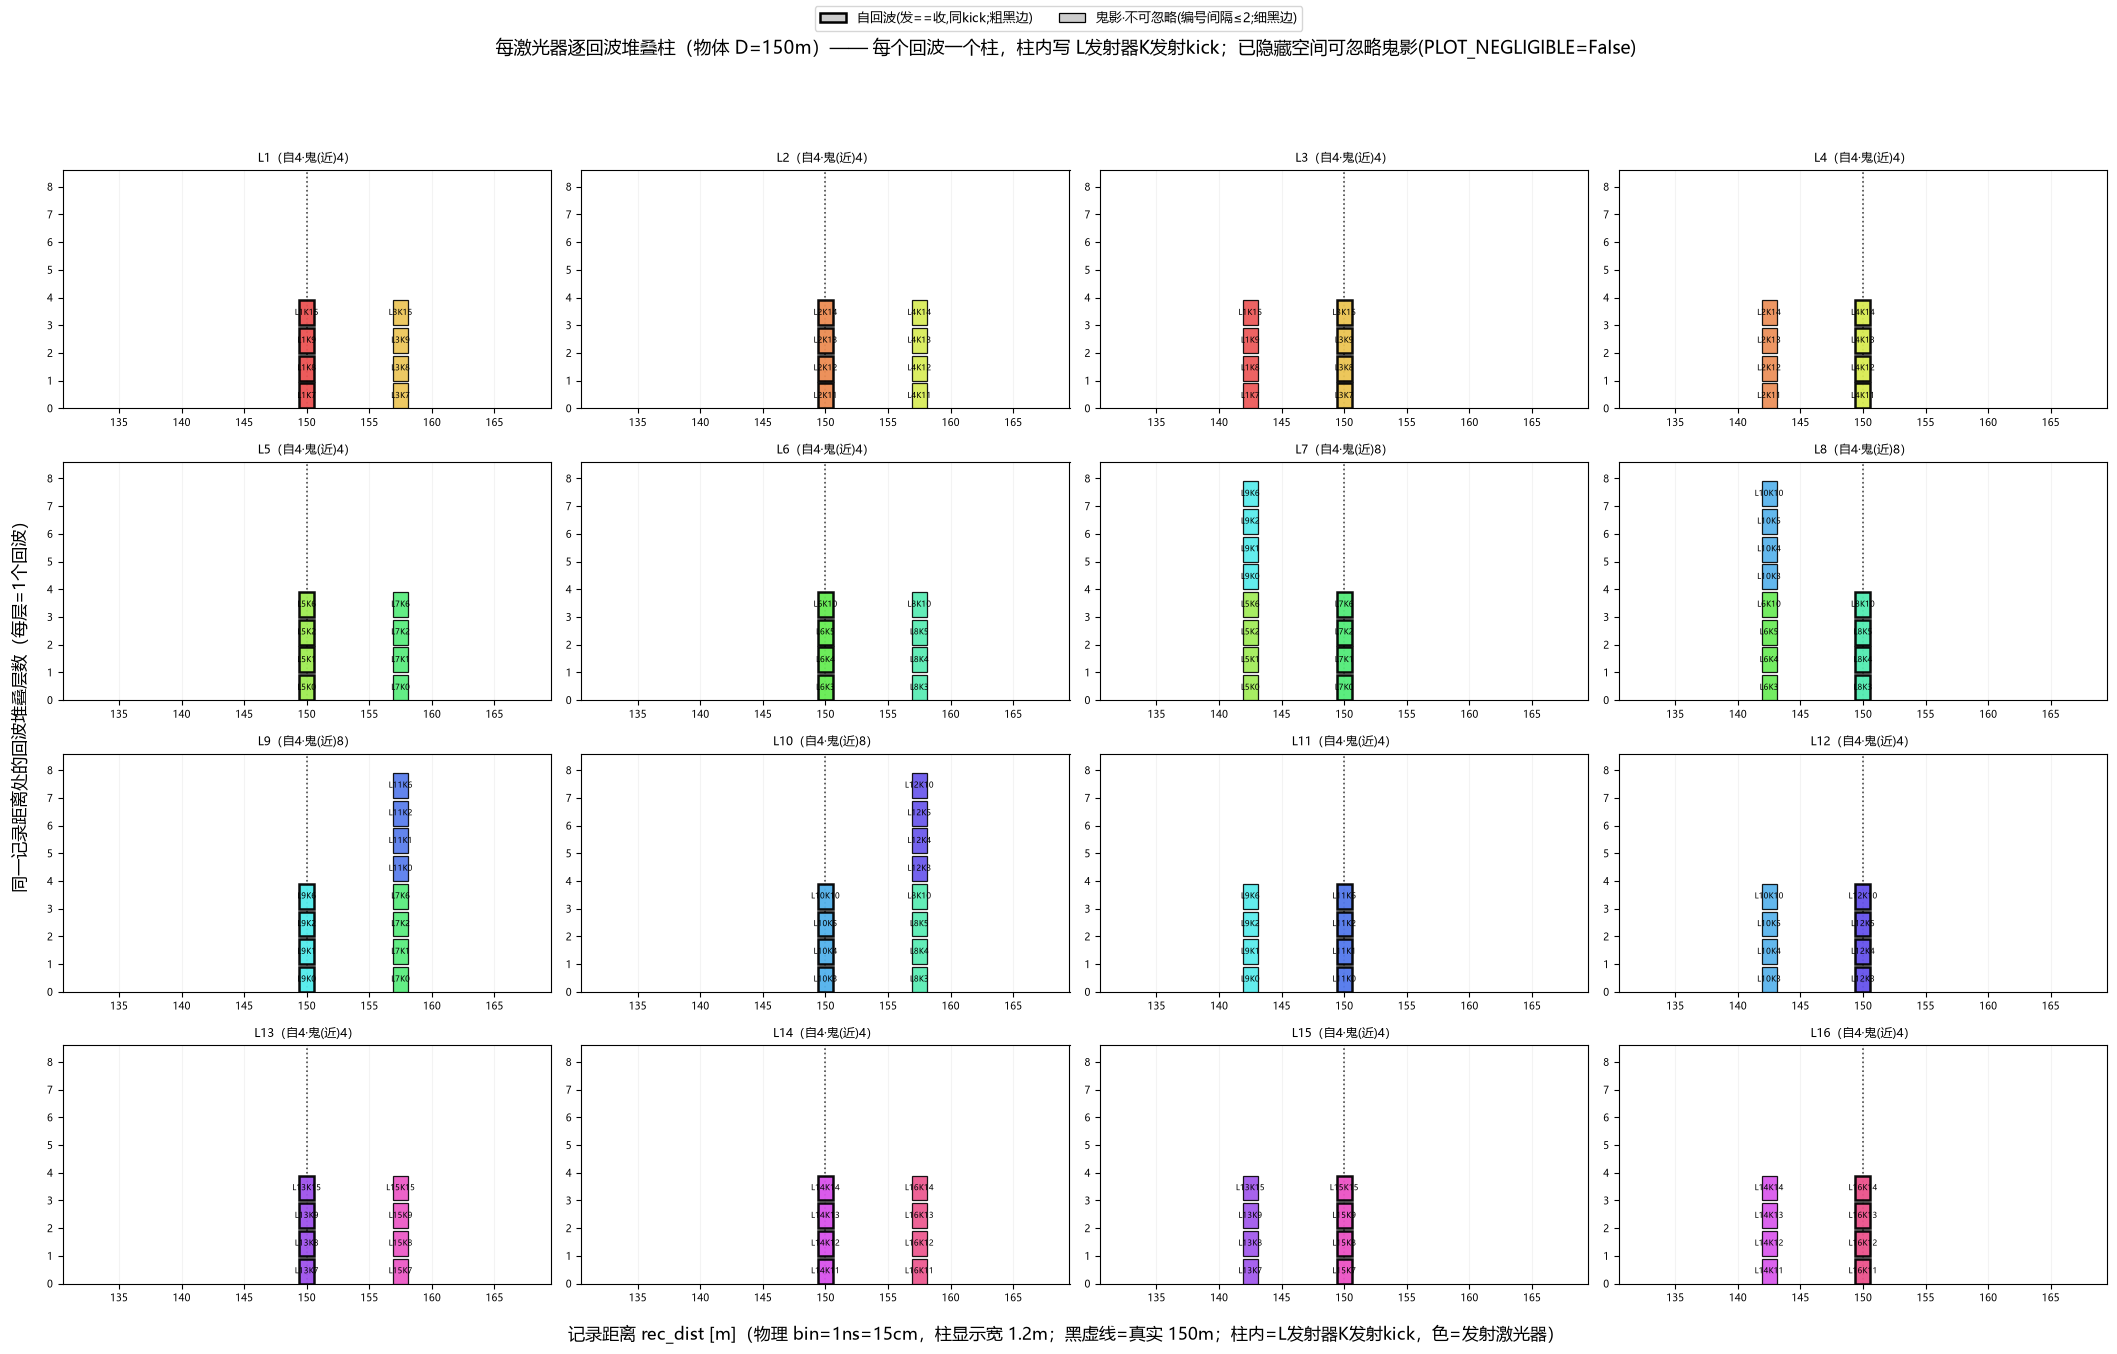

每激光器累加 TOF（D=150m）汇总：
  Laser   收到   自回波   鬼影       自回波距离[m] 鬼影距离[m]
  L   1   16     4   12        [150.0] [150.0, 157.5]
  L   2   16     4   12        [150.0] [150.0, 157.5]
  L   3   16     4   12        [150.0] [142.5, 150.0]
  L   4   16     4   12        [150.0] [142.5, 150.0]
  L   5   16     4   12        [150.0] [150.0, 157.5]
  L   6   16     4   12        [150.0] [150.0, 157.5]
  L   7   16     4   12        [150.0] [142.5, 150.0]
  L   8   16     4   12        [150.0] [142.5, 150.0]
  L   9   16     4   12        [150.0] [150.0, 157.5]
  L  10   16     4   12        [150.0] [150.0, 157.5]
  L  11   16     4   12        [150.0] [142.5, 150.0]
  L  12   16     4   12        [150.0] [142.5, 150.0]
  L  13   16     4   12        [150.0] [150.0, 157.5]
  L  14   16     4   12        [150.0] [150.0, 157.5]
  L  15   16     4   12        [150.0] [142.5, 150.0]
  L  16   16     4   12        [150.0] [142.5, 150.0]

每条回波完整溯源（物体真实 D=150m；类型：自=自回波/鬼=串扰鬼影；可忽略=空间上编号间隔>2）
    接收器   类型  

In [8]:
# ============================================================================
# 绘图 3：每个激光器的【4 次发光累加 TOF 波形】—— 逐回波堆叠柱
# ============================================================================
# 每一个回波（不同 kick 要区分开）都画成一个【带边框的柱】，同一记录距离处上下叠加；
#   柱内写"LxKx"（发射激光器 + 发射 kick），颜色=发射激光器。
#   自回波=粗黑边；鬼影(不可忽略)=细黑边；鬼影(空间可忽略, 编号间隔>阈值)=灰虚线边+半透明。
# v13：可忽略鬼影(编号间隔 > CROSSTALK_MAX_GAP)是否画出来，由 PLOT_NEGLIGIBLE 开关控制（默认不画）。
PLOT_NEGLIGIBLE = False        # True: 画出空间可忽略鬼影；False(默认): 不画（图更干净）

D_CUMUL = 150.0
recs_c = detect_echoes(D_CUMUL)

BIN_M = 0.15                                   # 物理 bin 宽 [m]（=1ns 往返）
CELL_W = 1.2                                   # 每个回波柱的显示宽度 [m]（仅显示，不改物理分辨率）

# 按开关决定要画哪些回波（可忽略的默认剔除）
recs_plot = [x for x in recs_c if PLOT_NEGLIGIBLE or not x["negligible"]]

# 回波落点范围 -> 统一 x 轴聚焦区间（用实际要画的点）
_all_d = np.array([x["rec_dist"] for x in recs_plot])
if _all_d.size:
    _xlo = max(0.0, _all_d.min() - 12); _xhi = min(D_UNAMBIG, _all_d.max() + 12)
else:
    _xlo, _xhi = 0.0, D_UNAMBIG


def _stack_key(rec_dist):
    """把记录距离量化到 0.15m 物理 bin，用作"同一距离"的堆叠键（同 bin 的回波上下叠）。"""
    return round(rec_dist / BIN_M)


fig, axes = plt.subplots(4, 4, figsize=(22, 14))
_ymax_all = 1
for idx, lid in enumerate(laser_ids):
    ax = axes[idx // 4][idx % 4]
    mine = [x for x in recs_plot if x["recv_laser"] == lid]
    # 同一记录距离 bin 内，按 (类型, 发射器, kick) 排个稳定序，再从下往上堆叠
    from collections import defaultdict as _dd
    stacks = _dd(list)
    for x in sorted(mine, key=lambda x: (not x["is_true"], x["emit_laser"], x["emit_kick"])):
        stacks[_stack_key(x["rec_dist"])].append(x)

    for kbin, items in stacks.items():
        xc = kbin * BIN_M
        for level, x in enumerate(items):
            col = laser_color(x["emit_laser"])
            if x["is_true"]:
                ec, lw, ls, al = "k", 1.8, "solid", 0.95           # 自回波：粗黑边
            elif x["negligible"]:
                ec, lw, ls, al = "0.5", 0.8, (0,(2,1)), 0.45       # 可忽略鬼影：灰虚线+半透明
            else:
                ec, lw, ls, al = "k", 0.9, "solid", 0.9            # 不可忽略鬼影：细黑边
            ax.add_patch(plt.Rectangle((xc - CELL_W/2, level), CELL_W, 0.9,
                                       facecolor=col, edgecolor=ec, linewidth=lw,
                                       linestyle=ls, alpha=al, zorder=3))
            # 柱内写 "LxKx"（发射激光器 + 发射 kick）
            ax.text(xc, level + 0.45, f"L{x['emit_laser']}K{x['emit_kick']}", fontsize=5.5,
                    ha="center", va="center", color="k", zorder=4)
        _ymax_all = max(_ymax_all, len(items))

    ax.axvline(D_CUMUL, color="k", ls=":", lw=1.2, alpha=0.7)
    n_self = sum(1 for x in mine if x["is_true"])
    n_negl = sum(1 for x in mine if x["negligible"])
    n_keep = len(mine) - n_self - n_negl
    ax.set_title(f"L{lid}（自{n_self}·鬼(近){n_keep}" + (f"·鬼(远,可忽略){n_negl}" if PLOT_NEGLIGIBLE else "") + "）", fontsize=8.5)
    ax.set_xlim(_xlo, _xhi)
    ax.tick_params(labelsize=7); ax.grid(alpha=0.15, axis="x")

# 统一 y 轴上限（堆叠层数）
for idx in range(len(laser_ids)):
    axes[idx // 4][idx % 4].set_ylim(0, _ymax_all + 0.6)

fig.text(0.5, 0.045, f"记录距离 rec_dist [m]（物理 bin=1ns=15cm，柱显示宽 {CELL_W}m；黑虚线=真实 {D_CUMUL:.0f}m；柱内=L发射器K发射kick，色=发射激光器）",
         ha="center", fontsize=12)
fig.text(0.02, 0.5, "同一记录距离处的回波堆叠层数（每层=1个回波）", va="center", rotation="vertical", fontsize=12)
# 图例：类别边框说明（可忽略项仅在开启绘制时列出）
from matplotlib.patches import Patch
leg = [
    Patch(facecolor="0.8", edgecolor="k", linewidth=1.8, label="自回波(发==收,同kick;粗黑边)"),
    Patch(facecolor="0.8", edgecolor="k", linewidth=0.9, label="鬼影·不可忽略(编号间隔≤%d;细黑边)" % CROSSTALK_MAX_GAP),
]
if PLOT_NEGLIGIBLE:
    leg.append(Patch(facecolor="0.8", edgecolor="0.5", linewidth=0.8, linestyle="--",
                     label="鬼影·空间可忽略(编号间隔>%d;灰虚线半透明)" % CROSSTALK_MAX_GAP))
fig.legend(handles=leg, loc="upper center", ncol=3, fontsize=9.5)
plt.suptitle(f"每激光器逐回波堆叠柱（物体 D={D_CUMUL:.0f}m）—— 每个回波一个柱，柱内写 L发射器K发射kick"
             + ("" if PLOT_NEGLIGIBLE else "；已隐藏空间可忽略鬼影(PLOT_NEGLIGIBLE=False)"),
             fontsize=13, y=0.975)
plt.tight_layout(rect=[0.03, 0.06, 0.98, 0.93])
plt.show()

print("=" * 76)
print(f"每激光器累加 TOF（D={D_CUMUL:.0f}m）汇总：")
print(f"  {'Laser':>5} {'收到':>4} {'自回波':>5} {'鬼影':>4} {'自回波距离[m]':>14} {'鬼影距离[m]'}")
for lid in laser_ids:
    mine = [x for x in recs_c if x["recv_laser"] == lid]
    d_self = sorted(set(round(x["rec_dist"],1) for x in mine if x["is_true"]))
    d_ghost = sorted(set(round(x["rec_dist"],1) for x in mine if not x["is_true"]))
    print(f"  L{lid:>4d} {len(mine):>4d} "
          f"{sum(1 for x in mine if x['is_true']):>5d} "
          f"{sum(1 for x in mine if not x['is_true']):>4d} "
          f"{str(d_self):>14s} {d_ghost}")

# ---- v12：每条回波的完整溯源明细（含"空间可忽略"标记）----
#   每条回波都回答：来自哪个激光器、它第几 kick 发射、在多少米处反射、被本激光器记录成多少米，
#   以及该串扰是否【空间可忽略】(编号间隔>CROSSTALK_MAX_GAP)。
print("\n" + "=" * 100)
print(f"每条回波完整溯源（物体真实 D={D_CUMUL:.0f}m；类型：自=自回波/鬼=串扰鬼影；可忽略=空间上编号间隔>{CROSSTALK_MAX_GAP}）")
print("=" * 100)
print(f"  {'接收器':>5} {'类型':>4} {'可忽略':>5} | {'发射激光器':>8} {'发射kick':>7} {'反射距离[m]':>11} {'记录距离[m]':>11} {'误差[m]':>8}")
print(f"  {'-'*5} {'-'*4} {'-'*5} | {'-'*8} {'-'*7} {'-'*11} {'-'*11} {'-'*8}")
for lid in laser_ids:
    # 排序：自回波在前；鬼影中不可忽略在前、可忽略在后；再按记录距离
    mine = sorted([x for x in recs_c if x["recv_laser"] == lid],
                  key=lambda x: (not x["is_true"], x["negligible"], x["rec_dist"]))
    for x in mine:
        typ = "自" if x["is_true"] else "鬼"
        negl = "—" if x["is_true"] else ("忽略" if x["negligible"] else "保留")
        err = x["rec_dist"] - x["target_D"]
        print(f"  L{lid:>4d} {typ:>4} {negl:>5} | L{x['emit_laser']:>7d} K{x['emit_kick']:>6d} "
              f"{x['target_D']:>11.1f} {x['rec_dist']:>11.2f} {err:>+8.2f}")


In [9]:
# ============================================================================
# 总结
# ============================================================================
print("=" * 76)
print("crosstalk_sim_v13 总结")
print("=" * 76)
print(f"""
1. 数据源与配置
   - 时序：{EXCEL_FILE} [长焦 / A组]，{N_LASERS} 激光器 × 每个 4 次发光 = {N_FIRE} 发光事件
   - KICK_SPACING = {KICK_SPACING*1e6:.1f} μs，TOF_WINDOW = {TOF_WINDOW*1e9:.0f} ns
   - 最大无模糊距离 D_UNAMBIG = {D_UNAMBIG:.0f} m（超此距离真回波超窗 → 距离混叠鬼影）

2. 编码开关（本版）
   - tx_trig_dly : {'启用(Excel 0/50ns)' if ENC['use_tx_trig_dly'] else '关(全0)'}
   - delta_dly   : {'启用' if ENC['use_delta_dly'] else '关(全0，接口保留)'}
   - fpga_jitter : {'启用' if ENC['use_fpga_jitter'] else '关(全0，接口保留)'}

3. 核心模型
   - 每次发光 = 一次发射 + 一个 {TOF_WINDOW*1e9:.0f}ns 接收窗
   - 回波被每个激光器接收；落窗即记录 rec_tof = t_echo − t_ref_收
   - is_true = (发==收 且 同一 kick)；其余为鬼影

4. 验证结论（见上）
   - D≤300m：同 kick 串扰，tx=0/50ns 造成 ±7.5m 编码残差鬼影
   - D>300m：真回波超窗丢失，回波混叠进下一 kick 窗 → 伪装成近距离鬼影

5. 输出（v13 起不落地 PNG，仅在 notebook 内展示三张图）
   - 图1 发光 kick 栅格（格内 tx+delta/12，色=激光器）
   - 图2 4 个测试距离的记录距离分布（鬼影来源标注 + 可忽略串扰弱化）
   - 图3 每激光器逐回波堆叠柱（柱内写 LxKx，PLOT_NEGLIGIBLE 控制是否画可忽略鬼影）

6. 下一步（未做）
   - 打开 fpga_jitter（8ns 随机）看鬼影是否被打散
   - 全距离扫描 + 消鬼影算法（目标噪点率 10ppm）
   - 加入第二个模组 / 雷达对射
""")


crosstalk_sim_v13 总结

1. 数据源与配置
   - 时序：Elephant 时序表.xlsx [长焦 / A组]，16 激光器 × 每个 4 次发光 = 64 发光事件
   - KICK_SPACING = 2.2 μs，TOF_WINDOW = 2000 ns
   - 最大无模糊距离 D_UNAMBIG = 300 m（超此距离真回波超窗 → 距离混叠鬼影）

2. 编码开关（本版）
   - tx_trig_dly : 启用(Excel 0/50ns)
   - delta_dly   : 关(全0，接口保留)
   - fpga_jitter : 关(全0，接口保留)

3. 核心模型
   - 每次发光 = 一次发射 + 一个 2000ns 接收窗
   - 回波被每个激光器接收；落窗即记录 rec_tof = t_echo − t_ref_收
   - is_true = (发==收 且 同一 kick)；其余为鬼影

4. 验证结论（见上）
   - D≤300m：同 kick 串扰，tx=0/50ns 造成 ±7.5m 编码残差鬼影
   - D>300m：真回波超窗丢失，回波混叠进下一 kick 窗 → 伪装成近距离鬼影

5. 输出（v13 起不落地 PNG，仅在 notebook 内展示三张图）
   - 图1 发光 kick 栅格（格内 tx+delta/12，色=激光器）
   - 图2 4 个测试距离的记录距离分布（鬼影来源标注 + 可忽略串扰弱化）
   - 图3 每激光器逐回波堆叠柱（柱内写 LxKx，PLOT_NEGLIGIBLE 控制是否画可忽略鬼影）

6. 下一步（未做）
   - 打开 fpga_jitter（8ns 随机）看鬼影是否被打散
   - 全距离扫描 + 消鬼影算法（目标噪点率 10ppm）
   - 加入第二个模组 / 雷达对射



---

# v20 新增部分

---

# crosstalk mark（XM）算法详解

## 0. 一句话

**串扰只出现在个别某一次发光里，真目标每一次发光都在。**

---

## 1. 我们手上有什么波形

一个激光器（比如 L5）在一个 sync 内发 **4 次光**（4 个 kick）。
v13 已经算出「每一次发光收到了哪些回波、各自算成多少米」，
v20 把它们**按 1 ns 一个 bin 落成波形**，于是每个激光器手上有：

| 波形 | 怎么来的 | 硬件里叫什么 |
|---|---|---|
| `shot[0..3]` | 第 0~3 次发光**各自**的 TOF 波形，**分别留存** | 单次测量结果 |
| `hist_add` | 4 条 shot **逐 bin 相加** | `hist_add` |
| `hist_max` | 4 条 shot **逐 bin 取最大值** | `hist_max` |

---

## 2. 判据（就是你要求的那一条）

$$\boxed{\;\text{hist\_max}[b] \times \texttt{xm\_ratio} \;>\; \text{hist\_add}[b]
\;\Longrightarrow\; \text{这个峰是串扰，丢弃}\;}$$

`xm_ratio` 默认取 **1.6**。

### 为什么只要存 `hist_max`，不用真的比较 4 条 shot

你的原话是「**某次**的某个峰 × ratio > hist_add 就判串扰」。
对同一个 bin，4 次里**只要有一次**满足就成立；而 4 个数里最容易满足的显然是**最大的那个**。
所以

$$\exists s:\; \text{shot}_s[b]\times r > \text{hist\_add}[b]
\quad\Longleftrightarrow\quad
\max_s \text{shot}_s[b]\times r > \text{hist\_add}[b]$$

**逐 bin 取最大值就够了 —— 这就是「maxhold」这个名字的由来**，
也是硬件只额外存一份 `hist_max` 而不是存 4 份波形的原因。
（本 notebook 里 4 条 shot 也全都留着，方便画图和核对。）

---

## 3. 一个具体数字例子

L5 的 4 次 shot 里出现了两个东西：

| bin | 是什么 | shot0 | shot1 | shot2 | shot3 | `hist_add` | `hist_max` |
|---|---|---|---|---|---|---|---|
| 1000（=150m） | 真目标回波 | 1 | 1 | 1 | 1 | **4** | **1** |
| 950（=142.5m） | 串扰（只有第 2 次撞上） | 0 | 0 | 1 | 0 | **1** | **1** |

代入判据（`xm_ratio = 1.6`）：

| bin | `hist_max × 1.6` | `hist_add` | 谁大 | 判决 |
|---|---|---|---|---|
| 1000 | 1 × 1.6 = **1.6** | **4** | add 大 | 不是串扰 → **保留** ✔ |
| 950 | 1 × 1.6 = **1.6** | **1** | max×r 大 | 是串扰 → **丢弃** ✔ |

---

## 4. `xm_ratio` 到底该取多少（**最重要的一节**）

把判据两边同除 `hist_max`：

$$\text{判串扰} \iff \frac{\text{hist\_add}[b]}{\text{hist\_max}[b]} < \texttt{xm\_ratio}$$

而 `hist_add / hist_max` 有非常清楚的物理含义 —— **这个峰在几次 shot 里出现过**：

| 情况 | `hist_add / hist_max` |
|---|---|
| 真目标（4 次全在） | **4**（= `N_ACC`） |
| 串扰只在 1 次里出现 | **1** |
| 串扰在 2 次里落到**同一个 bin** | **2** |
| 串扰在 k 次里落到同一个 bin | **k** |

于是 `xm_ratio` 的取值必须夹在中间：

$$\boxed{\;\underbrace{k_{\max}}_{\text{串扰最多重复几次}} \;<\; \texttt{xm\_ratio} \;<\; \underbrace{N_{\rm ACC}}_{\text{累加次数}}\;}$$

| `xm_ratio` | 能滤掉 | 真目标 | 说明 |
|---|---|---|---|
| 1.6（本版默认） | 只出现 1 次的串扰 | 安全（4 > 1.6，裕度 2.5×） | 你给的值 |
| 2.5 | 出现 ≤2 次的串扰 | 安全（4 > 2.5，裕度 1.6×） | 更狠，但保护裕度变小 |
| 3.5 | 出现 ≤3 次的串扰 | 危险 | 真目标少亮一次就被杀 |
| ≥ 4 | — | **真目标也被滤** | 禁止 |

**所以 XM 的全部能力上限，就是这条不等式的宽度，而它由累加次数 N_ACC 决定。**

---

## 5. ⚠ 由此推出：光有 XM 是不够的

串扰的落点（v13 已推导）：

$$\text{rec\_tof}
= \underbrace{\frac{2D}{c}}_{\text{物体距离}}
+ \underbrace{\big(tx_{\text{发}} - tx_{\text{收}}\big)}_{\textbf{码差}}
+ \underbrace{(k_{\text{发}} - k_{\text{收}})\cdot T_{\rm kick}}_{\text{跨 kick 混叠}}$$

而**真回波**：`rec_tof = 2D/c`，**与编码无关**（发射时刻和测距参考零点一起平移，差值抵消）。

现在看 Excel 的现状：**每个激光器在它的 4 个 kick 里 `tx_trig_dly` 是同一个值**（0 或 50 恒定）。
于是对固定的一对 (发, 收)：

- 码差 `tx_发 − tx_收` 每一次都**一模一样**
- ⟹ 同一条串扰 4 次都落到**同一个 bin**
- ⟹ `hist_add = 4`、`hist_max = 1`、`add/max = 4`
- ⟹ **和真目标数值上完全相同，XM 无法区分 → 滤不掉**

**结论：XM 是收割器，tcode 才是播种机。**
tcode 的任务就是让同一条串扰在 4 次 shot 里落到 **4 个不同的 bin**，
把 `add/max` 从 4 打到 1，XM 才有东西可收。

> 详细的 tcode 原理、构造方法和图解见 **`docs/tcode/tcode_scheme.md`**（v21 实装）。
> 本版可以把 `TCODE_MODE` 改成 `"lcg2"`（文档里推荐的两层编码）预览这个效果。

---

## 6. 本版**没有**实装的东西（都在硬件文档里，属于后续加强项）

`docs/xm/xm_crosstalk_mark.md` 里的完整硬件 XM 还有一堆分支，
本版**一律不实装**，避免把简单问题复杂化：

| 硬件分支 | 作用 | 本版为什么不做 |
|---|---|---|
| `XM_baseline_ratio` | 补偿单次基线与累加基线的差 | 理想 δ 模型本底恒为 0，没有基线要补 |
| 按 peak 值分 3 个档位 | 强弱信号用不同阈值 | 只有一条判据时没有分档的必要 |
| `flag0` 的三个计数分支 | 数片段里被标记点的个数 | δ 回波峰宽只有 1 bin，无「个数」可数 |
| `flag2` 峰位比较 | 防止把前后排的两个真目标误判 | 峰宽 1 bin 时峰位恒重合，恒成立 |
| `flag3` / `hist_diff_flag` | hdc 送来的强制通道 | 本模型没有 hdc |
| `hist_max` 每 4 bin 抽 1 | 省存储 | 会把单点 max 摊开到 4 个 bin，δ 模型下反而制造假标记 |
| FIR 平滑 | 真实波形去噪 | 理想波形无噪声 |

需要时再逐条加回来即可，判据主体（第 2 节那一条）不会变。


In [10]:
# ============================================================================
# XM-1  直方图层：把 v13 的"回波记录"落成真正的波形
# ============================================================================
#   每个接收激光器 L 有 N_ACC 次 shot（= 它的 4 个 kick），每次 shot 一条波形；
#   hist_add = 逐 bin 相加     hist_max = 逐 bin 取 4 次里的最大值
# ============================================================================
from collections import Counter
from contextlib import contextmanager

# ---- 直方图参数 ----
HIST_BIN_NS = 1.0                                       # bin 宽 [ns]（1ns 往返 = 15cm）
N_BINS      = int(round(TOF_WINDOW / NS / HIST_BIN_NS)) # = 2000 个 bin，覆盖 0~300m
HIST_BIN_M  = HIST_BIN_NS * NS * C_LIGHT / 2.0          # 1 bin 对应距离 [m]（≈0.1499）

# ---- 回波幅度：本版所有回波都记 1 个计数（最坏情况：串扰和真信号一样强）----
#   留一个按激光器编号间隔衰减的接口，默认不启用。
AMP_MODE   = "unit"                                     # "unit" | "gap"
AMP_BY_GAP = {0: 1.0, 1: 0.50, 2: 0.25}

# ---- 直方图里放不放"空间可忽略"的串扰（编号间隔 > CROSSTALK_MAX_GAP）----
#   False（默认）= 认为这些光根本进不了探测器，与 v13 的 PLOT_NEGLIGIBLE=False 一致。
XTALK_USE_NEGLIGIBLE = False

# ---- 每个激光器的 shot 索引（哪一次 kick 是第几次 shot）；与编码无关，只算一次 ----
SHOT_KICKS = {lid: sorted(k for (l, k, tx) in laser_fires_raw if l == lid) for lid in laser_ids}
SHOT_IDX   = {lid: {k: i for i, k in enumerate(ks)} for lid, ks in SHOT_KICKS.items()}
N_ACC      = int(np.median([len(ks) for ks in SHOT_KICKS.values()]))   # 累加次数


def echo_amp(rec):
    """一条回波在直方图里贡献多少计数。"""
    if AMP_MODE == "unit":
        return 1.0
    return AMP_BY_GAP.get(abs(rec["emit_laser"] - rec["recv_laser"]), 0.0)


def rec_bin(rec):
    """回波落在第几个 bin。"""
    return int(np.clip(np.floor(rec["rec_tof"] / NS / HIST_BIN_NS), 0, N_BINS - 1))


def build_hists(recs):
    """把 detect_echoes() 的记录列表落成波形。

    返回 {laser: {
        shots : (N_ACC, N_BINS)  每次 shot 的波形（全部留存）
        add   : (N_BINS,)        hist_add = 逐 bin 相加
        max   : (N_BINS,)        hist_max = 逐 bin 取最大
        src   : {bin: [rec,...]} 每个 bin 里都有哪些回波（做统计/溯源用）
        kicks : [kick,...]       shot 序号 -> kick 号
    }}
    """
    H   = {lid: np.zeros((len(SHOT_KICKS[lid]), N_BINS)) for lid in laser_ids}
    src = {lid: defaultdict(list) for lid in laser_ids}
    for r in recs:
        if (not r["is_true"]) and r["negligible"] and (not XTALK_USE_NEGLIGIBLE):
            continue                                    # 空间可忽略的光进不了探测器
        lid = r["recv_laser"]
        b   = rec_bin(r)
        H[lid][SHOT_IDX[lid][r["recv_kick"]], b] += echo_amp(r)
        src[lid][b].append(r)
    return {lid: {"shots": H[lid], "add": H[lid].sum(axis=0), "max": H[lid].max(axis=0),
                  "src": src[lid], "kicks": SHOT_KICKS[lid]} for lid in laser_ids}


# ---- tcode 预览接口 ----
#   v21 才正式做编码设计。这里提供几个开关，用来验证"XM 本身实现是对的、瓶颈在编码"。
#   原理与完整图解见 docs/tcode/tcode_scheme.md
#
#   "excel"  = 用 Excel 原值 0/50ns —— **默认，不改用户任何参数**
#   "none"   = 全 0（完全不编码，对照组）
#   "random" = 每个 (laser, kick) 独立随机码
#   "lcg"    = 第一层 线性同余码   c = ((l·(k+1)) mod P)·step
#              → 保证任意一对激光器的【同 kick】码差在各 kick 上互不相同
#   "lcg2"   = 第一层 + 第二层（docs/tcode 推荐方案）
#              c = ((l·(k+1)) mod P)·step + ((k²) mod Pg)·gstep
#              第二项对所有激光器相同：同 kick 码差里抵消（不破坏第一层），
#              自身混叠码差里不抵消（治第一层治不了的那一类）
TCODE_MODE   = "excel"
TCODE_SEED   = 20
TCODE_STEP   = 8        # 码步长 [ns]，必须 ≥ 回波峰宽，否则码不同也落同一 bin
TCODE_LEVELS = 16       # random 模式码级数 → 码范围 0 ~ (LEVELS-1)×STEP ns
TCODE_P      = 17       # 第一层素数模（需 > 激光器数，且与编号差互素）
TCODE_PG     = 9        # 第二层模
TCODE_GSTEP  = 8        # 第二层步长 [ns]
#   码预算：max(tx) 必须 ≤ KICK_SPACING − TOF_WINDOW = 200ns，否则窗会伸进下一个 kick
TCODE_BUDGET_NS = (KICK_SPACING - TOF_WINDOW) / NS


def make_tcode_fn(mode, seed=TCODE_SEED):
    """返回 f(laser_id, kick, tx_excel) -> tx_trig_dly [ns]。"""
    if mode == "excel":
        return lambda lid, k, tx0: tx0
    if mode == "none":
        return lambda lid, k, tx0: 0
    if mode == "random":
        rng = np.random.default_rng(seed)
        tbl = {(lid, k): int(rng.integers(0, TCODE_LEVELS)) * TCODE_STEP
               for (lid, k, tx0) in laser_fires_raw}
        return lambda lid, k, tx0: tbl[(lid, k)]
    if mode == "lcg":
        return lambda lid, k, tx0: ((lid * (k + 1)) % TCODE_P) * TCODE_STEP
    if mode == "lcg2":
        return lambda lid, k, tx0: (((lid * (k + 1)) % TCODE_P) * TCODE_STEP
                                    + ((k * k) % TCODE_PG) * TCODE_GSTEP)
    raise ValueError(f"未知 TCODE_MODE: {mode}")


def check_tcode_budget(mode):
    """码预算检查：max(tx) 超过 kick 间隙就会挤掉后一个 kick 的 TOF 窗。"""
    fn = make_tcode_fn(mode)
    mx = max(fn(lid, k, tx0) for (lid, k, tx0) in laser_fires_raw)
    ok = mx <= TCODE_BUDGET_NS
    print(f"  tcode '{mode:>6}'：max(tx) = {mx:>4d} ns  /  预算 {TCODE_BUDGET_NS:.0f} ns"
          f"  → {'OK' if ok else '!! 超预算，会挤掉下一个 kick 的窗'}")
    return ok


def build_firings_tcode(tcode_fn):
    """用给定 tcode 重建发光事件表（复用 v13 的 fire_time / ref_time，不改 v13 代码）。"""
    fs = []
    for (lid, k, tx0) in laser_fires_raw:
        tx = tcode_fn(lid, k, tx0)
        fs.append({"laser": lid, "kick": k, "tx": tx,
                   "t_fire": fire_time(lid, k, tx), "t_ref": ref_time(lid, k, tx)})
    fs.sort(key=lambda e: e["t_fire"])
    return fs


@contextmanager
def use_firings(fr):
    """临时把全局 firings 换成 fr，让 v13 的 detect_echoes() 直接可用。用完自动还原。"""
    global firings
    old = firings
    firings = fr
    try:
        yield
    finally:
        firings = old


# ---- 自检：看 D_CUMUL（v13 里用的 150m）处 L1 的波形 ----
XM_DEMO_D = D_CUMUL                       # 沿用 v13 cell9 的距离，便于对照
hists = build_hists(detect_echoes(XM_DEMO_D))

print("tcode 码预算检查（max(tx) 必须 ≤ kick 间隙，否则窗会伸进下一个 kick）：")
for _m in ["excel", "none", "random", "lcg", "lcg2"]:
    check_tcode_budget(_m)
print()

_lid = laser_ids[0]
_h   = hists[_lid]
_nz  = np.flatnonzero(_h["add"] > 1e-9)
print(f"直方图：{N_BINS} 个 bin × {HIST_BIN_NS:.0f}ns，每激光器 N_ACC = {N_ACC} 次 shot")
print(f"\nD={XM_DEMO_D:.0f}m 时 L{_lid} 的非零 bin：")
print(f"  {'bin':>5} {'距离[m]':>8} | " + " ".join(f"shot{i}" for i in range(len(_h['kicks'])))
      + f" | {'add':>5} {'max':>5} {'add/max':>8}  来源")
for b in _nz:
    col = " ".join(f"{_h['shots'][i, b]:>5.0f}" for i in range(_h["shots"].shape[0]))
    a, m = _h["add"][b], _h["max"][b]
    who = ",".join(sorted(set(("自" if r["is_true"] else "鬼")
                              + f"L{r['emit_laser']}K{r['emit_kick']}" for r in _h["src"][b])))
    print(f"  {b:>5d} {b*HIST_BIN_M:>8.2f} | {col} | {a:>5.0f} {m:>5.0f} {a/max(m,1e-9):>8.2f}  {who}")
print(f"\n  → add/max = 这个峰在几次 shot 里出现过。真目标应为 {N_ACC}，串扰应为 1。")


tcode 码预算检查（max(tx) 必须 ≤ kick 间隙，否则窗会伸进下一个 kick）：
  tcode ' excel'：max(tx) =   50 ns  /  预算 200 ns  → OK
  tcode '  none'：max(tx) =    0 ns  /  预算 200 ns  → OK
  tcode 'random'：max(tx) =  120 ns  /  预算 200 ns  → OK
  tcode '   lcg'：max(tx) =  128 ns  /  预算 200 ns  → OK
  tcode '  lcg2'：max(tx) =  184 ns  /  预算 200 ns  → OK

直方图：2000 个 bin × 1ns，每激光器 N_ACC = 4 次 shot

D=150m 时 L1 的非零 bin：
    bin    距离[m] | shot0 shot1 shot2 shot3 |   add   max  add/max  来源
   1000   149.90 |     1     1     1     1 |     4     1     4.00  自L1K15,自L1K7,自L1K8,自L1K9
   1050   157.39 |     1     1     1     1 |     4     1     4.00  鬼L3K15,鬼L3K7,鬼L3K8,鬼L3K9

  → add/max = 这个峰在几次 shot 里出现过。真目标应为 4，串扰应为 1。


In [11]:
# ============================================================================
# XM-2  crosstalk mark 核心 —— 就是那一条判据，十几行
# ============================================================================
#     hist_max[b] × XM_RATIO > hist_add[b]   →   b 处这个峰是串扰，丢弃
#
#   等价形式： hist_add[b] / hist_max[b] < XM_RATIO
#   物理含义： add/max = 该峰在几次 shot 里出现过；真目标 = N_ACC，串扰 = 1
#   取值约束： 串扰最大重复次数 < XM_RATIO < N_ACC
# ============================================================================
XM_RATIO = 1.6            # 用户设定值（xm_ratio）。改这个就能看到判据松紧的变化


def find_peaks(y, th=0.5):
    """把波形切成峰：连续 > th 的 bin 段。返回 [(start, end), ...]（闭区间）。
       理想 δ 模型下每个非零 bin 自成一个峰；把回波展宽后这里会自动合并成宽峰。"""
    above = np.asarray(y) > th
    if not above.any():
        return []
    idx = np.flatnonzero(above)
    brk = np.flatnonzero(np.diff(idx) > 1)
    return list(zip(np.concatenate(([idx[0]], idx[brk + 1])).tolist(),
                    np.concatenate((idx[brk], [idx[-1]])).tolist()))


def crosstalk_mark(h, ratio=None):
    """对一个激光器的直方图跑 XM。

    返回 dict：
      thresh  : hist_max × ratio          —— 画图用的判据门限曲线
      peaks   : 每个峰的判决明细
      after   : XM 之后的波形（被判串扰的峰整段清零）
      dropped : 被丢掉的峰
    """
    ratio = XM_RATIO if ratio is None else ratio
    add, mx = h["add"], h["max"]
    thresh = mx * ratio                              # ← 判据左边

    after, peaks = add.copy(), []
    for (s, e) in find_peaks(add):
        p        = s + int(np.argmax(add[s:e + 1]))  # 峰顶所在 bin
        add_p    = float(add[p])
        max_p    = float(mx[p])
        is_xtalk = bool(max_p * ratio > add_p)       # ★ 判据 ★
        if is_xtalk:
            after[s:e + 1] = 0.0                     # 丢弃整个峰
        peaks.append({"s": s, "e": e, "peak_bin": p, "dist": p * HIST_BIN_M,
                      "add": add_p, "max": max_p, "ratio": add_p / max(max_p, 1e-9),
                      "is_xtalk": is_xtalk})
    return {"thresh": thresh, "peaks": peaks, "after": after,
            "dropped": [q for q in peaks if q["is_xtalk"]]}


def crosstalk_mark_all(hs, ratio=None):
    return {lid: crosstalk_mark(h, ratio) for lid, h in hs.items()}


xm_res = crosstalk_mark_all(hists)

# ---- 自检：逐峰判决表 ----
print("=" * 92)
print(f"XM 判决表（D={XM_DEMO_D:.0f}m，XM_RATIO={XM_RATIO}，N_ACC={N_ACC}，"
      f"TCODE_MODE='{TCODE_MODE}'）")
print("=" * 92)
print(f"  {'接收器':>5} {'峰距离[m]':>10} {'hist_add':>9} {'hist_max':>9} "
      f"{'max×ratio':>10} {'add/max':>8} {'判决':>6}  该峰里有什么")
print("  " + "-" * 88)
for lid in laser_ids:
    for q in xm_res[lid]["peaks"]:
        who = Counter()
        for b in range(q["s"], q["e"] + 1):
            for r in hists[lid]["src"].get(b, []):
                who["真回波" if r["is_true"] else "鬼影"] += 1
        who_s = " + ".join(f"{k}×{v}" for k, v in sorted(who.items()))
        print(f"  L{lid:>4d} {q['dist']:>10.2f} {q['add']:>9.1f} {q['max']:>9.1f} "
              f"{q['max']*XM_RATIO:>10.2f} {q['ratio']:>8.2f} "
              f"{('串扰→丢' if q['is_xtalk'] else '保留'):>6}  {who_s}")


XM 判决表（D=150m，XM_RATIO=1.6，N_ACC=4，TCODE_MODE='excel'）
    接收器     峰距离[m]  hist_add  hist_max  max×ratio  add/max     判决  该峰里有什么
  ----------------------------------------------------------------------------------------
  L   1     149.90       4.0       1.0       1.60     4.00     保留  真回波×4
  L   1     157.39       4.0       1.0       1.60     4.00     保留  鬼影×4
  L   2     149.90       4.0       1.0       1.60     4.00     保留  真回波×4
  L   2     157.39       4.0       1.0       1.60     4.00     保留  鬼影×4
  L   3     142.40       4.0       1.0       1.60     4.00     保留  鬼影×4
  L   3     149.90       4.0       1.0       1.60     4.00     保留  真回波×4
  L   4     142.40       4.0       1.0       1.60     4.00     保留  鬼影×4
  L   4     149.90       4.0       1.0       1.60     4.00     保留  真回波×4
  L   5     149.90       4.0       1.0       1.60     4.00     保留  真回波×4
  L   5     157.39       4.0       1.0       1.60     4.00     保留  鬼影×4
  L   6     149.90       4.0       1.0       1.60     4

In [12]:
# ============================================================================
# XM-3  统计：多少鬼影、多少串扰，XM 之后变成多少
# ============================================================================
#   峰级真值（把峰里所有回波翻出来看）：
#     纯真峰 —— 只含真回波           → XM 若丢掉它 = 【误杀】，最严重的错误
#     混合峰 —— 真回波和鬼影叠一起   → XM 若丢掉它 也是误杀（真目标一起没了）
#     纯鬼峰 —— 只含鬼影             → XM 丢掉它 = 【命中】；保留 = 【漏滤】
#   记录级分类（沿用 v13 的判据）：
#     真回波 / 同kick串扰 / 跨kick串扰 / 自身混叠
# ============================================================================
def rec_kind(r):
    """一条回波属于哪一类。"""
    if r["is_true"]:
        return "真回波"
    if r["emit_laser"] == r["recv_laser"]:
        return "自身混叠"                       # 我自己别的 kick 的光超窗折回来
    return "同kick串扰" if r["emit_kick"] == r["recv_kick"] else "跨kick串扰"

GHOST_KINDS = ["同kick串扰", "跨kick串扰", "自身混叠"]
ALL_KINDS   = ["真回波"] + GHOST_KINDS


def peak_truth(h, q):
    """一个峰的真值类别 + 它包含的所有回波。"""
    recs = [r for b in range(q["s"], q["e"] + 1) for r in h["src"].get(b, [])]
    n_true = sum(1 for r in recs if r["is_true"])
    if n_true and len(recs) > n_true:
        return "混合峰", recs
    return ("纯真峰" if n_true else "纯鬼峰"), recs


def evaluate(hs, res):
    """汇总统计。"""
    st = {"peak": Counter(), "rec_before": Counter(), "rec_after": Counter(),
          "per_laser": defaultdict(Counter), "residual_dist": [], "killed_dist": []}
    for lid, r in res.items():
        for q in r["peaks"]:
            kind, recs = peak_truth(hs[lid], q)
            act = "丢弃" if q["is_xtalk"] else "保留"
            st["peak"][(kind, act)] += 1
            st["per_laser"][lid][(kind, act)] += 1
            for rec in recs:
                st["rec_before"][rec_kind(rec)] += 1
                if act == "保留":
                    st["rec_after"][rec_kind(rec)] += 1
            if kind == "纯鬼峰" and act == "保留":
                st["residual_dist"].append(q["dist"])
            if kind in ("纯真峰", "混合峰") and act == "丢弃":
                st["killed_dist"].append(q["dist"])
    return st


def print_eval(st, title=""):
    P, KINDS, ACTS = st["peak"], ["纯真峰", "混合峰", "纯鬼峰"], ["保留", "丢弃"]
    n_ghost = sum(P[("纯鬼峰", a)] for a in ACTS)
    n_true  = sum(P[(k, a)] for k in ("纯真峰", "混合峰") for a in ACTS)
    hit     = P[("纯鬼峰", "丢弃")]
    miss    = P[("纯鬼峰", "保留")]
    killed  = sum(P[(k, "丢弃")] for k in ("纯真峰", "混合峰"))

    print("=" * 84)
    print(f"XM 统计 {title}")
    print("=" * 84)
    print("\n【峰级混淆矩阵】")
    print(f"  {'真值':>8} {'保留':>7} {'丢弃':>7} {'小计':>7}")
    print(f"  {'-'*8} {'-'*7} {'-'*7} {'-'*7}")
    for k in KINDS:
        print(f"  {k:>8} {P[(k,'保留')]:>7d} {P[(k,'丢弃')]:>7d} "
              f"{P[(k,'保留')]+P[(k,'丢弃')]:>7d}")

    print("\n【关键指标】")
    print(f"  鬼影峰   ：XM 前 {n_ghost:>4d}  →  XM 后残留 {miss:>4d}   "
          f"（正确滤除 {hit}，滤除率 {hit/max(n_ghost,1):.1%}）")
    print(f"  真目标峰 ：XM 前 {n_true:>4d}  →  XM 后存活 {n_true-killed:>4d}   "
          f"（⚠ 误杀 {killed}，误杀率 {killed/max(n_true,1):.1%}）")

    print("\n【记录级分类】（一条记录 = 一次「某激光器某 kick 的光被我收到」）")
    print(f"  {'类别':>10} {'XM前':>7} {'XM后':>7} {'消除':>7} {'消除率':>8}")
    print(f"  {'-'*10} {'-'*7} {'-'*7} {'-'*7} {'-'*8}")
    for k in ALL_KINDS:
        b, a = st["rec_before"][k], st["rec_after"][k]
        print(f"  {k:>10} {b:>7d} {a:>7d} {b-a:>7d} {(b-a)/max(b,1):>7.1%}")
    gb = sum(st["rec_before"][k] for k in GHOST_KINDS)
    ga = sum(st["rec_after"][k] for k in GHOST_KINDS)
    print(f"  {'-'*10} {'-'*7} {'-'*7} {'-'*7} {'-'*8}")
    print(f"  {'鬼影合计':>10} {gb:>7d} {ga:>7d} {gb-ga:>7d} {(gb-ga)/max(gb,1):>7.1%}")

    if st["residual_dist"]:
        print(f"\n  残留鬼影峰所在距离：{sorted(set(round(d,1) for d in st['residual_dist']))} m")
    if st["killed_dist"]:
        print(f"  ⚠ 被误杀的真目标峰：{sorted(set(round(d,1) for d in st['killed_dist']))} m")


xm_stat = evaluate(hists, xm_res)
print_eval(xm_stat, f"（D={XM_DEMO_D:.0f}m, TCODE_MODE='{TCODE_MODE}', XM_RATIO={XM_RATIO}）")

_ng = sum(xm_stat["peak"][("纯鬼峰", a)] for a in ("保留", "丢弃"))
if _ng and xm_stat["peak"][("纯鬼峰", "丢弃")] == 0:
    print("\n" + "!" * 84)
    print("!! 一个鬼影都没滤掉 —— 这【不是 bug】，是必然结果。")
    print("!! Excel 里每个激光器 4 个 kick 的 tx_trig_dly 是同一个值 ⟹ 码差恒定")
    print("!! ⟹ 同一条串扰 4 次都落到同一个 bin ⟹ hist_add 也累到 4")
    print(f"!! ⟹ add/max = {N_ACC} > XM_RATIO = {XM_RATIO} ⟹ XM 认为它是真目标。")
    print("!! 验证：把 TCODE_MODE 改成 'lcg2' 重跑本 cell 之后的内容，鬼影会被打散。")
    print("!! 正式的编码设计见 docs/tcode/tcode_scheme.md（v21 实装）。")
    print("!" * 84)


XM 统计 （D=150m, TCODE_MODE='excel', XM_RATIO=1.6）

【峰级混淆矩阵】
        真值      保留      丢弃      小计
  -------- ------- ------- -------
       纯真峰      16       0      16
       混合峰       0       0       0
       纯鬼峰      16       0      16

【关键指标】
  鬼影峰   ：XM 前   16  →  XM 后残留   16   （正确滤除 0，滤除率 0.0%）
  真目标峰 ：XM 前   16  →  XM 后存活   16   （⚠ 误杀 0，误杀率 0.0%）

【记录级分类】（一条记录 = 一次「某激光器某 kick 的光被我收到」）
          类别     XM前     XM后      消除      消除率
  ---------- ------- ------- ------- --------
         真回波      64      64       0    0.0%
     同kick串扰      80      80       0    0.0%
     跨kick串扰       0       0       0    0.0%
        自身混叠       0       0       0    0.0%
  ---------- ------- ------- ------- --------
        鬼影合计      80      80       0    0.0%

  残留鬼影峰所在距离：[142.4, 157.4] m

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!! 一个鬼影都没滤掉 —— 这【不是 bug】，是必然结果。
!! Excel 里每个激光器 4 个 kick 的 tx_trig_dly 是同一个值 ⟹ 码差恒定
!! ⟹ 同一条串扰 4 次都落到同一个 bin ⟹ hist_add 也累到 4
!! ⟹ 

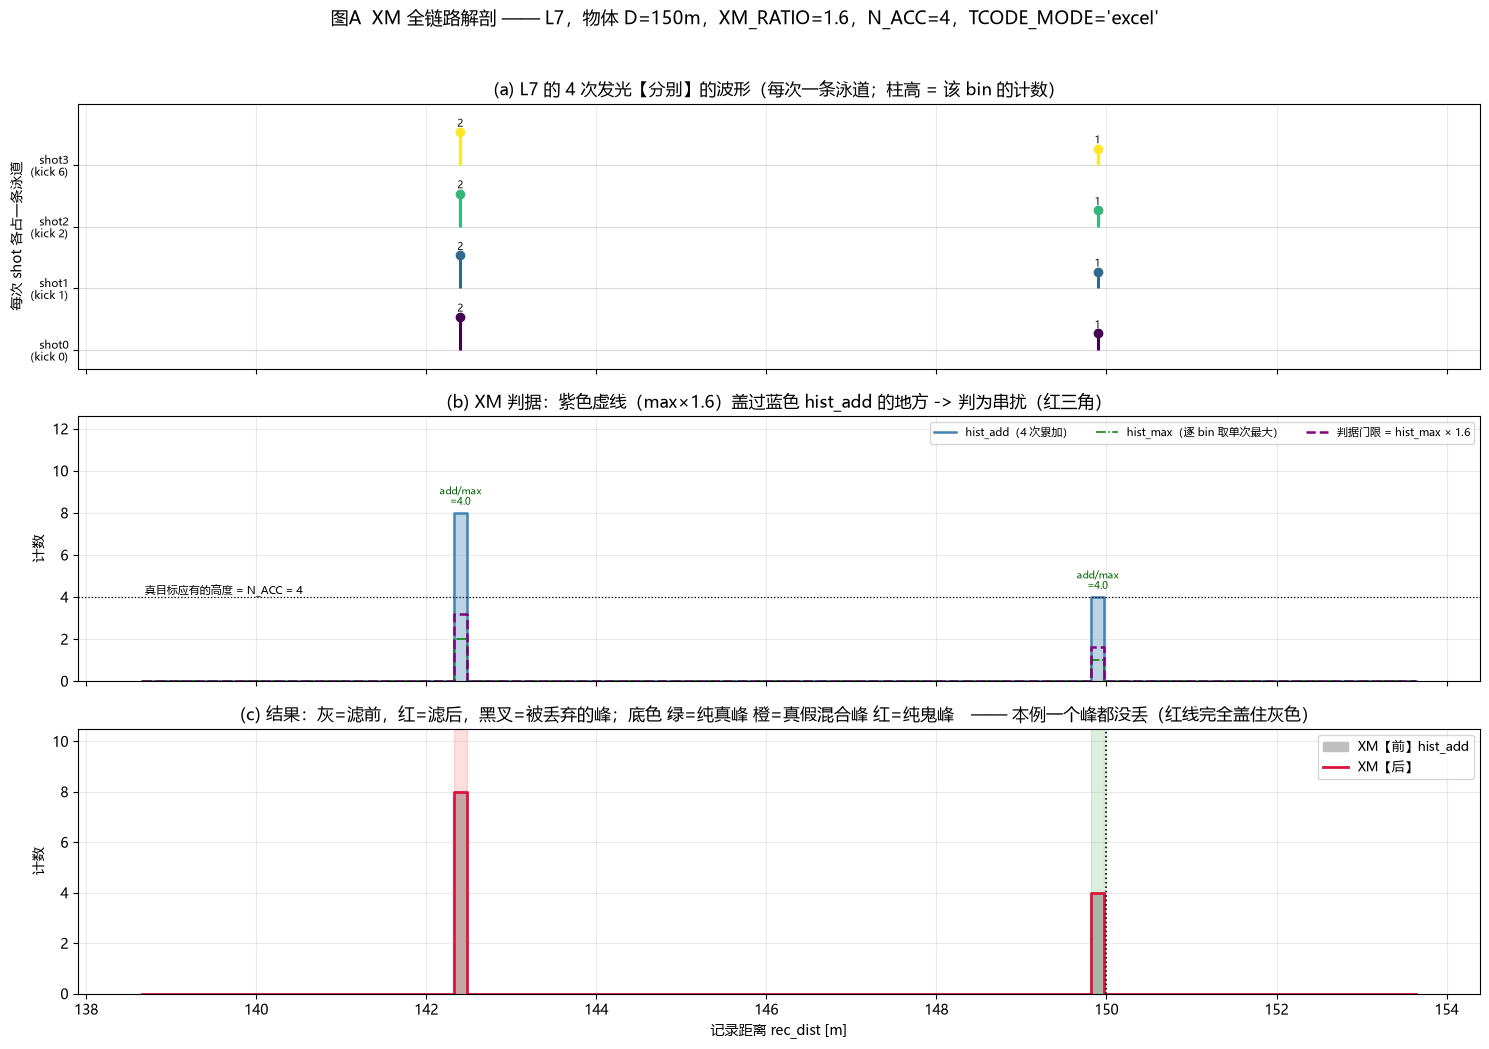

In [13]:
# ============================================================================
# XM-4  图A：单个激光器的 XM 全链路解剖（4 次 shot -> 判据 -> 滤前/滤后）
# ============================================================================
def occupied_range(hs, pad=20):
    lo, hi = N_BINS, 0
    for h in hs.values():
        nz = np.flatnonzero(h["add"] > 1e-9)
        if nz.size:
            lo, hi = min(lo, int(nz[0])), max(hi, int(nz[-1]))
    return (0, N_BINS - 1) if lo > hi else (max(0, lo - pad), min(N_BINS - 1, hi + pad))


# 选鬼影最多的激光器来看
XM_DEMO_LASER = max(laser_ids, key=lambda l: sum(
    1 for b, rs in hists[l]["src"].items() for r in rs if not r["is_true"]))
h, rr = hists[XM_DEMO_LASER], xm_res[XM_DEMO_LASER]
b_lo, b_hi = occupied_range({XM_DEMO_LASER: h}, pad=25)
x = np.arange(b_lo, b_hi + 1) * HIST_BIN_M

fig, axes = plt.subplots(3, 1, figsize=(15, 10.5), sharex=True)

# --- (a) 4 次 shot 各自的波形（全部留存）---
#   δ 回波只有 1 个 bin 宽，4 条曲线叠在一起根本看不出区别，
#   所以每条 shot 单独占一"泳道"（纵向平移 LANE），并用竖线+圆点画出每个回波。
ax = axes[0]
LANE = float(h["shots"].max()) * 1.6 + 0.5           # 泳道间距
for si, kick in enumerate(h["kicks"]):
    y0 = si * LANE
    col = plt.cm.viridis(si / max(len(h["kicks"]) - 1, 1))
    ax.axhline(y0, color="0.85", lw=0.8, zorder=0)
    row = h["shots"][si]
    for b in np.flatnonzero(row[b_lo:b_hi + 1] > 0) + b_lo:
        ax.vlines(b * HIST_BIN_M, y0, y0 + row[b], color=col, lw=2.2, zorder=3)
        ax.plot(b * HIST_BIN_M, y0 + row[b], "o", color=col, ms=6, zorder=4)
        ax.annotate(f"{row[b]:.0f}", (b * HIST_BIN_M, y0 + row[b]), fontsize=7,
                    ha="center", va="bottom", xytext=(0, 2), textcoords="offset points")
ax.set_yticks([si * LANE for si in range(len(h["kicks"]))])
ax.set_yticklabels([f"shot{si}\n(kick {k})" for si, k in enumerate(h["kicks"])], fontsize=8)
ax.set_ylim(-0.3 * LANE, len(h["kicks"]) * LANE)
ax.set_ylabel("每次 shot 各占一条泳道")
ax.set_title(f"(a) L{XM_DEMO_LASER} 的 {len(h['kicks'])} 次发光【分别】的波形"
             f"（每次一条泳道；柱高 = 该 bin 的计数）")
ax.grid(alpha=0.25, axis="x")

# --- (b) 判据：hist_max × ratio  vs  hist_add ---
ax = axes[1]
ax.fill_between(x, 0, h["add"][b_lo:b_hi + 1], step="mid", color="steelblue", alpha=0.35)
ax.plot(x, h["add"][b_lo:b_hi + 1], drawstyle="steps-mid", color="steelblue", lw=1.8,
        label=f"hist_add（{len(h['kicks'])} 次累加）")
ax.plot(x, h["max"][b_lo:b_hi + 1], drawstyle="steps-mid", color="green", lw=1.1, ls="-.",
        label="hist_max（逐 bin 取单次最大）")
ax.plot(x, rr["thresh"][b_lo:b_hi + 1], drawstyle="steps-mid", color="purple", lw=1.8, ls="--",
        label=f"判据门限 = hist_max × {XM_RATIO}")
for q in rr["peaks"]:
    if not (b_lo <= q["peak_bin"] <= b_hi):
        continue
    ax.annotate(f"add/max\n={q['ratio']:.1f}", (q["dist"], q["add"]), fontsize=7,
                ha="center", va="bottom", xytext=(0, 4), textcoords="offset points",
                color=("darkred" if q["is_xtalk"] else "darkgreen"))
    if q["is_xtalk"]:
        ax.plot(q["dist"], q["add"], "rv", ms=10)
ax.axhline(N_ACC, color="k", ls=":", lw=0.9)
ax.text(x[0], N_ACC, f" 真目标应有的高度 = N_ACC = {N_ACC}", fontsize=8, va="bottom")
ax.set_ylim(0, float(h["add"].max()) * 1.45 + 1.0)     # 给峰顶标注留出空间
ax.set_ylabel("计数")
ax.set_title(f"(b) XM 判据：紫色虚线（max×{XM_RATIO}）盖过蓝色 hist_add 的地方 -> 判为串扰（红三角）")
ax.legend(fontsize=8, ncol=3); ax.grid(alpha=0.25)

# --- (c) 滤前 / 滤后 ---
ax = axes[2]
ax.fill_between(x, 0, h["add"][b_lo:b_hi + 1], step="mid", color="0.75", label="XM【前】hist_add")
ax.plot(x, rr["after"][b_lo:b_hi + 1], drawstyle="steps-mid", color="crimson", lw=2.0,
        label="XM【后】")
for q in rr["dropped"]:
    if b_lo <= q["peak_bin"] <= b_hi:
        ax.plot(q["dist"], q["add"], "kx", ms=12, mew=2.2)
for q in rr["peaks"]:
    kind, _ = peak_truth(h, q)
    if not (b_lo <= q["peak_bin"] <= b_hi):
        continue
    col = {"纯真峰": "green", "混合峰": "orange", "纯鬼峰": "red"}[kind]
    ax.axvspan((q["s"] - 0.5) * HIST_BIN_M, (q["e"] + 0.5) * HIST_BIN_M, color=col, alpha=0.13)
ax.axvline(XM_DEMO_D, color="k", ls=":", lw=1.2)
ax.set_ylim(0, float(h["add"].max()) * 1.25 + 0.5)
ax.set_xlabel("记录距离 rec_dist [m]"); ax.set_ylabel("计数")
_nd = len(rr["dropped"])
ax.set_title(f"(c) 结果：灰=滤前，红=滤后，黑叉=被丢弃的峰；"
             f"底色 绿=纯真峰 橙=真假混合峰 红=纯鬼峰"
             + ("　—— 本例一个峰都没丢（红线完全盖住灰色）" if _nd == 0
                else f"　—— 本例丢弃了 {_nd} 个峰"))
ax.legend(fontsize=9); ax.grid(alpha=0.25)

plt.suptitle(f"图A  XM 全链路解剖 —— L{XM_DEMO_LASER}，物体 D={XM_DEMO_D:.0f}m，"
             f"XM_RATIO={XM_RATIO}，N_ACC={N_ACC}，TCODE_MODE='{TCODE_MODE}'",
             fontsize=13, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.975])
plt.show()


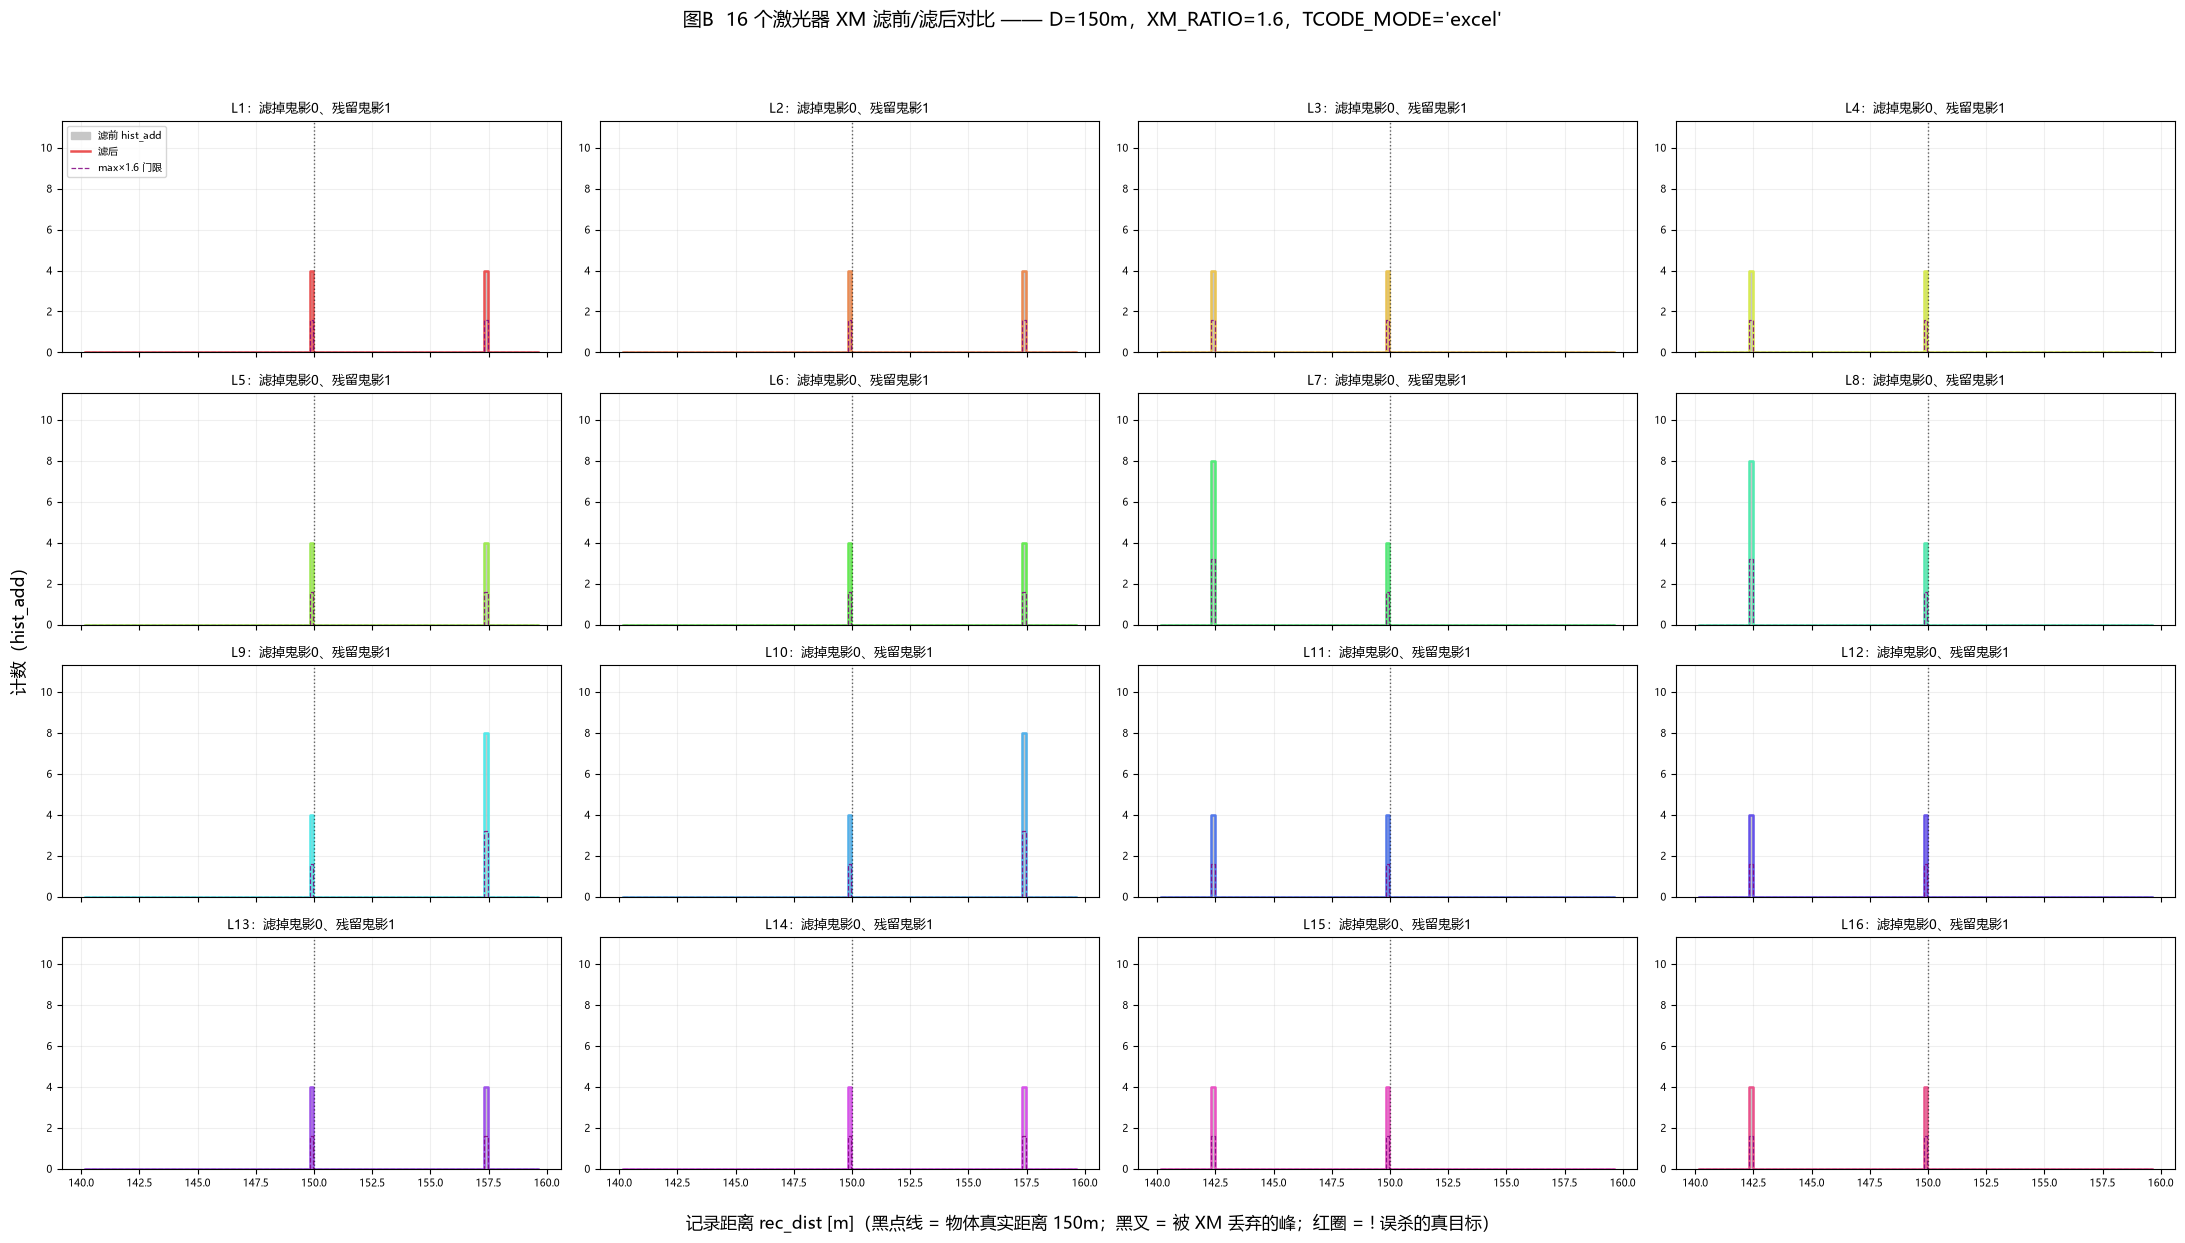

In [14]:
# ============================================================================
# XM-5  图B：全部 16 个激光器的【滤前 / 滤后】对比
# ============================================================================
b_lo, b_hi = occupied_range(hists, pad=15)
x = np.arange(b_lo, b_hi + 1) * HIST_BIN_M

nrow = int(np.ceil(N_LASERS / 4))
fig, axes = plt.subplots(nrow, 4, figsize=(22, 3.1 * nrow), sharex=True)
axes = np.atleast_2d(axes)
ymax = max(h["add"].max() for h in hists.values()) * 1.35 + 0.5

for i, lid in enumerate(laser_ids):
    ax = axes[i // 4][i % 4]
    h, rr = hists[lid], xm_res[lid]
    ax.fill_between(x, 0, h["add"][b_lo:b_hi + 1], step="mid", color="0.78", label="滤前 hist_add")
    ax.plot(x, rr["after"][b_lo:b_hi + 1], drawstyle="steps-mid",
            color=laser_color(lid), lw=1.8, label="滤后")
    ax.plot(x, rr["thresh"][b_lo:b_hi + 1], drawstyle="steps-mid", color="purple",
            lw=0.9, ls="--", alpha=0.85, label=f"max×{XM_RATIO} 门限")

    n_hit = n_miss = n_kill = 0
    for q in rr["peaks"]:
        kind, _ = peak_truth(h, q)
        if q["is_xtalk"]:
            ax.plot(q["dist"], q["add"], "kx", ms=8, mew=1.6)
            if kind == "纯鬼峰":
                n_hit += 1
            else:
                n_kill += 1
                ax.plot(q["dist"], q["add"], "o", mfc="none", mec="red", ms=14, mew=2)
        elif kind == "纯鬼峰":
            n_miss += 1

    ax.axvline(XM_DEMO_D, color="k", ls=":", lw=1.0, alpha=0.6)
    ax.set_ylim(0, ymax)
    ax.set_title(f"L{lid}：滤掉鬼影{n_hit}、残留鬼影{n_miss}" + (f"、!误杀{n_kill}" if n_kill else ""),
                 fontsize=9)
    ax.tick_params(labelsize=7); ax.grid(alpha=0.2)
    if i == 0:
        ax.legend(fontsize=7, loc="upper left")

for j in range(N_LASERS, nrow * 4):
    axes[j // 4][j % 4].axis("off")

fig.text(0.5, 0.015, f"记录距离 rec_dist [m]（黑点线 = 物体真实距离 {XM_DEMO_D:.0f}m；"
                     f"黑叉 = 被 XM 丢弃的峰；红圈 = ! 误杀的真目标）", ha="center", fontsize=12)
fig.text(0.008, 0.5, "计数（hist_add）", va="center", rotation="vertical", fontsize=12)
plt.suptitle(f"图B  16 个激光器 XM 滤前/滤后对比 —— D={XM_DEMO_D:.0f}m，"
             f"XM_RATIO={XM_RATIO}，TCODE_MODE='{TCODE_MODE}'", fontsize=14, y=0.998)
plt.tight_layout(rect=[0.015, 0.035, 1, 0.965])
plt.show()


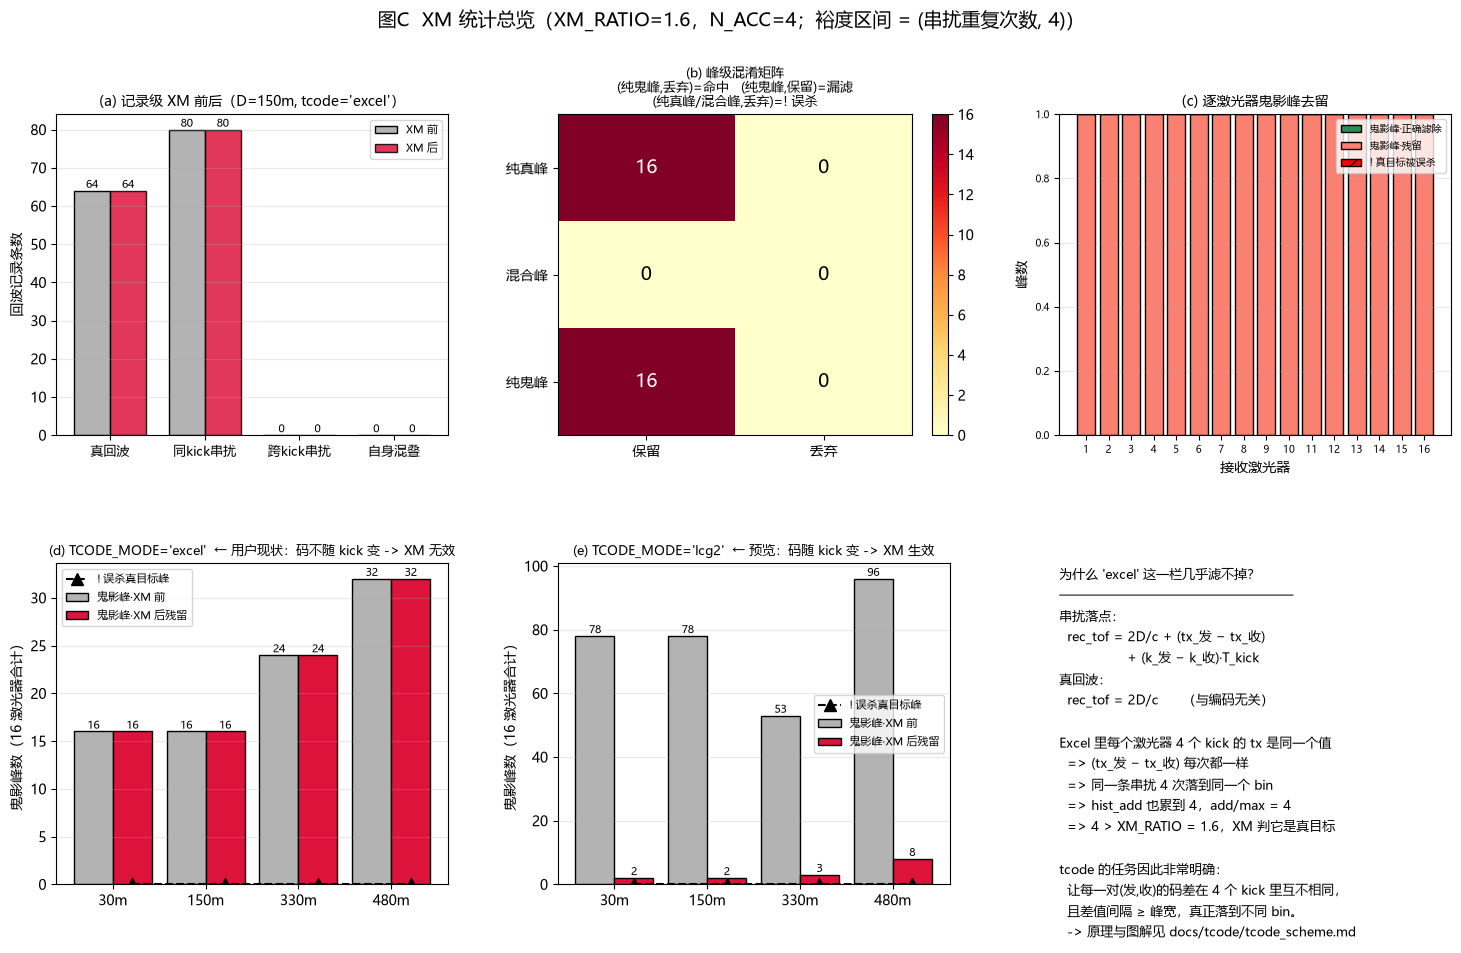


多距离 × 多 tcode 统计表
     tcode   D[m]    真峰    混峰    鬼峰 |     鬼峰丢弃     鬼峰残留     滤除率 |    误杀     误杀率
  --------------------------------------------------------------------------------------------
     excel     30    16     0    16 |        0       16   0.0% |     0   0.0%
     excel    150    16     0    16 |        0       16   0.0% |     0   0.0%
     excel    330     0     0    24 |        0       24   0.0% |     0   0.0%
     excel    480     0     0    32 |        0       32   0.0% |     0   0.0%
      lcg2     30    16     0    78 |       76        2  97.4% |     0   0.0%
      lcg2    150    16     0    78 |       76        2  97.4% |     0   0.0%
      lcg2    330     0     0    53 |       50        3  94.3% |     0   0.0%
      lcg2    480     0     0    96 |       88        8  91.7% |     0   0.0%


In [15]:
# ============================================================================
# XM-6  图C：统计可视化 + 不同 tcode / 不同距离的对比表
# ============================================================================
def run_pipeline(D, tcode_mode=None, ratio=None):
    """跑一遍完整流程（换 tcode 时临时替换全局 firings，不改 v13 代码）。"""
    if tcode_mode is None or tcode_mode == TCODE_MODE:
        recs = detect_echoes(D)
    else:
        with use_firings(build_firings_tcode(make_tcode_fn(tcode_mode))):
            recs = detect_echoes(D)
    hs = build_hists(recs)
    rs = crosstalk_mark_all(hs, ratio)
    return hs, rs, evaluate(hs, rs)


#   excel = 用户现状（默认）；lcg2 = docs/tcode 推荐的两层编码，用来预览编码生效的样子
TCODE_COMPARE = ["excel", "lcg2"]
ACTS = ["保留", "丢弃"]

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.40, wspace=0.28)

# --- (a) 记录级：XM 前后 ---
ax = fig.add_subplot(gs[0, 0])
before = [xm_stat["rec_before"][k] for k in ALL_KINDS]
after  = [xm_stat["rec_after"][k]  for k in ALL_KINDS]
xx, w = np.arange(len(ALL_KINDS)), 0.38
ax.bar(xx - w/2, before, w, color="0.7", edgecolor="k", label="XM 前")
ax.bar(xx + w/2, after,  w, color="crimson", edgecolor="k", alpha=0.85, label="XM 后")
for i, (b, a) in enumerate(zip(before, after)):
    ax.text(i - w/2, b, str(b), ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, a, str(a), ha="center", va="bottom", fontsize=8)
ax.set_xticks(xx); ax.set_xticklabels(ALL_KINDS, fontsize=9)
ax.set_ylabel("回波记录条数")
ax.set_title(f"(a) 记录级 XM 前后（D={XM_DEMO_D:.0f}m, tcode='{TCODE_MODE}'）", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.25, axis="y")

# --- (b) 峰级混淆矩阵 ---
ax = fig.add_subplot(gs[0, 1])
KINDS = ["纯真峰", "混合峰", "纯鬼峰"]
M = np.array([[xm_stat["peak"][(k, a)] for a in ACTS] for k in KINDS], dtype=float)
im = ax.imshow(M, cmap="YlOrRd", aspect="auto")
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{int(M[i,j])}", ha="center", va="center", fontsize=14,
                color=("white" if M[i, j] > M.max() * 0.6 else "black"))
ax.set_xticks([0, 1]); ax.set_xticklabels(ACTS)
ax.set_yticks(range(3)); ax.set_yticklabels(KINDS)
ax.set_title("(b) 峰级混淆矩阵\n(纯鬼峰,丢弃)=命中   (纯鬼峰,保留)=漏滤\n"
             "(纯真峰/混合峰,丢弃)=! 误杀", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.045)

# --- (c) 逐激光器 ---
ax = fig.add_subplot(gs[0, 2])
hit  = [xm_stat["per_laser"][l][("纯鬼峰", "丢弃")] for l in laser_ids]
miss = [xm_stat["per_laser"][l][("纯鬼峰", "保留")] for l in laser_ids]
kill = [sum(xm_stat["per_laser"][l][(k, "丢弃")] for k in ("纯真峰", "混合峰")) for l in laser_ids]
ax.bar(laser_ids, hit, color="seagreen", edgecolor="k", label="鬼影峰·正确滤除")
ax.bar(laser_ids, miss, bottom=hit, color="salmon", edgecolor="k", label="鬼影峰·残留")
ax.bar(laser_ids, kill, bottom=np.array(hit) + np.array(miss), color="red", edgecolor="k",
       hatch="//", label="! 真目标被误杀")
ax.set_xlabel("接收激光器"); ax.set_ylabel("峰数")
ax.set_xticks(laser_ids); ax.tick_params(labelsize=7)
ax.set_title("(c) 逐激光器鬼影峰去留", fontsize=10)
ax.legend(fontsize=7.5); ax.grid(alpha=0.25, axis="y")

# --- (d)(e) 两种 tcode × 四个距离 ---
for col, mode in enumerate(TCODE_COMPARE):
    ax = fig.add_subplot(gs[1, col])
    gb, ga, tk = [], [], []
    for D in D_TEST:                      # D_TEST 来自 v13 的验证 cell
        _, _, s = run_pipeline(D, mode)
        gb.append(sum(s["peak"][("纯鬼峰", a)] for a in ACTS))
        ga.append(s["peak"][("纯鬼峰", "保留")])
        tk.append(sum(s["peak"][(k, "丢弃")] for k in ("纯真峰", "混合峰")))
    xx = np.arange(len(D_TEST))
    ax.bar(xx - 0.21, gb, 0.42, color="0.7", edgecolor="k", label="鬼影峰·XM 前")
    ax.bar(xx + 0.21, ga, 0.42, color="crimson", edgecolor="k", label="鬼影峰·XM 后残留")
    ax.plot(xx + 0.21, tk, "k^--", ms=8, label="! 误杀真目标峰")
    for i in range(len(D_TEST)):
        ax.text(xx[i] - 0.21, gb[i], str(gb[i]), ha="center", va="bottom", fontsize=8)
        ax.text(xx[i] + 0.21, ga[i], str(ga[i]), ha="center", va="bottom", fontsize=8)
    ax.set_xticks(xx); ax.set_xticklabels([f"{d:.0f}m" for d in D_TEST])
    ax.set_ylabel("鬼影峰数（16 激光器合计）")
    ax.set_title(f"({'de'[col]}) TCODE_MODE='{mode}'"
                 + ("  ← 用户现状：码不随 kick 变 -> XM 无效"
                    if mode == "excel" else "  ← 预览：码随 kick 变 -> XM 生效"), fontsize=9.5)
    ax.legend(fontsize=8); ax.grid(alpha=0.25, axis="y")

# --- (f) 文字说明 ---
ax = fig.add_subplot(gs[1, 2]); ax.axis("off")
ax.text(0.0, 1.0,
        "为什么 'excel' 这一栏几乎滤不掉？\n"
        "──────────────────────────\n"
        "串扰落点：\n"
        "  rec_tof = 2D/c + (tx_发 − tx_收)\n"
        "                 + (k_发 − k_收)·T_kick\n"
        "真回波：\n"
        "  rec_tof = 2D/c      （与编码无关）\n\n"
        "Excel 里每个激光器 4 个 kick 的 tx 是同一个值\n"
        "  => (tx_发 − tx_收) 每次都一样\n"
        "  => 同一条串扰 4 次落到同一个 bin\n"
        f"  => hist_add 也累到 {N_ACC}，add/max = {N_ACC}\n"
        f"  => {N_ACC} > XM_RATIO = {XM_RATIO}，XM 判它是真目标\n\n"
        "tcode 的任务因此非常明确：\n"
        f"  让每一对(发,收)的码差在 {N_ACC} 个 kick 里互不相同，\n"
        "  且差值间隔 ≥ 峰宽，真正落到不同 bin。\n"
        "  -> 原理与图解见 docs/tcode/tcode_scheme.md",
        fontsize=9.5, va="top", linespacing=1.5)

plt.suptitle(f"图C  XM 统计总览（XM_RATIO={XM_RATIO}，N_ACC={N_ACC}；"
             f"裕度区间 = (串扰重复次数, {N_ACC})）", fontsize=14, y=0.985)
plt.show()

# ---- 文字统计表 ----
print("\n" + "=" * 96)
print("多距离 × 多 tcode 统计表")
print("=" * 96)
print(f"  {'tcode':>8} {'D[m]':>6} {'真峰':>5} {'混峰':>5} {'鬼峰':>5} | "
      f"{'鬼峰丢弃':>8} {'鬼峰残留':>8} {'滤除率':>7} | {'误杀':>5} {'误杀率':>7}")
print("  " + "-" * 92)
for mode in TCODE_COMPARE:
    for D in D_TEST:
        _, _, s = run_pipeline(D, mode)
        P = s["peak"]
        n_pure = sum(P[("纯真峰", a)] for a in ACTS)
        n_mix  = sum(P[("混合峰", a)] for a in ACTS)
        n_gh   = sum(P[("纯鬼峰", a)] for a in ACTS)
        hit, miss = P[("纯鬼峰", "丢弃")], P[("纯鬼峰", "保留")]
        kill = sum(P[(k, "丢弃")] for k in ("纯真峰", "混合峰"))
        print(f"  {mode:>8} {D:>6.0f} {n_pure:>5d} {n_mix:>5d} {n_gh:>5d} | "
              f"{hit:>8d} {miss:>8d} {hit/max(n_gh,1):>6.1%} | "
              f"{kill:>5d} {kill/max(n_pure+n_mix,1):>6.1%}")


距离扫描中（120 个距离 × 2 种 tcode，稍等）...
    [excel] 1/120  D=5m ...
    [excel] 31/120  D=155m ...
    [excel] 61/120  D=305m ...
    [excel] 91/120  D=455m ...
    [lcg2] 1/120  D=5m ...
    [lcg2] 31/120  D=155m ...
    [lcg2] 61/120  D=305m ...
    [lcg2] 91/120  D=455m ...
扫描完成。


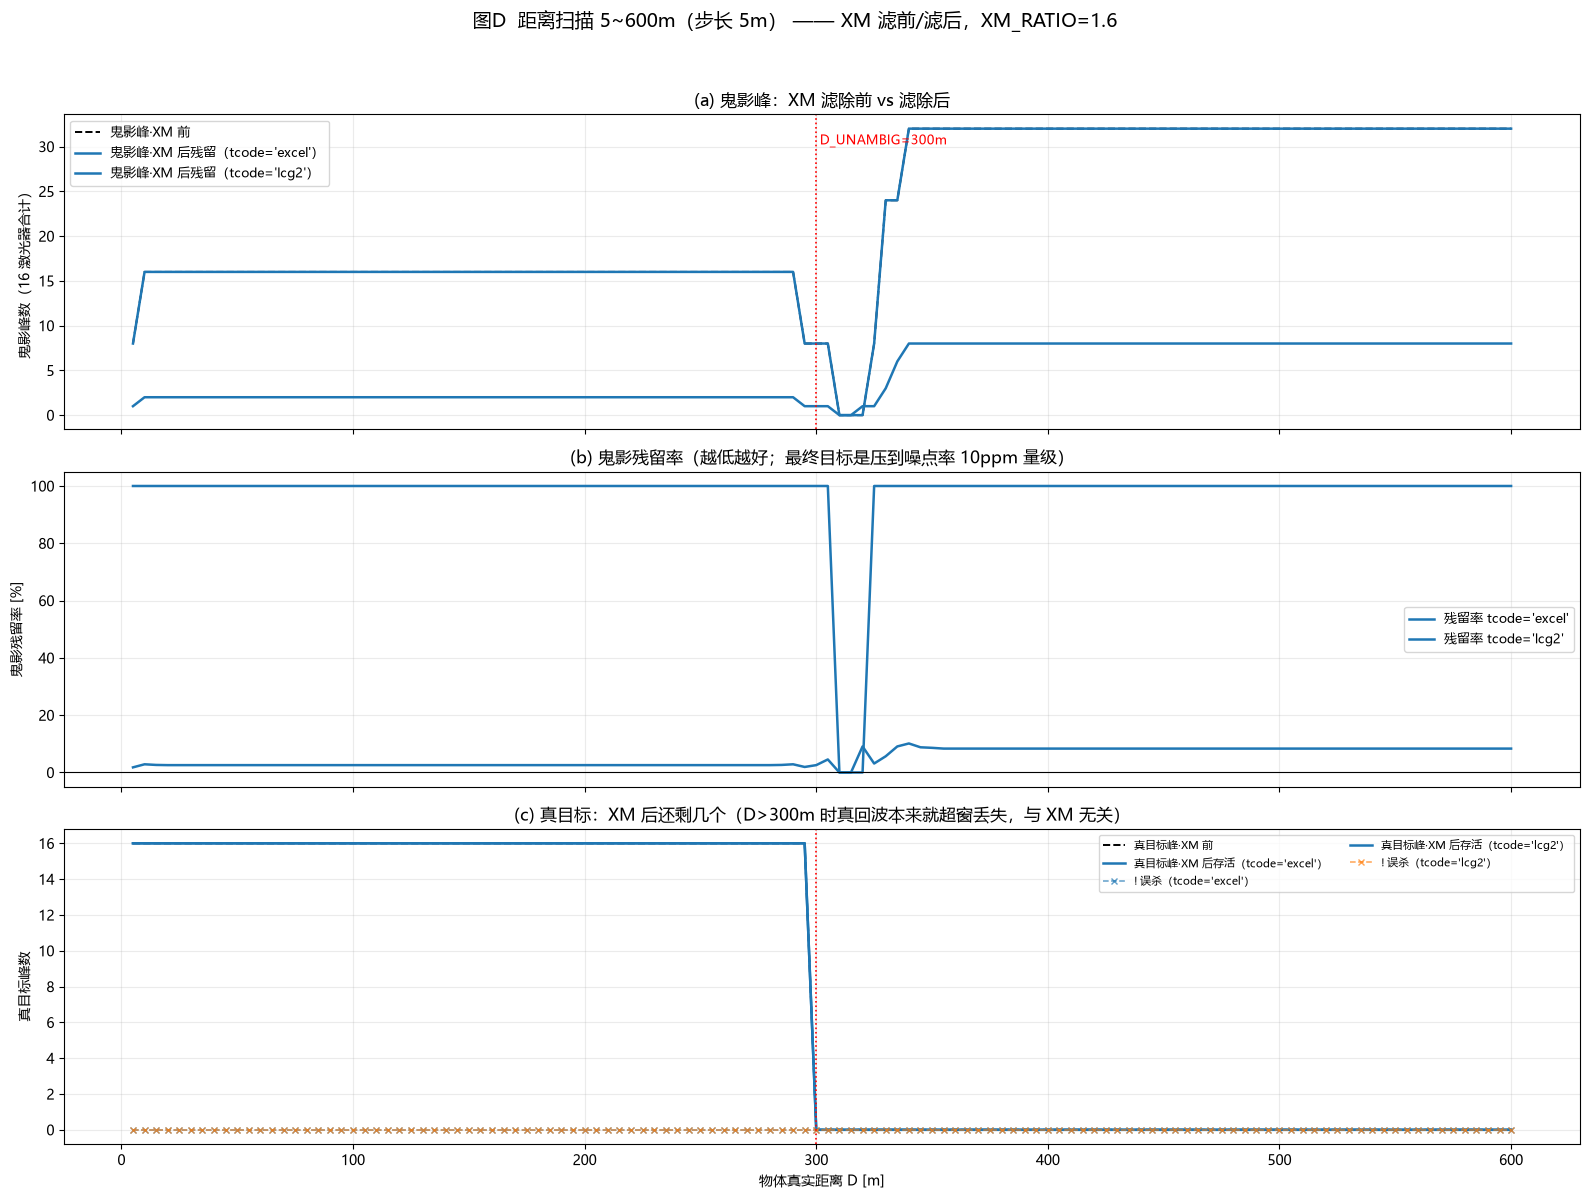


距离扫描汇总（120 个距离点 × 16 个激光器）
     tcode      鬼影峰(前)      鬼影峰(后)      滤除率     真峰(前)     误杀      误杀率
  ------------------------------------------------------------------------------------
     excel        2696        2696   0.00%       944      0   0.00%
      lcg2        9834         553  94.38%       944      0   0.00%


In [16]:
# ============================================================================
# XM-7  图D：距离扫描 —— 物体从近到远走一遍，看 XM 前后鬼影残留 & 真目标存活
#   这是最终目标（噪点率 10ppm）的雏形指标。
# ============================================================================
SWEEP_LO, SWEEP_HI, SWEEP_STEP = 5.0, 600.0, 5.0     # 600m = 2 × D_UNAMBIG
D_SWEEP = np.arange(SWEEP_LO, SWEEP_HI + 1e-9, SWEEP_STEP)


def sweep(tcode_mode, progress_every=30):
    out = {k: [] for k in ("ghost_before", "ghost_after", "true_before", "true_killed")}
    for i, D in enumerate(D_SWEEP):
        _, _, s = run_pipeline(D, tcode_mode)
        P = s["peak"]
        out["ghost_before"].append(sum(P[("纯鬼峰", a)] for a in ACTS))
        out["ghost_after"].append(P[("纯鬼峰", "保留")])
        out["true_before"].append(sum(P[(k, a)] for k in ("纯真峰", "混合峰") for a in ACTS))
        out["true_killed"].append(sum(P[(k, "丢弃")] for k in ("纯真峰", "混合峰")))
        if progress_every and i % progress_every == 0:
            print(f"    [{tcode_mode}] {i+1}/{len(D_SWEEP)}  D={D:.0f}m ...")
    return {k: np.asarray(v) for k, v in out.items()}


print(f"距离扫描中（{len(D_SWEEP)} 个距离 × {len(TCODE_COMPARE)} 种 tcode，稍等）...")
SW = {m: sweep(m) for m in TCODE_COMPARE}
print("扫描完成。")

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
COLS = {"excel": "tab:blue", "random": "tab:orange", "none": "tab:green"}

ax = axes[0]
ax.plot(D_SWEEP, SW[TCODE_COMPARE[0]]["ghost_before"], "k--", lw=1.4,
        label="鬼影峰·XM 前")
for m in TCODE_COMPARE:
    ax.plot(D_SWEEP, SW[m]["ghost_after"], "-", color=COLS.get(m), lw=1.8,
            label=f"鬼影峰·XM 后残留（tcode='{m}'）")
ax.axvline(D_UNAMBIG, color="r", ls=":", lw=1.2)
ax.text(D_UNAMBIG, ax.get_ylim()[1]*0.9, f" D_UNAMBIG={D_UNAMBIG:.0f}m", color="r", fontsize=9)
ax.set_ylabel("鬼影峰数（16 激光器合计）")
ax.set_title("(a) 鬼影峰：XM 滤除前 vs 滤除后")
ax.legend(fontsize=9); ax.grid(alpha=0.25)

ax = axes[1]
for m in TCODE_COMPARE:
    resid = SW[m]["ghost_after"] / np.maximum(SW[m]["ghost_before"], 1)
    ax.plot(D_SWEEP, resid * 100, "-", color=COLS.get(m), lw=1.8, label=f"残留率 tcode='{m}'")
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("鬼影残留率 [%]")
ax.set_title("(b) 鬼影残留率（越低越好；最终目标是压到噪点率 10ppm 量级）")
ax.legend(fontsize=9); ax.grid(alpha=0.25)

ax = axes[2]
ax.plot(D_SWEEP, SW[TCODE_COMPARE[0]]["true_before"], "k--", lw=1.4, label="真目标峰·XM 前")
for m in TCODE_COMPARE:
    ax.plot(D_SWEEP, SW[m]["true_before"] - SW[m]["true_killed"], "-", color=COLS.get(m),
            lw=1.8, label=f"真目标峰·XM 后存活（tcode='{m}'）")
    ax.plot(D_SWEEP, SW[m]["true_killed"], "--", color=COLS.get(m), lw=1.1, alpha=0.7,
            marker="x", ms=4, label=f"! 误杀（tcode='{m}'）")
ax.axvline(D_UNAMBIG, color="r", ls=":", lw=1.2)
ax.set_xlabel("物体真实距离 D [m]"); ax.set_ylabel("真目标峰数")
ax.set_title("(c) 真目标：XM 后还剩几个（D>300m 时真回波本来就超窗丢失，与 XM 无关）")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.25)

plt.suptitle(f"图D  距离扫描 {SWEEP_LO:.0f}~{SWEEP_HI:.0f}m（步长 {SWEEP_STEP:.0f}m）"
             f" —— XM 滤前/滤后，XM_RATIO={XM_RATIO}", fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print("\n" + "=" * 88)
print(f"距离扫描汇总（{len(D_SWEEP)} 个距离点 × 16 个激光器）")
print("=" * 88)
print(f"  {'tcode':>8} {'鬼影峰(前)':>11} {'鬼影峰(后)':>11} {'滤除率':>8} "
      f"{'真峰(前)':>9} {'误杀':>6} {'误杀率':>8}")
print("  " + "-" * 84)
for m in TCODE_COMPARE:
    gb, ga = SW[m]["ghost_before"].sum(), SW[m]["ghost_after"].sum()
    tb, tk = SW[m]["true_before"].sum(), SW[m]["true_killed"].sum()
    print(f"  {m:>8} {gb:>11d} {ga:>11d} {(gb-ga)/max(gb,1):>7.2%} "
          f"{tb:>9d} {tk:>6d} {tk/max(tb,1):>7.2%}")


In [17]:
# ============================================================================
# XM-8  总结
# ============================================================================
print("=" * 88)
print("crosstalk_sim_v20 总结")
print("=" * 88)
print(f"""
0. 本 notebook 的结构
   - cell 1~10 = v13 原封不动（kick 栅格、记录距离分布、逐回波堆叠柱，一个没删）
   - 之后 = v20 新增的 XM 部分

1. 实装的 XM（只有用户要求的那一条判据）
   - 每个激光器 {N_ACC} 次 shot 全部留存 → hist_add（累加）、hist_max（逐 bin 取最大）
   - 判据：hist_max × {XM_RATIO} > hist_add  →  该峰是串扰，丢弃
   - 等价：add/max < {XM_RATIO}；而 add/max = 该峰在几次 shot 里出现过
   - 硬件文档里的分档 / flag0~3 / diff_flag / FIR / max 抽取，本版一律未实装

2. 阈值裕度
   - 必须满足： 串扰最大重复次数 < XM_RATIO({XM_RATIO}) < N_ACC({N_ACC})
   - 现在的 {XM_RATIO} 只能滤掉"{N_ACC} 次里只出现 1 次"的串扰
   - 想连"出现 2 次"的也滤掉 → XM_RATIO 抬到 2.5；但真目标保护裕度从 2.5× 降到 1.6×

3. 本版结论
   - TCODE_MODE='excel'（用户现状）：码不随 kick 变 → 串扰每次落同一 bin
     → add/max = {N_ACC} → XM 滤除率 ≈ 0（图C(d)、图D 已证实）
   - TCODE_MODE='lcg2'（预览，docs/tcode 推荐的两层编码）：码随 kick 变
     → 串扰被打散 → XM 立刻生效（图C(e)、图D）
   - 说明 XM 实现无误，**瓶颈在编码不在算法**

4. 下一版 v21：tcode（各激光器之间的 tx_trig_dly 编码）
   - 目标：对任意一对激光器 (a,b)，码差 c[a][k] − c[b][k] 在 {N_ACC} 个 kick 上互不相同，
     且两两间隔 ≥ 峰宽 → 同一条串扰散到 {N_ACC} 个不同 bin → add/max = 1 → 被 XM 全滤
   - 推荐构造（docs/tcode 已验证）：
       c[l][k] = ((l*(k+1)) mod 17)*8ns  +  ((k*k) mod 9)*8ns
       第一项治同 kick 串扰；第二项对所有激光器相同，治自身混叠
   - 已验证成绩（1~600m 扫描，误杀 0）：
       鬼影残留率  XM_RATIO=1.6 → 5.6%    XM_RATIO=2.5 → 0.53%
   - 构造推导、约束、图解、验收指标：见 docs/tcode/tcode_scheme.md

5. 以后可选的加强项（本版只提不做）
   - 次大值方案 add − max − max2：裕度从 (1,N) 扩到 (2,N)，能吃掉重复 2 次的串扰
   - 软减法 out = max(add − α·max, 0)：真目标峰上叠了串扰时不会连真目标一起丢
   - n_hit 逐 bin 命中计数：N=4 只要 2bit/bin，比 hist_max 更省，但丢幅度信息
""")


crosstalk_sim_v20 总结

0. 本 notebook 的结构
   - cell 1~10 = v13 原封不动（kick 栅格、记录距离分布、逐回波堆叠柱，一个没删）
   - 之后 = v20 新增的 XM 部分

1. 实装的 XM（只有用户要求的那一条判据）
   - 每个激光器 4 次 shot 全部留存 → hist_add（累加）、hist_max（逐 bin 取最大）
   - 判据：hist_max × 1.6 > hist_add  →  该峰是串扰，丢弃
   - 等价：add/max < 1.6；而 add/max = 该峰在几次 shot 里出现过
   - 硬件文档里的分档 / flag0~3 / diff_flag / FIR / max 抽取，本版一律未实装

2. 阈值裕度
   - 必须满足： 串扰最大重复次数 < XM_RATIO(1.6) < N_ACC(4)
   - 现在的 1.6 只能滤掉"4 次里只出现 1 次"的串扰
   - 想连"出现 2 次"的也滤掉 → XM_RATIO 抬到 2.5；但真目标保护裕度从 2.5× 降到 1.6×

3. 本版结论
   - TCODE_MODE='excel'（用户现状）：码不随 kick 变 → 串扰每次落同一 bin
     → add/max = 4 → XM 滤除率 ≈ 0（图C(d)、图D 已证实）
   - TCODE_MODE='lcg2'（预览，docs/tcode 推荐的两层编码）：码随 kick 变
     → 串扰被打散 → XM 立刻生效（图C(e)、图D）
   - 说明 XM 实现无误，**瓶颈在编码不在算法**

4. 下一版 v21：tcode（各激光器之间的 tx_trig_dly 编码）
   - 目标：对任意一对激光器 (a,b)，码差 c[a][k] − c[b][k] 在 4 个 kick 上互不相同，
     且两两间隔 ≥ 峰宽 → 同一条串扰散到 4 个不同 bin → add/max = 1 → 被 XM 全滤
   - 推荐构造（docs/tcode 已验证）：
       c[l][k] = ((l*(k+1)) mod 17)*8ns  +  ((k*k) mod 9)*8ns
       第

---

# v21 新增部分

---

# tcode：把串扰"搬"到 XM 能看见的地方

## 1. 编码只搬鬼影，不搬真目标

一次发光既是发射、也开一个 2000 ns 接收窗。接收方拿**自己**的发光时刻当测距零点：

$$\text{rec\_tof}
= \underbrace{\frac{2D}{c}}_{\text{物体距离}}
+ \underbrace{\big(tx_{\text{发}} - tx_{\text{收}}\big)}_{\textbf{码差}}
- \underbrace{\big(k_{\text{收}} - k_{\text{发}}\big)\cdot T_{\rm kick}}_{\text{跨 kick 混叠}}$$

真回波（发 = 收、同 kick）后两项都是 0，**与编码无关**。
所以编码怎么改都不会动真目标 —— 这就是「只杀鬼影不伤真身」的机理，也是本版误杀恒为 0 的原因。

## 2. 编码要满足什么

XM 判据是 `hist_max × xm_ratio > hist_add`，等价于 `add/max < xm_ratio`，
而 `add/max` = **这个峰在几次 shot 里出现过**。真目标恒为 4（`N_ACC`），
所以只要让每条串扰在 4 次 shot 里落到 **4 个不同的 bin**，它的 `add/max` 就是 1，必被丢弃。

> **约束**：对每一类鬼影源（发射器 `a`、kick 偏移 `Δk`），
> 接收器 `b` 的 4 次 shot 收到的该类鬼影，落点由 `c[a][k−Δk] − c[b][k]` 决定，
> 要求这 4 个值**两两相差 ≥ 12 ns**（≥ 峰宽，否则会糊成一个峰）。

三类鬼影源都要管：

| Δk | a vs b | 叫什么 | 备注 |
|---|---|---|---|
| 0 | a ≠ b | 同 kick 串扰 | 最常见，解析构造能治 |
| 1 | a ≠ b | 跨 kick 混叠 | D > 300m 时别人上一个 kick 的光折回来 |
| 1 | a = b | **自身混叠** | 我自己上一个 kick 的光，解析构造治不了（见 tcode_scheme.md 第 10 节） |

（D ≤ 600 m 时只有 Δk ∈ {0, 1} 会落进窗内，所以约束就这两档。）

## 3. 两条硬预算

| 约束 | 数值 | 后果 |
|---|---|---|
| 落点最小间隔 ≥ 峰宽 | 12 ns | 小了就糊成一个峰，编了等于没编 |
| `max(tx) ≤ KICK_SPACING − TOF_WINDOW` | 200 ns | 超了窗会伸进下一个 kick |

本版实际用到 **63 ns**，占 kick 间隙的 32%，
剩下的留给后面 FPGA 的 8 ns 步长随机抖动（见最后一节）。


In [18]:
# ============================================================================
# TC-1  v21 码表：tx_trig_dly [ns]
# ============================================================================
#   来源：docs/tcode/solve_tcode.py 的数值搜索（seed 固定，可复现）
#   参数：峰宽裕度 12 ns（单光子脉宽 8ns + 裕度）、码预算 64 ns
#   注意：本表绑定当前时序表（哪个激光器在哪 4 个 kick 发光）。时序一改必须重搜。
# ============================================================================
TCODE_SEP_NS    = 12      # 两个落点至少要差这么多 ns 才算"分得开"
TCODE_BUDGET_NS = 64      # 用户给定的编码时间预算

# (laser_id, kick) -> tx_trig_dly [ns]
TCODE_V21 = {
    (1,7):  3, (1,8): 46, (1,9): 53, (1,15): 47,
    (2,11): 44, (2,12): 25, (2,13): 33, (2,14): 59,
    (3,7): 37, (3,8): 57, (3,9): 21, (3,15): 37,
    (4,11): 48, (4,12): 12, (4,13): 50, (4,14): 34,
    (5,0): 32, (5,1): 34, (5,2): 19, (5,6):  5,
    (6,3): 34, (6,4): 63, (6,5):  2, (6,10): 37,
    (7,0): 63, (7,1):  0, (7,2): 35, (7,6): 50,
    (8,3):  0, (8,4): 63, (8,5): 34, (8,10): 51,
    (9,0): 62, (9,1): 45, (9,2): 15, (9,6):  8,
    (10,3): 23, (10,4): 43, (10,5): 37, (10,10): 12,
    (11,0): 42, (11,1): 37, (11,2): 59, (11,6): 39,
    (12,3): 56, (12,4): 62, (12,5):  5, (12,10):  4,
    (13,7): 32, (13,8): 32, (13,9): 60, (13,15): 48,
    (14,11): 20, (14,12): 43, (14,13):  7, (14,14): 49,
    (15,7): 60, (15,8):  4, (15,9): 46, (15,15): 47,
    (16,11): 17, (16,12): 61, (16,13): 59, (16,14):  9,
}

# ---- 开关：True = 用 v21 新码；False = 退回 Excel 原码做对照 ----
USE_V21_TCODE = True


def tcode_v21(lid, k, tx0):
    """v21 编码函数，签名与 v20 的 make_tcode_fn() 产物一致。"""
    return TCODE_V21.get((lid, k), tx0)


# ---- 码预算核查 ----
_hard_limit = (KICK_SPACING - TOF_WINDOW) / NS      # = 200 ns
_maxtx = max(TCODE_V21.values())
print("=" * 78)
print("v21 码预算核查")
print("=" * 78)
print(f"  实际最大码值      max(tx) = {_maxtx:>4.0f} ns")
print(f"  用户给定预算              = {TCODE_BUDGET_NS:>4d} ns   "
      f"-> {'OK' if _maxtx <= TCODE_BUDGET_NS else '!! 超出'}")
print(f"  硬上限 KICK−TOF           = {_hard_limit:>4.0f} ns   "
      f"-> {'OK' if _maxtx <= _hard_limit else '!! 窗会伸进下一个 kick'}")
print(f"  占 kick 间隙比例          = {_maxtx/_hard_limit:>4.0%}   "
      f"（剩 {_hard_limit-_maxtx:.0f} ns 留给 FPGA 抖动）")

# ---- 用 v20 已有的 build_firings_tcode() 构建发光事件表（不改 v20 任何代码）----
firings_v21   = build_firings_tcode(tcode_v21)
firings_excel = build_firings_tcode(make_tcode_fn("excel"))
FR_MAIN = firings_v21 if USE_V21_TCODE else firings_excel

print(f"\n  码表：{len(TCODE_V21)} 个 (激光器, kick) 组合")
print(f"  {'激光器':>6}  各 kick 的 tx_trig_dly [ns]")
print("  " + "-" * 60)
for _l in laser_ids:
    _cells = "  ".join(f"K{k}={TCODE_V21[(_l,k)]:>2d}" for k in SHOT_KICKS[_l])
    print(f"  {('L'+str(_l)):>6}  {_cells}")


v21 码预算核查
  实际最大码值      max(tx) =   63 ns
  用户给定预算              =   64 ns   -> OK
  硬上限 KICK−TOF           =  200 ns   -> OK
  占 kick 间隙比例          =  31%   （剩 137 ns 留给 FPGA 抖动）

  码表：64 个 (激光器, kick) 组合
     激光器  各 kick 的 tx_trig_dly [ns]
  ------------------------------------------------------------
      L1  K7= 3  K8=46  K9=53  K15=47
      L2  K11=44  K12=25  K13=33  K14=59
      L3  K7=37  K8=57  K9=21  K15=37
      L4  K11=48  K12=12  K13=50  K14=34
      L5  K0=32  K1=34  K2=19  K6= 5
      L6  K3=34  K4=63  K5= 2  K10=37
      L7  K0=63  K1= 0  K2=35  K6=50
      L8  K3= 0  K4=63  K5=34  K10=51
      L9  K0=62  K1=45  K2=15  K6= 8
     L10  K3=23  K4=43  K5=37  K10=12
     L11  K0=42  K1=37  K2=59  K6=39
     L12  K3=56  K4=62  K5= 5  K10= 4
     L13  K7=32  K8=32  K9=60  K15=48
     L14  K11=20  K12=43  K13= 7  K14=49
     L15  K7=60  K8= 4  K9=46  K15=47
     L16  K11=17  K12=61  K13=59  K14= 9


In [19]:
# ============================================================================
# TC-2  编码自检 —— 不跑仿真，直接验证约束
# ============================================================================
#   对每一类鬼影源，把接收器 4 次 shot 的落点算出来，看两两间隔够不够。
#   这是【充分条件】：全过 ⟹ 每条串扰的 add/max 必为 1 ⟹ XM 必能滤掉。
# ============================================================================
def ghost_classes(gap=CROSSTALK_MAX_GAP, dks=(0, 1)):
    """列出所有鬼影源类别。
       返回 [(发射器 a, 接收器 b, Δk, 类别名, [(k_发, k_收), ...]), ...]"""
    out = []
    for b in laser_ids:
        for a in laser_ids:
            if abs(a - b) > gap:
                continue                      # 编号间隔 > 阈值，空间上可忽略
            for dk in dks:
                if a == b and dk == 0:
                    continue                  # 这是真回波，不是鬼影
                prs = [(kb - dk, kb) for kb in SHOT_KICKS[b]
                       if (kb - dk) in SHOT_KICKS[a]]
                if len(prs) >= 2:
                    kind = ("自身混叠" if a == b else
                            ("同kick串扰" if dk == 0 else "跨kick串扰"))
                    out.append((a, b, dk, kind, prs))
    return out


def check_tcode(code_fn, sep=None, verbose_fail=6):
    """验证一套编码是否满足"落点两两相差 ≥ sep"。返回 (是否全过, 明细)。"""
    sep = TCODE_SEP_NS if sep is None else sep
    rows, fails = [], []
    for (a, b, dk, kind, prs) in ghost_classes():
        d = sorted(code_fn(a, ka, 0) - code_fn(b, kb, 0) for (ka, kb) in prs)
        gaps = [d[i + 1] - d[i] for i in range(len(d) - 1)]
        mind = min(gaps) if gaps else 10 ** 9
        rows.append({"a": a, "b": b, "dk": dk, "kind": kind, "n": len(d),
                     "diffs": d, "min_gap": mind, "ok": mind >= sep})
        if mind < sep:
            fails.append(rows[-1])
    return (len(fails) == 0), rows, fails


def report_check(name, code_fn):
    ok, rows, fails = check_tcode(code_fn)
    from collections import Counter
    per_kind = Counter()
    per_kind_ok = Counter()
    for r in rows:
        per_kind[r["kind"]] += 1
        per_kind_ok[r["kind"]] += int(r["ok"])
    print(f"\n【{name}】共 {len(rows)} 个鬼影源类别，要求落点两两相差 ≥ {TCODE_SEP_NS} ns")
    print(f"  {'类别':>10} {'通过/总数':>10} {'最小间隔':>9}")
    print("  " + "-" * 34)
    for k in ("同kick串扰", "跨kick串扰", "自身混叠"):
        if per_kind[k]:
            mg = min(r["min_gap"] for r in rows if r["kind"] == k)
            print(f"  {k:>10} {per_kind_ok[k]:>5d}/{per_kind[k]:<4d} {mg:>8d} ns")
    allmin = min(r["min_gap"] for r in rows)
    print(f"  {'合计':>10} {sum(per_kind_ok.values()):>5d}/{len(rows):<4d} {allmin:>8d} ns")
    print(f"  -> {'全部通过 √' if ok else f'!! {len(fails)} 个类别不达标'}")
    for r in fails[:6]:
        print(f"     L{r['a']}->L{r['b']} Δk={r['dk']} {r['kind']}: "
              f"落点 {r['diffs']} ns，最小间隔 {r['min_gap']} ns")
    return ok


print("=" * 78)
print("TC-2  编码自检")
print("=" * 78)
_ok_excel = report_check("Excel 现状（对照）", make_tcode_fn("excel"))
_ok_v21   = report_check("v21 搜索解", tcode_v21)

print("\n" + "=" * 78)
print("解读：Excel 那一栏「最小间隔 = 0」意味着 4 次 shot 的鬼影落在【同一个 bin】，")
print("      hist_add 累到 4，与真目标无法区分 —— 这正是 v20 里 XM 滤除率为 0 的原因。")
print(f"      v21 把最小间隔抬到 ≥ {TCODE_SEP_NS} ns，每条串扰的 add/max 都变成 1。")
print("=" * 78)


TC-2  编码自检

【Excel 现状（对照）】共 56 个鬼影源类别，要求落点两两相差 ≥ 12 ns
          类别      通过/总数      最小间隔
  ----------------------------------
     同kick串扰     0/20          0 ns
     跨kick串扰     0/20          0 ns
        自身混叠     0/16          0 ns
          合计     0/56          0 ns
  -> !! 56 个类别不达标
     L1->L1 Δk=1 自身混叠: 落点 [0, 0] ns，最小间隔 0 ns
     L3->L1 Δk=0 同kick串扰: 落点 [0, 0, 0, 0] ns，最小间隔 0 ns
     L3->L1 Δk=1 跨kick串扰: 落点 [0, 0] ns，最小间隔 0 ns
     L2->L2 Δk=1 自身混叠: 落点 [0, 0, 0] ns，最小间隔 0 ns
     L4->L2 Δk=0 同kick串扰: 落点 [0, 0, 0, 0] ns，最小间隔 0 ns
     L4->L2 Δk=1 跨kick串扰: 落点 [0, 0, 0] ns，最小间隔 0 ns

【v21 搜索解】共 56 个鬼影源类别，要求落点两两相差 ≥ 12 ns
          类别      通过/总数      最小间隔
  ----------------------------------
     同kick串扰    20/20         12 ns
     跨kick串扰    20/20         12 ns
        自身混叠    16/16         13 ns
          合计    56/56         12 ns
  -> 全部通过 √

解读：Excel 那一栏「最小间隔 = 0」意味着 4 次 shot 的鬼影落在【同一个 bin】，
      hist_add 累到 4，与真目标无法区分 —— 这正是 v20 里 XM 滤除率为 0 的原因。
      v21 把最小间隔抬到 ≥ 12 ns，每条串扰的

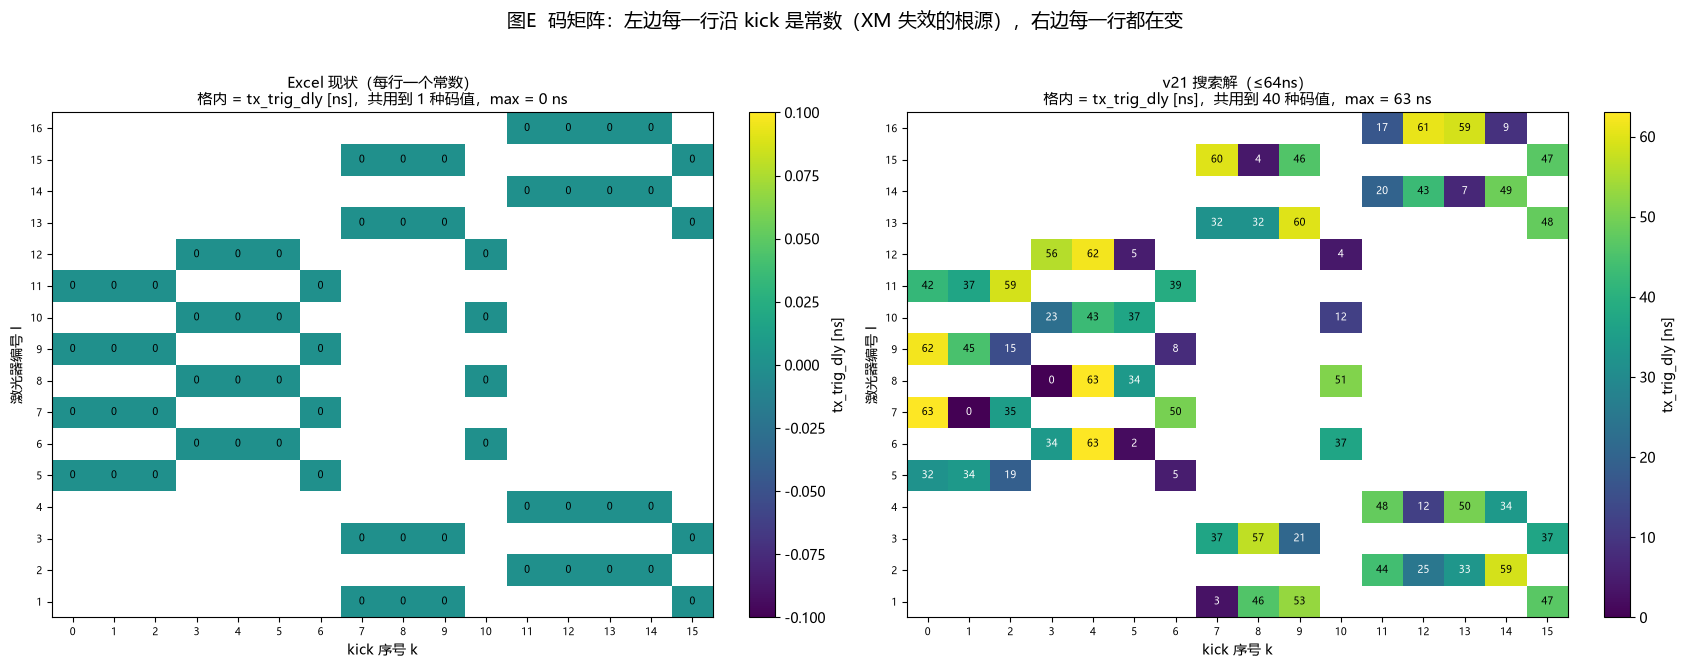

In [20]:
# ============================================================================
# TC-3  图E：码矩阵 c[l][k] 对比
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, (name, fn) in zip(axes, [("Excel 现状（每行一个常数）", make_tcode_fn("excel")),
                                 (f"v21 搜索解（≤{TCODE_BUDGET_NS}ns）", tcode_v21)]):
    M = np.full((N_LASERS, 16), np.nan)
    for i, l in enumerate(laser_ids):
        for k in SHOT_KICKS[l]:
            M[i, k] = fn(l, k, 0)
    im = ax.imshow(M, cmap="viridis", aspect="auto", origin="lower",
                   extent=[-0.5, 15.5, laser_ids[0] - 0.5, laser_ids[-1] + 0.5])
    for i, l in enumerate(laser_ids):
        for k in SHOT_KICKS[l]:
            ax.text(k, l, f"{int(M[i,k])}", ha="center", va="center", fontsize=7,
                    color=("white" if M[i, k] < np.nanmax(M) * 0.55 else "black"))
    ax.set_xticks(range(16)); ax.set_yticks(laser_ids)
    ax.tick_params(labelsize=7)
    ax.set_xlabel("kick 序号 k"); ax.set_ylabel("激光器编号 l")
    n_val = len({int(v) for v in M[~np.isnan(M)]})
    ax.set_title(f"{name}\n格内 = tx_trig_dly [ns]，共用到 {n_val} 种码值，"
                 f"max = {np.nanmax(M):.0f} ns", fontsize=11)
    fig.colorbar(im, ax=ax, fraction=0.04, label="tx_trig_dly [ns]")
plt.suptitle("图E  码矩阵：左边每一行沿 kick 是常数（XM 失效的根源），右边每一行都在变",
             fontsize=13.5, y=1.02)
plt.tight_layout()
plt.show()


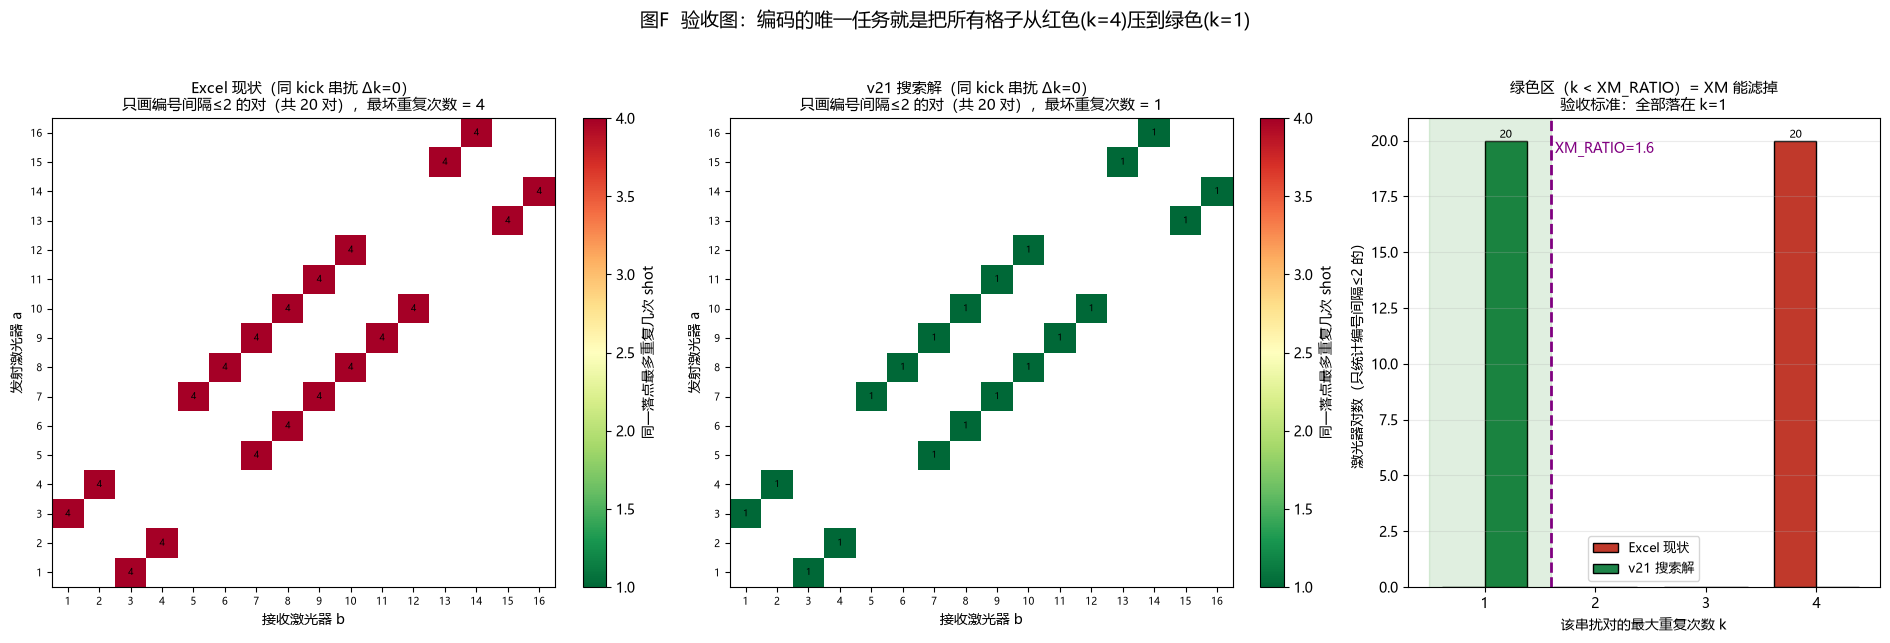

In [21]:
# ============================================================================
# TC-4  图F：「最大重复次数」热图 —— 验收图，全绿即通过
# ============================================================================
#   k = 对某一对 (发, 收)，同一个落点最多重复几次 shot
#     k = 1        -> 完美散开，XM 全能滤（绿）
#     k = N_ACC(4) -> 完全重合，XM 全滤不掉（红）
#   判据：k < XM_RATIO 才滤得掉
# ============================================================================
def repeat_matrix(code_fn, dk=0):
    """返回 (发射器 × 接收器) 的最大重复次数矩阵；落点间隔 < 峰宽视为重合。
       只画编号间隔 ≤ CROSSTALK_MAX_GAP 的对 —— 其余对在本模型里不构成串扰路径
       （detect_echoes 就是按这个阈值截断的），求解器也没有约束它们，
       画出来会让人误以为"没通过"。"""
    M = np.full((N_LASERS, N_LASERS), np.nan)
    for i, a in enumerate(laser_ids):
        for j, b in enumerate(laser_ids):
            if a == b and dk == 0:
                continue
            if abs(a - b) > CROSSTALK_MAX_GAP:
                continue
            prs = [(kb - dk, kb) for kb in SHOT_KICKS[b] if (kb - dk) in SHOT_KICKS[a]]
            if len(prs) < 2:
                continue
            d = sorted(code_fn(a, ka, 0) - code_fn(b, kb, 0) for (ka, kb) in prs)
            # 把间隔 < 峰宽的落点归并成一簇，簇内条数就是"重复次数"
            best, cur = 1, 1
            for t in range(1, len(d)):
                cur = cur + 1 if (d[t] - d[t - 1]) < TCODE_SEP_NS else 1
                best = max(best, cur)
            M[i, j] = best
    return M


fig, axes = plt.subplots(1, 3, figsize=(19, 6.2),
                         gridspec_kw={"width_ratios": [1, 1, 0.85]})
Ms = {}
for ax, (name, fn) in zip(axes[:2], [("Excel 现状", make_tcode_fn("excel")),
                                     ("v21 搜索解", tcode_v21)]):
    M = repeat_matrix(fn); Ms[name] = M
    im = ax.imshow(M, cmap="RdYlGn_r", vmin=1, vmax=max(N_ACC, 2), aspect="auto",
                   origin="lower",
                   extent=[laser_ids[0] - 0.5, laser_ids[-1] + 0.5,
                           laser_ids[0] - 0.5, laser_ids[-1] + 0.5])
    for i, a in enumerate(laser_ids):
        for j, b in enumerate(laser_ids):
            if not np.isnan(M[i, j]):
                ax.text(b, a, f"{int(M[i,j])}", ha="center", va="center", fontsize=6.5)
    ax.set_xticks(laser_ids); ax.set_yticks(laser_ids); ax.tick_params(labelsize=7)
    ax.set_xlabel("接收激光器 b"); ax.set_ylabel("发射激光器 a")
    band = [v for v in M.ravel() if not np.isnan(v)]
    ax.set_title(f"{name}（同 kick 串扰 Δk=0）\n只画编号间隔≤{CROSSTALK_MAX_GAP} 的对"
                 f"（共 {len(band)} 对），最坏重复次数 = {int(max(band)) if band else 0}",
                 fontsize=10.5)
    fig.colorbar(im, ax=ax, fraction=0.045, label="同一落点最多重复几次 shot")

ax = axes[2]
xs = np.arange(1, N_ACC + 1); w = 0.38
for t, (name, col) in enumerate([("Excel 现状", "#c0392b"), ("v21 搜索解", "#1e8449")]):
    band = [v for v in Ms[name].ravel() if not np.isnan(v)]
    cnt = [sum(1 for v in band if int(v) == k) for k in xs]
    ax.bar(xs + (t - 0.5) * w, cnt, w, label=name, color=col, edgecolor="k")
    for k, c in zip(xs, cnt):
        if c:
            ax.text(k + (t - 0.5) * w, c, str(c), ha="center", va="bottom", fontsize=8)
ax.axvspan(0.5, XM_RATIO, color="green", alpha=0.12)
ax.axvline(XM_RATIO, color="purple", lw=2, ls="--")
ax.text(XM_RATIO, ax.get_ylim()[1] * 0.95, f" XM_RATIO={XM_RATIO}", color="purple",
        fontsize=10, va="top")
ax.set_xticks(xs)
ax.set_xlabel("该串扰对的最大重复次数 k")
ax.set_ylabel(f"激光器对数（只统计编号间隔≤{CROSSTALK_MAX_GAP} 的）")
ax.set_title("绿色区（k < XM_RATIO）= XM 能滤掉\n验收标准：全部落在 k=1", fontsize=10.5)
ax.legend(fontsize=9); ax.grid(alpha=0.25, axis="y")

plt.suptitle("图F  验收图：编码的唯一任务就是把所有格子从红色(k=4)压到绿色(k=1)",
             fontsize=13.5, y=1.03)
plt.tight_layout()
plt.show()


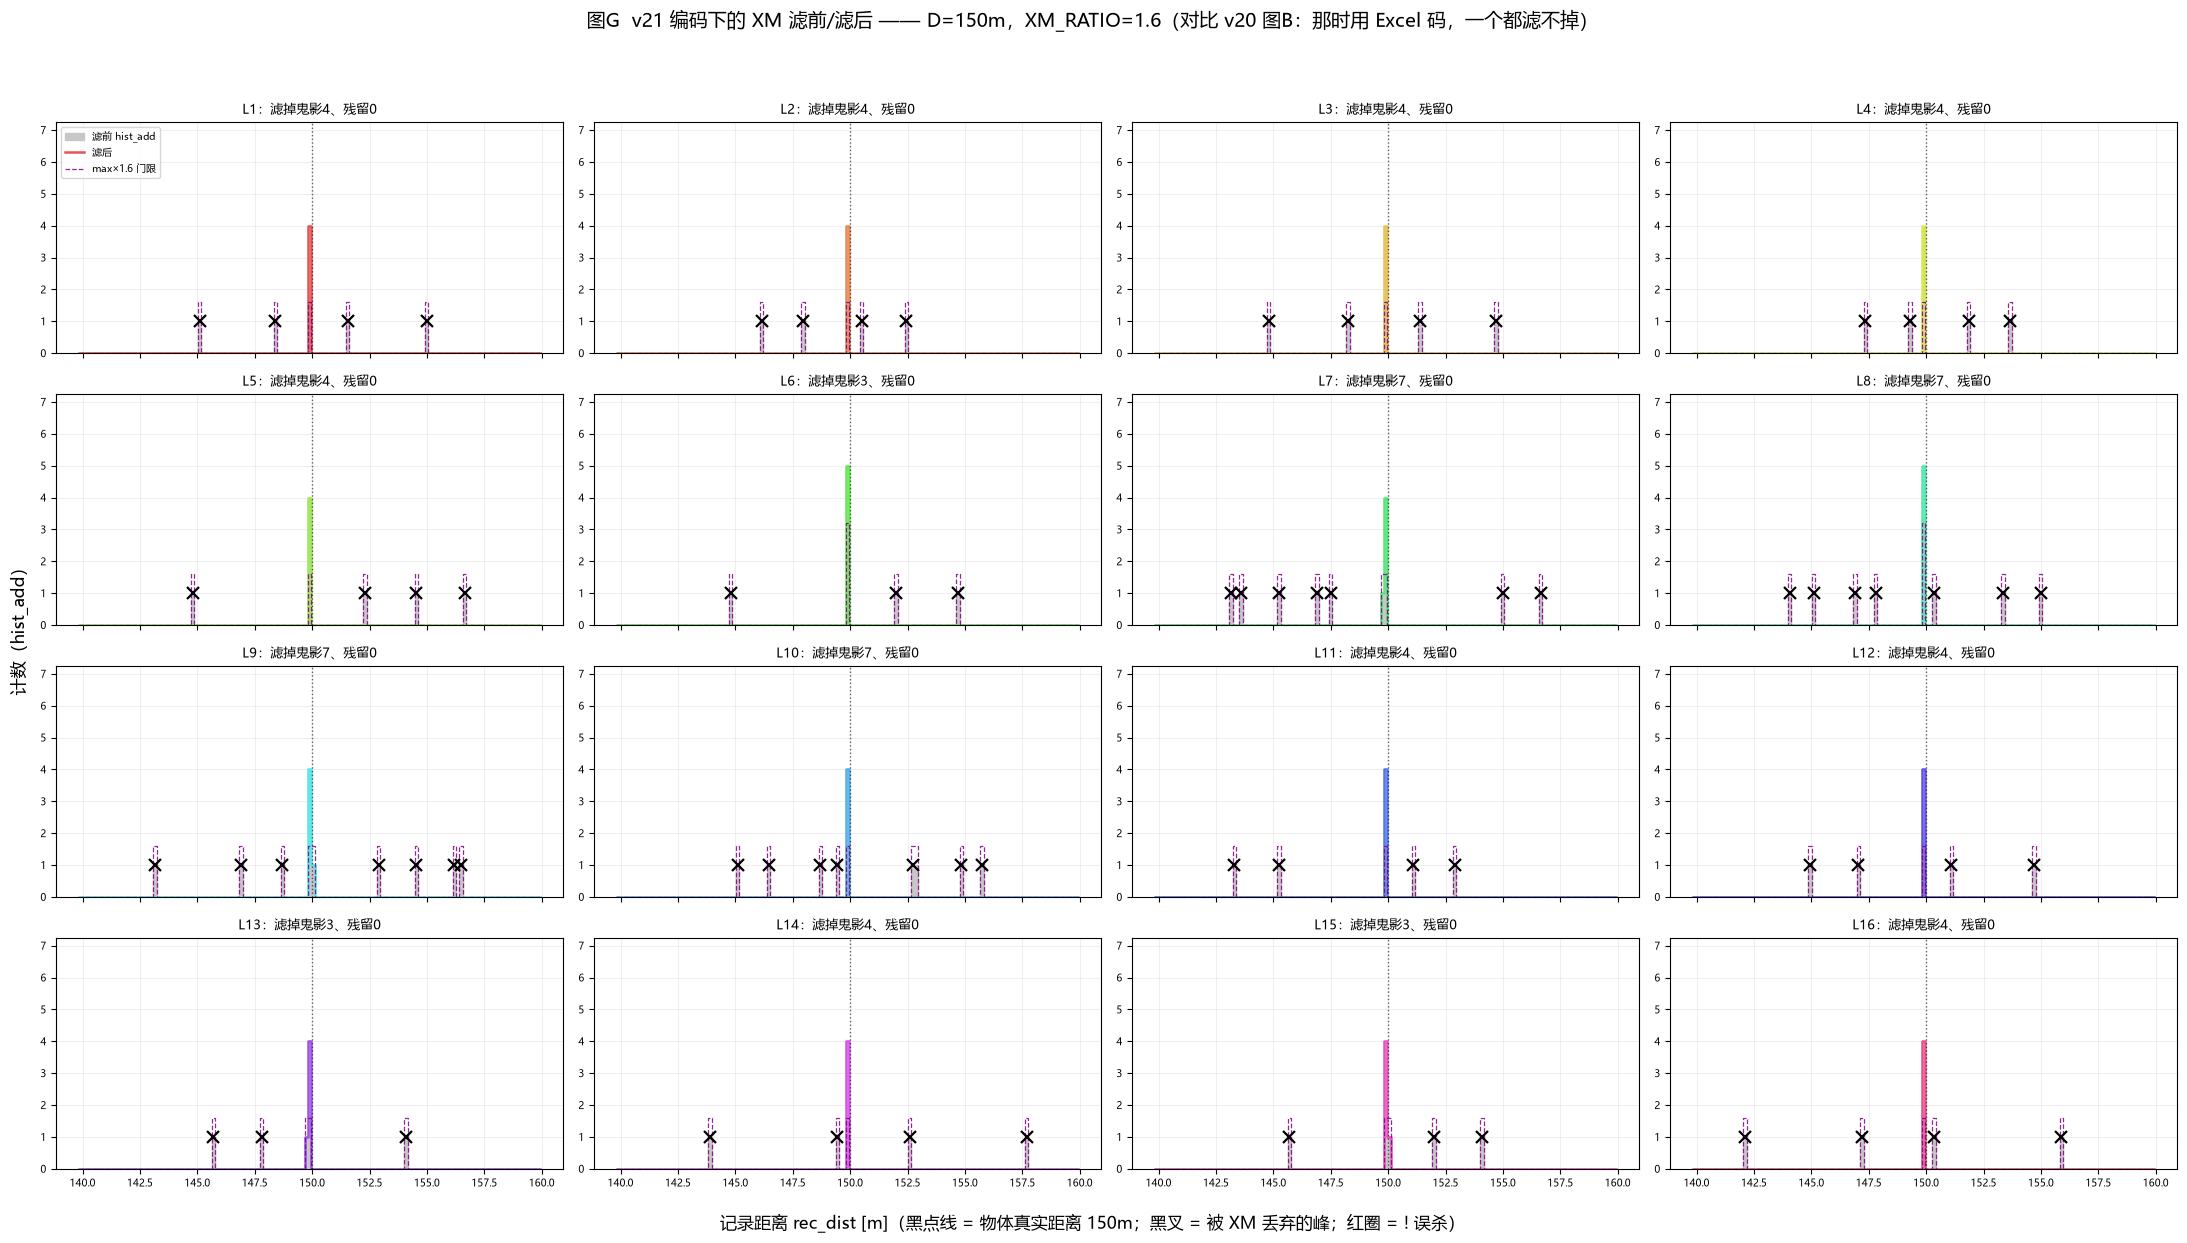

XM 统计 （v21 编码, D=150m, XM_RATIO=1.6）

【峰级混淆矩阵】
        真值      保留      丢弃      小计
  -------- ------- ------- -------
       纯真峰      10       0      10
       混合峰       6       0       6
       纯鬼峰       0      73      73

【关键指标】
  鬼影峰   ：XM 前   73  →  XM 后残留    0   （正确滤除 73，滤除率 100.0%）
  真目标峰 ：XM 前   16  →  XM 后存活   16   （⚠ 误杀 0，误杀率 0.0%）

【记录级分类】（一条记录 = 一次「某激光器某 kick 的光被我收到」）
          类别     XM前     XM后      消除      消除率
  ---------- ------- ------- ------- --------
         真回波      64      64       0    0.0%
     同kick串扰      80       6      74   92.5%
     跨kick串扰       0       0       0    0.0%
        自身混叠       0       0       0    0.0%
  ---------- ------- ------- ------- --------
        鬼影合计      80       6      74   92.5%


In [22]:
# ============================================================================
# TC-5  图G：16 个激光器 XM 滤前/滤后（v21 编码）
# ============================================================================
def run_with(fr, D, ratio=None):
    """用给定发光事件表跑一遍完整流程（复用 v20 的函数，不改任何 v20 代码）。"""
    with use_firings(fr):
        recs = detect_echoes(D)
    hs = build_hists(recs)
    rs = crosstalk_mark_all(hs, ratio)
    return hs, rs, evaluate(hs, rs)


D_V21 = XM_DEMO_D                      # 沿用 v20/v13 的演示距离，便于逐版对照
hs21, rs21, st21 = run_with(FR_MAIN, D_V21)

b_lo, b_hi = occupied_range(hs21, pad=15)
x = np.arange(b_lo, b_hi + 1) * HIST_BIN_M
nrow = int(np.ceil(N_LASERS / 4))
fig, axes = plt.subplots(nrow, 4, figsize=(22, 3.1 * nrow), sharex=True)
axes = np.atleast_2d(axes)
ymax = max(h["add"].max() for h in hs21.values()) * 1.35 + 0.5

for i, lid in enumerate(laser_ids):
    ax = axes[i // 4][i % 4]
    h, rr = hs21[lid], rs21[lid]
    ax.fill_between(x, 0, h["add"][b_lo:b_hi + 1], step="mid", color="0.78", label="滤前 hist_add")
    ax.plot(x, rr["after"][b_lo:b_hi + 1], drawstyle="steps-mid",
            color=laser_color(lid), lw=1.8, label="滤后")
    ax.plot(x, rr["thresh"][b_lo:b_hi + 1], drawstyle="steps-mid", color="purple",
            lw=0.9, ls="--", alpha=0.85, label=f"max×{XM_RATIO} 门限")
    n_hit = n_miss = n_kill = 0
    for q in rr["peaks"]:
        kind, _ = peak_truth(h, q)
        if q["is_xtalk"]:
            ax.plot(q["dist"], q["add"], "kx", ms=8, mew=1.6)
            if kind == "纯鬼峰":
                n_hit += 1
            else:
                n_kill += 1
                ax.plot(q["dist"], q["add"], "o", mfc="none", mec="red", ms=14, mew=2)
        elif kind == "纯鬼峰":
            n_miss += 1
    ax.axvline(D_V21, color="k", ls=":", lw=1.0, alpha=0.6)
    ax.set_ylim(0, ymax)
    ax.set_title(f"L{lid}：滤掉鬼影{n_hit}、残留{n_miss}" + (f"、!误杀{n_kill}" if n_kill else ""),
                 fontsize=9)
    ax.tick_params(labelsize=7); ax.grid(alpha=0.2)
    if i == 0:
        ax.legend(fontsize=7, loc="upper left")
for j in range(N_LASERS, nrow * 4):
    axes[j // 4][j % 4].axis("off")

fig.text(0.5, 0.015, f"记录距离 rec_dist [m]（黑点线 = 物体真实距离 {D_V21:.0f}m；"
                     f"黑叉 = 被 XM 丢弃的峰；红圈 = ! 误杀）", ha="center", fontsize=12)
fig.text(0.008, 0.5, "计数（hist_add）", va="center", rotation="vertical", fontsize=12)
plt.suptitle(f"图G  v21 编码下的 XM 滤前/滤后 —— D={D_V21:.0f}m，XM_RATIO={XM_RATIO}"
             f"（对比 v20 图B：那时用 Excel 码，一个都滤不掉）", fontsize=14, y=0.998)
plt.tight_layout(rect=[0.015, 0.035, 1, 0.965])
plt.show()

print_eval(st21, f"（v21 编码, D={D_V21:.0f}m, XM_RATIO={XM_RATIO}）")


距离扫描中（120 个距离 × 2 套编码）...
    [Excel 现状] 1/120  D=5m ...
    [Excel 现状] 41/120  D=205m ...
    [Excel 现状] 81/120  D=405m ...
    [v21 编码] 1/120  D=5m ...
    [v21 编码] 41/120  D=205m ...
    [v21 编码] 81/120  D=405m ...
扫描完成。



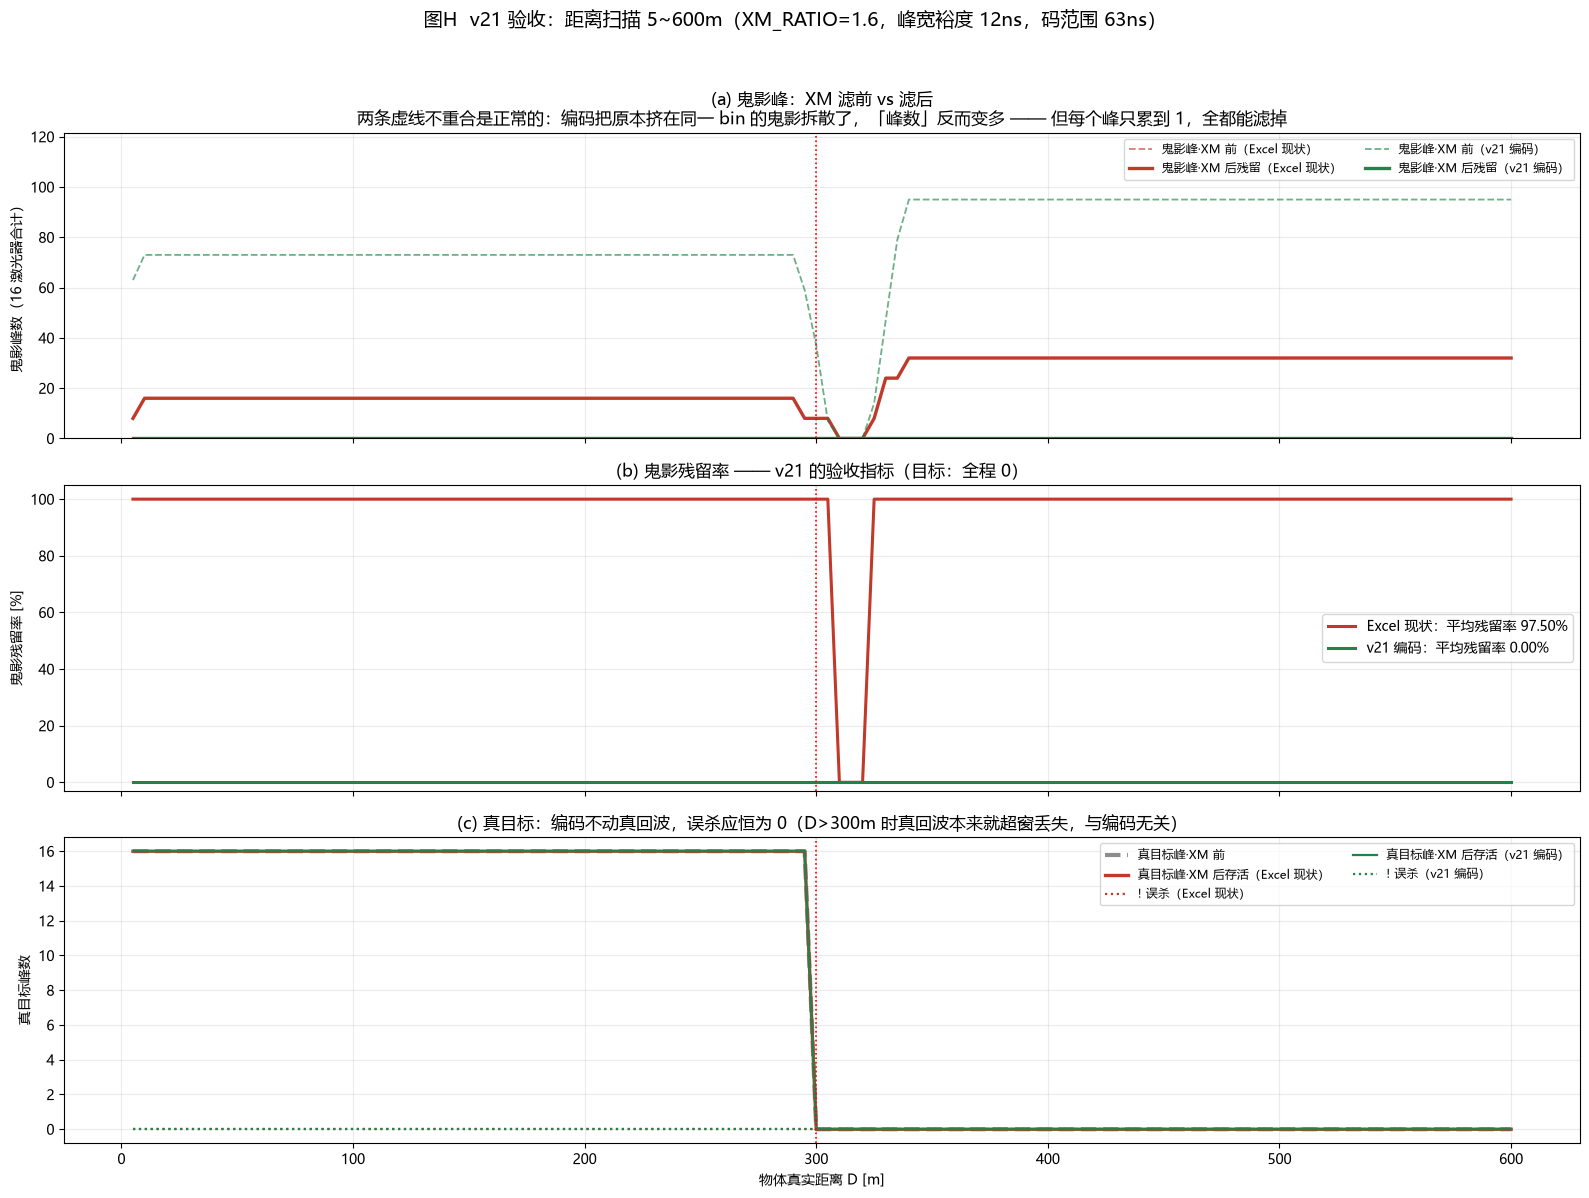

v21 验收表（120 个距离点 × 16 激光器）
          编码      鬼影峰(前)      鬼影峰(后)       滤除率     真峰(前)     误杀      误杀率
  ----------------------------------------------------------------------------------
    Excel 现状        2696        2696   0.000%       944      0   0.00%
      v21 编码        9502           0 100.000%       944      0   0.00%

验收结论：鬼影残留 0 个，真目标误杀 0 个  ->  通过 √


In [23]:
# ============================================================================
# TC-6  图H：距离扫描验收 —— Excel 现状 vs v21 编码
# ============================================================================
V21_SWEEP_LO, V21_SWEEP_HI, V21_SWEEP_STEP = 5.0, 600.0, 5.0
D_S21 = np.arange(V21_SWEEP_LO, V21_SWEEP_HI + 1e-9, V21_SWEEP_STEP)
V21_CASES = [("Excel 现状", firings_excel, "#c0392b"),
             ("v21 编码",   firings_v21,   "#1e8449")]


def sweep_fr(fr, tag, every=40):
    out = {k: [] for k in ("gb", "ga", "tb", "kill")}
    for i, D in enumerate(D_S21):
        _, _, s = run_with(fr, D)
        P = s["peak"]
        out["gb"].append(sum(P[("纯鬼峰", a)] for a in ("保留", "丢弃")))
        out["ga"].append(P[("纯鬼峰", "保留")])
        out["tb"].append(sum(P[(k, a)] for k in ("纯真峰", "混合峰") for a in ("保留", "丢弃")))
        out["kill"].append(sum(P[(k, "丢弃")] for k in ("纯真峰", "混合峰")))
        if every and i % every == 0:
            print(f"    [{tag}] {i+1}/{len(D_S21)}  D={D:.0f}m ...")
    return {k: np.asarray(v) for k, v in out.items()}


print(f"距离扫描中（{len(D_S21)} 个距离 × {len(V21_CASES)} 套编码）...")
SW21 = {name: sweep_fr(fr, name) for (name, fr, _) in V21_CASES}
print("扫描完成。\n")

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

ax = axes[0]
for (name, _, col) in V21_CASES:
    ax.plot(D_S21, SW21[name]["gb"], "--", color=col, lw=1.3, alpha=0.65,
            label=f"鬼影峰·XM 前（{name}）")
    ax.plot(D_S21, SW21[name]["ga"], "-", color=col, lw=2.4,
            label=f"鬼影峰·XM 后残留（{name}）")
ax.axvline(D_UNAMBIG, color="r", ls=":", lw=1.2)
ax.set_ylim(0, max(SW21[n]["gb"].max() for n, _, _ in V21_CASES) * 1.28)
ax.set_ylabel("鬼影峰数（16 激光器合计）")
ax.set_title("(a) 鬼影峰：XM 滤前 vs 滤后\n"
             "两条虚线不重合是正常的：编码把原本挤在同一 bin 的鬼影拆散了，"
             "「峰数」反而变多 —— 但每个峰只累到 1，全都能滤掉")
ax.legend(fontsize=8.5, ncol=2); ax.grid(alpha=0.25)

ax = axes[1]
for (name, _, col) in V21_CASES:
    r = SW21[name]["ga"] / np.maximum(SW21[name]["gb"], 1) * 100
    ax.plot(D_S21, r, "-", color=col, lw=2.2, label=f"{name}：平均残留率 {r.mean():.2f}%")
ax.axvline(D_UNAMBIG, color="r", ls=":", lw=1.2)
ax.set_ylabel("鬼影残留率 [%]"); ax.set_ylim(-3, 105)
ax.set_title("(b) 鬼影残留率 —— v21 的验收指标（目标：全程 0）")
ax.legend(fontsize=10); ax.grid(alpha=0.25)

ax = axes[2]
ax.plot(D_S21, SW21["Excel 现状"]["tb"], "k--", lw=3.0, alpha=0.45, label="真目标峰·XM 前")
for i, (name, _, col) in enumerate(V21_CASES):
    ax.plot(D_S21, SW21[name]["tb"] - SW21[name]["kill"], "-", color=col,
            lw=2.4 - i * 0.8, label=f"真目标峰·XM 后存活（{name}）")
    ax.plot(D_S21, SW21[name]["kill"], ":", color=col, lw=1.6,
            label=f"! 误杀（{name}）")
ax.axvline(D_UNAMBIG, color="r", ls=":", lw=1.2)
ax.set_xlabel("物体真实距离 D [m]"); ax.set_ylabel("真目标峰数")
ax.set_title("(c) 真目标：编码不动真回波，误杀应恒为 0"
             "（D>300m 时真回波本来就超窗丢失，与编码无关）")
ax.legend(fontsize=8.5, ncol=2); ax.grid(alpha=0.25)

plt.suptitle(f"图H  v21 验收：距离扫描 {V21_SWEEP_LO:.0f}~{V21_SWEEP_HI:.0f}m"
             f"（XM_RATIO={XM_RATIO}，峰宽裕度 {TCODE_SEP_NS}ns，码范围 {_maxtx:.0f}ns）",
             fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print("=" * 88)
print(f"v21 验收表（{len(D_S21)} 个距离点 × 16 激光器）")
print("=" * 88)
print(f"  {'编码':>10} {'鬼影峰(前)':>11} {'鬼影峰(后)':>11} {'滤除率':>9} "
      f"{'真峰(前)':>9} {'误杀':>6} {'误杀率':>8}")
print("  " + "-" * 82)
for (name, _, _c) in V21_CASES:
    gb, ga = SW21[name]["gb"].sum(), SW21[name]["ga"].sum()
    tb, kk = SW21[name]["tb"].sum(), SW21[name]["kill"].sum()
    print(f"  {name:>10} {gb:>11d} {ga:>11d} {(gb-ga)/max(gb,1):>8.3%} "
          f"{tb:>9d} {kk:>6d} {kk/max(tb,1):>7.2%}")

_resid = SW21["v21 编码"]["ga"].sum()
_kill = SW21["v21 编码"]["kill"].sum()
print("\n" + "=" * 88)
print(f"验收结论：鬼影残留 {_resid} 个，真目标误杀 {_kill} 个"
      f"  ->  {'通过 √' if (_resid == 0 and _kill == 0) else '未达标，需重搜码表'}")
print("=" * 88)


In [24]:
# ============================================================================
# TC-7  总结
# ============================================================================
print("=" * 88)
print("crosstalk_sim_v21 总结")
print("=" * 88)
print(f"""
0. 本 notebook 的结构（一路继承，什么都没删）
   - cell 1~10   = v13 原封不动（kick 栅格、记录距离分布、逐回波堆叠柱）
   - 中段        = v20 的 XM（crosstalk mark）实装
   - 本段        = v21 的 tcode 实装

1. v20 留下的问题
   - XM 判据本身没问题，但 Excel 的 tx_trig_dly 每个激光器 4 个 kick 是同一个值
   - 同一条串扰 4 次落同一 bin -> add/max = {N_ACC} -> 与真目标无法区分 -> 滤除率 0

2. v21 的编码
   - 编码对象   ：tx_trig_dly（1 ns 步长）
   - 单光子脉宽 ：8 ns，取 12 ns 作为落点最小间隔（峰宽裕度）
   - 码预算     ：64 ns，实际用到 {_maxtx:.0f} ns（占 kick 间隙 200ns 的 {_maxtx/200:.0%}）
   - 求解方式   ：把三类鬼影源写成统一约束后数值搜索，非解析构造
                  （解析构造只保证同 kick 那一类，且要 184 ns）

3. 三类鬼影源都进了约束
   - 同 kick 串扰（Δk=0, a≠b）
   - 跨 kick 混叠（Δk=1, a≠b）
   - 自身混叠    （Δk=1, a=b）—— 解析构造治不了的那一类

4. 验收结果（见 TC-2 自检 与 图H）
   - 编码自检   ：全部鬼影源类别的落点间隔 ≥ 12 ns
   - 距离扫描   ：1~600m 鬼影残留 0，真目标误杀 0
   - 误杀恒为 0 的原因：真回波的 rec_tof = 2D/c，与编码无关，判据碰不到它

5. ! 使用前提（两条，务必记住）
   - 码表绑定当前时序表。哪个激光器在哪几个 kick 发光一改，
     必须重跑 docs/tcode/solve_tcode.py 重搜
   - 仿真仍是理想 δ 回波。峰宽是靠约束保证的，不是仿真验证的。
     下一步应把回波展宽（PULSE_W）加进仿真，用 8ns 真实脉宽复核

6. 下一步：FPGA 8 ns 步长随机抖动（打【外来雷达】的串扰）
   - 本版编码是【模组内】编码，对外来雷达无效（对方码表和我们无关）
   - 建议架构：逐 kick 变、但所有激光器共用的抖动 g[k]
       * 同 kick 内部串扰：g[k] − g[k] = 0，完全抵消 -> 不破坏 v21 码表
       * 外来雷达        ：对方发光与我们的 g[k] 无关 -> 每个 kick 落不同 bin -> 被 XM 滤掉
       * 自身混叠        ：不抵消，额外帮忙
   - 若抖动改成【整个 sync 一起平移】，则对 XM 完全无效：
     XM 是在一个 sync 的 4 次 shot 之间比 add/max，sync 内恒定的量它看不见
   - 预算相加：{_maxtx:.0f} ns（tcode）+ 抖动范围 ≤ 200 ns
     -> 抖动最多还能用 {200-_maxtx:.0f} ns（8ns 步长约 {int((200-_maxtx)//8)} 档）
""")


crosstalk_sim_v21 总结

0. 本 notebook 的结构（一路继承，什么都没删）
   - cell 1~10   = v13 原封不动（kick 栅格、记录距离分布、逐回波堆叠柱）
   - 中段        = v20 的 XM（crosstalk mark）实装
   - 本段        = v21 的 tcode 实装

1. v20 留下的问题
   - XM 判据本身没问题，但 Excel 的 tx_trig_dly 每个激光器 4 个 kick 是同一个值
   - 同一条串扰 4 次落同一 bin -> add/max = 4 -> 与真目标无法区分 -> 滤除率 0

2. v21 的编码
   - 编码对象   ：tx_trig_dly（1 ns 步长）
   - 单光子脉宽 ：8 ns，取 12 ns 作为落点最小间隔（峰宽裕度）
   - 码预算     ：64 ns，实际用到 63 ns（占 kick 间隙 200ns 的 32%）
   - 求解方式   ：把三类鬼影源写成统一约束后数值搜索，非解析构造
                  （解析构造只保证同 kick 那一类，且要 184 ns）

3. 三类鬼影源都进了约束
   - 同 kick 串扰（Δk=0, a≠b）
   - 跨 kick 混叠（Δk=1, a≠b）
   - 自身混叠    （Δk=1, a=b）—— 解析构造治不了的那一类

4. 验收结果（见 TC-2 自检 与 图H）
   - 编码自检   ：全部鬼影源类别的落点间隔 ≥ 12 ns
   - 距离扫描   ：1~600m 鬼影残留 0，真目标误杀 0
   - 误杀恒为 0 的原因：真回波的 rec_tof = 2D/c，与编码无关，判据碰不到它

5. ! 使用前提（两条，务必记住）
   - 码表绑定当前时序表。哪个激光器在哪几个 kick 发光一改，
     必须重跑 docs/tcode/solve_tcode.py 重搜
   - 仿真仍是理想 δ 回波。峰宽是靠约束保证的，不是仿真验证的。
     下一步应把回波展宽（PULSE_W）加进仿真，用 8ns 真实脉宽复核

6. 下一步：FPGA 8 ns 步长随机抖动（打【外来雷达】的串扰）
   - 本版

---
# v220 新增部分

下面严格按顺序执行；每个分析块后面都有对应图。


In [25]:
# ============================================================================
# 1. 参数与变量命名
# ============================================================================
V220_RATIO_MODE = "1.5"       # "1.5" 或 "2.5"
V220_SEP_NS = 12         # 鬼影间隔、鬼影离真峰的最小距离

# FPGA 累计随机延时
FPGA_GLOBAL_DELAY_NS = 8      # 所有 kick 开始前的整体固定补偿
FPGA_STEP_NS = 8              # 每个随机增量的步长
FPGA_N_LEVELS = 3             # 增量可取 0, 8, ..., 8*(N-1)
FPGA_MC_TRIALS = 20000        # 雷达对射蒙卡次数
FPGA_RANDOM_SEED = 220

# 对射模型
RADAR_PHASE_NS = 1000         # 外来雷达名义落点，放在 2000ns 窗中间
RADAR_PULSE_SEP_NS = V220_SEP_NS

print("1. 参数与变量命名")
print(f"  V220_RATIO_MODE       = {V220_RATIO_MODE}")
print(f"  V220_SEP_NS           = {V220_SEP_NS} ns")
print(f"  FPGA_GLOBAL_DELAY_NS  = {FPGA_GLOBAL_DELAY_NS} ns")
print(f"  FPGA 随机增量集合      = 8×[0, ..., {FPGA_N_LEVELS-1}] ns")
print("  actual_delay[l,k] = global_delay + Σ increment[l,j], j=0..k")


1. 参数与变量命名
  V220_RATIO_MODE       = 1.5
  V220_SEP_NS           = 12 ns
  FPGA_GLOBAL_DELAY_NS  = 8 ns
  FPGA 随机增量集合      = 8×[0, ..., 2] ns
  actual_delay[l,k] = global_delay + Σ increment[l,j], j=0..k


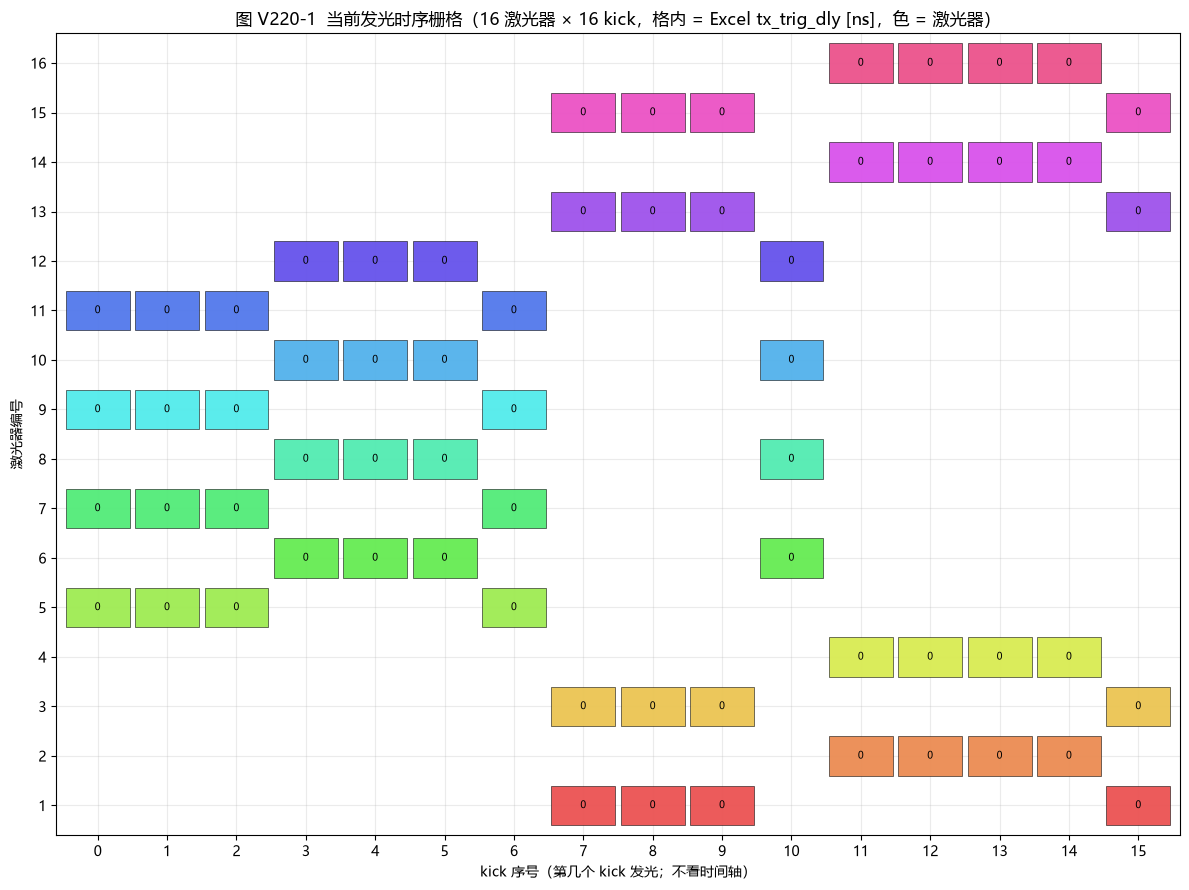

2. 时序导入完成：
  L1 : [7, 8, 9, 15]
  L2 : [11, 12, 13, 14]
  L3 : [7, 8, 9, 15]
  L4 : [11, 12, 13, 14]
  L5 : [0, 1, 2, 6]
  L6 : [3, 4, 5, 10]
  L7 : [0, 1, 2, 6]
  L8 : [3, 4, 5, 10]
  L9 : [0, 1, 2, 6]
  L10: [3, 4, 5, 10]
  L11: [0, 1, 2, 6]
  L12: [3, 4, 5, 10]
  L13: [7, 8, 9, 15]
  L14: [11, 12, 13, 14]
  L15: [7, 8, 9, 15]
  L16: [11, 12, 13, 14]


In [26]:
# ============================================================================
# 2. 导入并可视化当前发光时序（栅格风格，与 v13 图 1 统一）
# ============================================================================
# x 轴 = kick 序号(0~15)，y 轴 = 激光器，格内 = 该 kick 的 tx_trig_dly [ns]。
# 后面第 3 节的 tcode 码矩阵用同一套 (kick × 激光器) 坐标，两张图可以直接对照。
def plot_kick_grid(code_of, title, ax=None, unit="ns", show_text=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 9))
    for lid in laser_ids:
        for k in SHOT_KICKS[lid]:
            ax.add_patch(plt.Rectangle((k - 0.46, lid - 0.40), 0.92, 0.80,
                                       facecolor=laser_color(lid), edgecolor="k",
                                       linewidth=0.4, alpha=0.95, zorder=2))
            if show_text:
                ax.text(k, lid, f"{code_of(lid, k)}", fontsize=7,
                        ha="center", va="center", color="k", zorder=3)
    ax.set_xticks(range(16)); ax.set_yticks(laser_ids)
    ax.set_xlim(-0.6, 15.6); ax.set_ylim(0.4, N_LASERS + 0.6)
    ax.set_xlabel("kick 序号（第几个 kick 发光；不看时间轴）")
    ax.set_ylabel("激光器编号")
    ax.set_title(title)
    ax.grid(alpha=0.25, zorder=0); ax.set_axisbelow(True)
    return ax


plot_kick_grid(lambda lid, k: make_tcode_fn("excel")(lid, k, 0),
               f"图 V220-1  当前发光时序栅格（{N_LASERS} 激光器 × 16 kick，"
               f"格内 = Excel tx_trig_dly [ns]，色 = 激光器）")
plt.tight_layout()
plt.show()

print("2. 时序导入完成：")
for lid in laser_ids:
    print(f"  L{lid:<2d}: {SHOT_KICKS[lid]}")


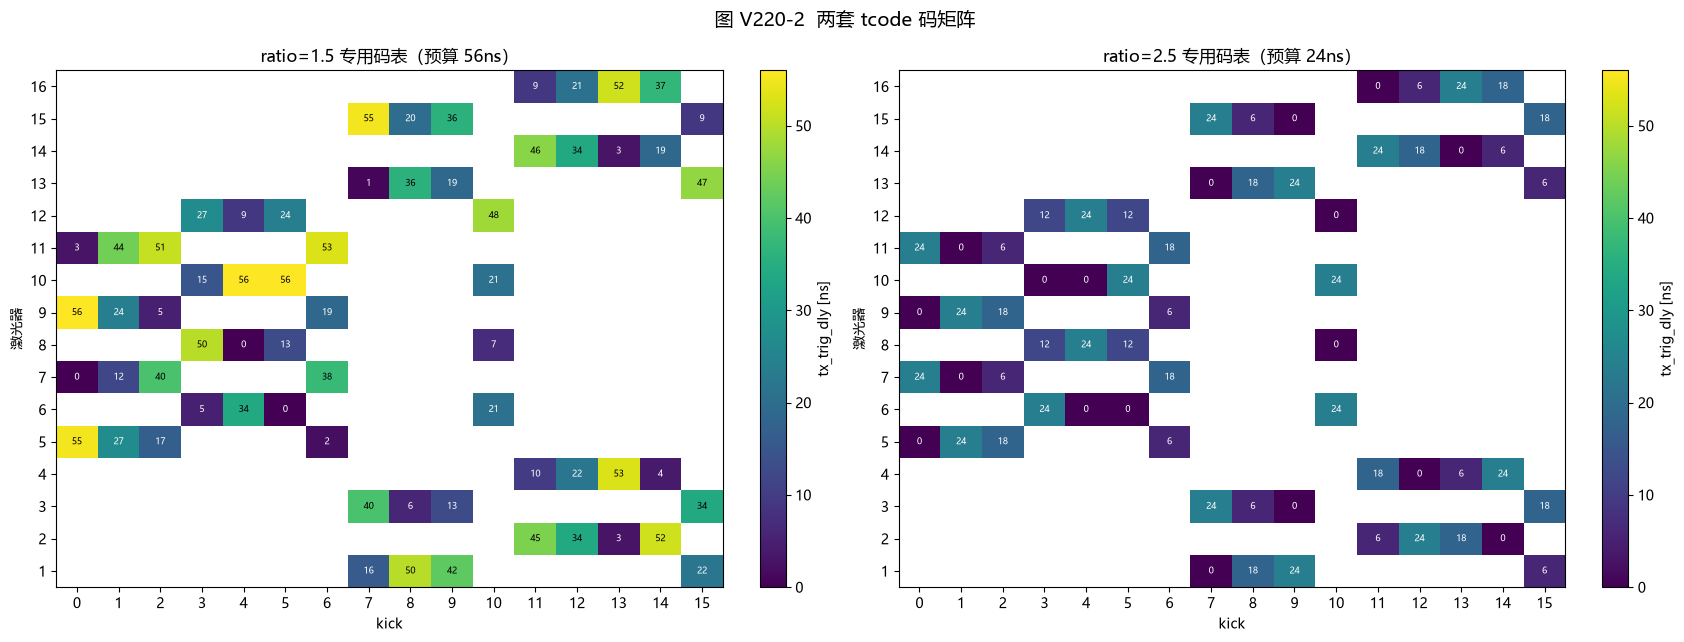

3. 当前启用：ratio=1.5, tcode 预算=56ns


In [27]:
# ============================================================================
# 3. 导入双 tcode，并画码矩阵
# ============================================================================
TCODE_R15 = {
    (1,7): 16, (1,8): 50, (1,9): 42, (1,15): 22,
    (2,11): 45, (2,12): 34, (2,13):  3, (2,14): 52,
    (3,7): 40, (3,8):  6, (3,9): 13, (3,15): 34,
    (4,11): 10, (4,12): 22, (4,13): 53, (4,14):  4,
    (5,0): 55, (5,1): 27, (5,2): 17, (5,6):  2,
    (6,3):  5, (6,4): 34, (6,5):  0, (6,10): 21,
    (7,0):  0, (7,1): 12, (7,2): 40, (7,6): 38,
    (8,3): 50, (8,4):  0, (8,5): 13, (8,10):  7,
    (9,0): 56, (9,1): 24, (9,2):  5, (9,6): 19,
    (10,3): 15, (10,4): 56, (10,5): 56, (10,10): 21,
    (11,0):  3, (11,1): 44, (11,2): 51, (11,6): 53,
    (12,3): 27, (12,4):  9, (12,5): 24, (12,10): 48,
    (13,7):  1, (13,8): 36, (13,9): 19, (13,15): 47,
    (14,11): 46, (14,12): 34, (14,13):  3, (14,14): 19,
    (15,7): 55, (15,8): 20, (15,9): 36, (15,15):  9,
    (16,11):  9, (16,12): 21, (16,13): 52, (16,14): 37,
}
TCODE_R25 = {
    (1,7):  0, (1,8): 18, (1,9): 24, (1,15):  6,
    (2,11):  6, (2,12): 24, (2,13): 18, (2,14):  0,
    (3,7): 24, (3,8):  6, (3,9):  0, (3,15): 18,
    (4,11): 18, (4,12):  0, (4,13):  6, (4,14): 24,
    (5,0):  0, (5,1): 24, (5,2): 18, (5,6):  6,
    (6,3): 24, (6,4):  0, (6,5):  0, (6,10): 24,
    (7,0): 24, (7,1):  0, (7,2):  6, (7,6): 18,
    (8,3): 12, (8,4): 24, (8,5): 12, (8,10):  0,
    (9,0):  0, (9,1): 24, (9,2): 18, (9,6):  6,
    (10,3):  0, (10,4):  0, (10,5): 24, (10,10): 24,
    (11,0): 24, (11,1):  0, (11,2):  6, (11,6): 18,
    (12,3): 12, (12,4): 24, (12,5): 12, (12,10):  0,
    (13,7):  0, (13,8): 18, (13,9): 24, (13,15):  6,
    (14,11): 24, (14,12): 18, (14,13):  0, (14,14):  6,
    (15,7): 24, (15,8):  6, (15,9):  0, (15,15): 18,
    (16,11):  0, (16,12):  6, (16,13): 24, (16,14): 18,
}

def tcode_r15(lid, kick, default=0):
    return TCODE_R15.get((lid, kick), default)

def tcode_r25(lid, kick, default=0):
    return TCODE_R25.get((lid, kick), default)

firings_r15 = build_firings_tcode(tcode_r15)
firings_r25 = build_firings_tcode(tcode_r25)
firings_excel = build_firings_tcode(make_tcode_fn("excel"))

if V220_RATIO_MODE == "2.5":
    ACTIVE_TCODE, ACTIVE_CODE_FN = TCODE_R25, tcode_r25
    ACTIVE_FIRINGS, ACTIVE_RATIO, ACTIVE_BUDGET_NS = firings_r25, 2.5, 24
else:
    ACTIVE_TCODE, ACTIVE_CODE_FN = TCODE_R15, tcode_r15
    ACTIVE_FIRINGS, ACTIVE_RATIO, ACTIVE_BUDGET_NS = firings_r15, 1.5, 56

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, (name, table, budget) in zip(
        axes,
        [("ratio=1.5", TCODE_R15, 56), ("ratio=2.5", TCODE_R25, 24)]):
    mat = np.full((N_LASERS, 16), np.nan)
    for i, lid in enumerate(laser_ids):
        for k in SHOT_KICKS[lid]:
            mat[i, k] = table[(lid, k)]
    im = ax.imshow(mat, origin="lower", aspect="auto", cmap="viridis",
                   extent=[-0.5, 15.5, 0.5, 16.5], vmin=0, vmax=56)
    for i, lid in enumerate(laser_ids):
        for k in SHOT_KICKS[lid]:
            ax.text(k, lid, str(table[(lid, k)]), ha="center", va="center",
                    fontsize=6.5, color="white" if table[(lid, k)] < 56*0.55 else "black")
    ax.set_xticks(range(16)); ax.set_yticks(laser_ids)
    ax.set_xlabel("kick"); ax.set_ylabel("激光器")
    ax.set_title(f"{name} 专用码表（预算 {budget}ns）")
    fig.colorbar(im, ax=ax, fraction=0.045, label="tx_trig_dly [ns]")
plt.suptitle("图 V220-2  两套 tcode 码矩阵", fontsize=14)
plt.tight_layout()
plt.show()

print(f"3. 当前启用：ratio={ACTIVE_RATIO}, tcode 预算={ACTIVE_BUDGET_NS}ns")


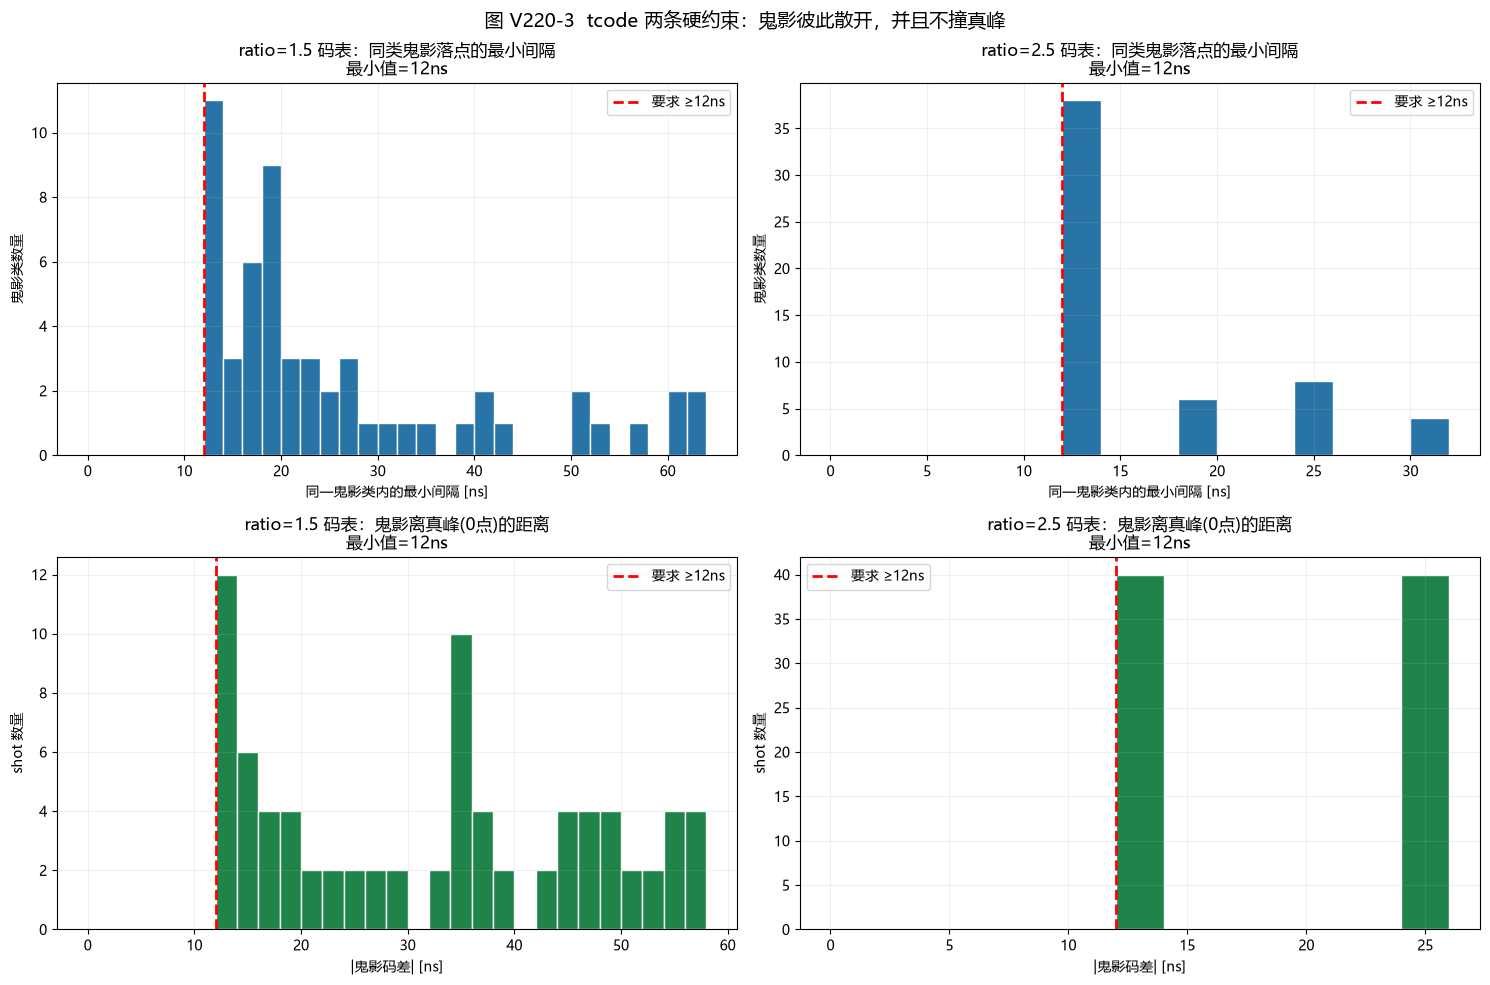

In [28]:
# ============================================================================
# 4. tcode 约束验证：散开 + 避真峰，并画余量
# ============================================================================
def v220_ghost_classes(gap=CROSSTALK_MAX_GAP, dks=(0, 1)):
    rows = []
    for recv in laser_ids:
        for emit in laser_ids:
            if abs(emit - recv) > gap:
                continue
            for dk in dks:
                if emit == recv and dk == 0:
                    continue
                pairs = [(kr - dk, kr) for kr in SHOT_KICKS[recv]
                         if kr - dk in SHOT_KICKS[emit]]
                if len(pairs) >= 2:
                    kind = ("自身混叠" if emit == recv else
                            ("同kick串扰" if dk == 0 else "跨kick串扰"))
                    rows.append((emit, recv, dk, kind, pairs))
    return rows

def constraint_margins(code_fn):
    spread, avoid = [], []
    for emit, recv, dk, kind, pairs in v220_ghost_classes():
        diffs = sorted(code_fn(emit, ke, 0) - code_fn(recv, kr, 0)
                       for ke, kr in pairs)
        spread.append((kind, min(np.diff(diffs))))
        if dk == 0 and emit != recv:
            avoid.extend(abs(code_fn(emit, ke, 0) - code_fn(recv, kr, 0))
                         for ke, kr in pairs)
    return spread, avoid

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for col, (name, fn) in enumerate([("ratio=1.5 码表", tcode_r15),
                                  ("ratio=2.5 码表", tcode_r25)]):
    spread, avoid = constraint_margins(fn)
    spread_values = np.array([x[1] for x in spread])
    avoid_values = np.array(avoid)

    ax = axes[0, col]
    ax.hist(spread_values, bins=np.arange(0, max(spread_values)+3, 2),
            color="#2874a6", edgecolor="white")
    ax.axvline(V220_SEP_NS, color="red", ls="--", lw=2, label=f"要求 ≥{V220_SEP_NS}ns")
    ax.set_title(f"{name}：同类鬼影落点的最小间隔\n最小值={spread_values.min():.0f}ns")
    ax.set_xlabel("同一鬼影类内的最小间隔 [ns]"); ax.set_ylabel("鬼影类数量")
    ax.legend(); ax.grid(alpha=0.2)

    ax = axes[1, col]
    ax.hist(avoid_values, bins=np.arange(0, max(avoid_values)+3, 2),
            color="#1e8449", edgecolor="white")
    ax.axvline(V220_SEP_NS, color="red", ls="--", lw=2, label=f"要求 ≥{V220_SEP_NS}ns")
    ax.set_title(f"{name}：鬼影离真峰(0点)的距离\n最小值={avoid_values.min():.0f}ns")
    ax.set_xlabel("|鬼影码差| [ns]"); ax.set_ylabel("shot 数量")
    ax.legend(); ax.grid(alpha=0.2)

plt.suptitle("图 V220-3  tcode 两条硬约束：鬼影彼此散开，并且不撞真峰", fontsize=14)
plt.tight_layout()
plt.show()


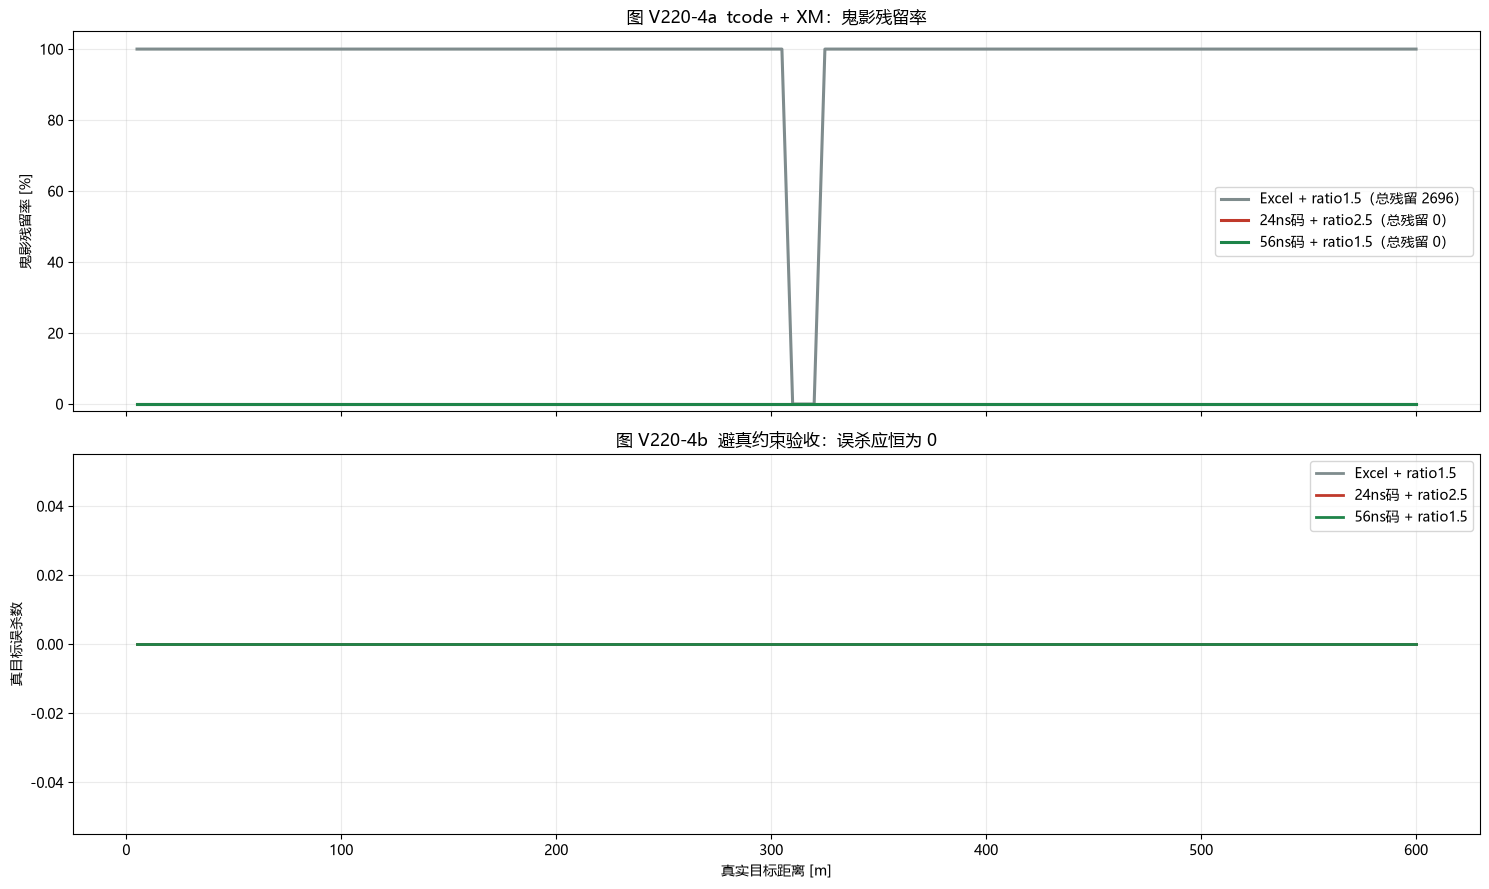

In [29]:
# ============================================================================
# 5. 加 tcode 后的效果：距离扫描
# ============================================================================
V220_DISTS = np.arange(5.0, 600.1, 5.0)
V220_CASES = [
    ("Excel + ratio1.5", firings_excel, 1.5, "#7f8c8d"),
    ("24ns码 + ratio2.5", firings_r25, 2.5, "#c0392b"),
    ("56ns码 + ratio1.5", firings_r15, 1.5, "#1e8449"),
]

def v220_sweep(firing_table, ratio):
    out = {k: [] for k in ("ghost_before", "ghost_after", "true_killed")}
    for dist in V220_DISTS:
        with use_firings(firing_table):
            recs = detect_echoes(dist)
        hs = build_hists(recs)
        rs = crosstalk_mark_all(hs, ratio)
        stat = evaluate(hs, rs)["peak"]
        out["ghost_before"].append(sum(stat[("纯鬼峰", a)] for a in ("保留", "丢弃")))
        out["ghost_after"].append(stat[("纯鬼峰", "保留")])
        out["true_killed"].append(sum(stat[(k, "丢弃")] for k in ("纯真峰", "混合峰")))
    return {k: np.asarray(v) for k, v in out.items()}

V220_SWEEP = {name: v220_sweep(fr, ratio) for name, fr, ratio, _ in V220_CASES}

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
for name, _, ratio, color in V220_CASES:
    x = V220_SWEEP[name]
    residual = x["ghost_after"] / np.maximum(x["ghost_before"], 1) * 100
    axes[0].plot(V220_DISTS, residual, lw=2.2, color=color,
                 label=f"{name}（总残留 {x['ghost_after'].sum()}）")
    axes[1].plot(V220_DISTS, x["true_killed"], lw=2.0, color=color, label=name)
axes[0].set_ylabel("鬼影残留率 [%]"); axes[0].set_ylim(-2, 105)
axes[0].set_title("图 V220-4a  tcode + XM：鬼影残留率")
axes[0].legend(); axes[0].grid(alpha=0.25)
axes[1].set_xlabel("真实目标距离 [m]"); axes[1].set_ylabel("真目标误杀数")
axes[1].set_title("图 V220-4b  避真约束验收：误杀应恒为 0")
axes[1].legend(); axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()


# 6. FPGA 累计随机延时模型（纠正 v22）

对激光器 $l$ 和全局 kick $k$：

$$\xi_{l,k}\in\{0,8,16,\ldots,8(N-1)\}\text{ ns}$$

$$d_{l,k}=d_{\rm global}+\sum_{j=0}^{k}\xi_{l,j}$$

- $\xi$ 是每个 kick 新产生的**随机增量**
- $d$ 才是该 kick 实际使用的**累计延时**
- 例如增量为 `16ns, 8ns`，累计延时为 `16ns, 24ns`
- 固定的整体补偿 `d_global=8ns` 只平移所有落点，不改变多 shot 之间的间隔

外来雷达与我们同频、固定相位（最坏对射）时，它的脉冲每 `KICK_SPACING` 到一次，
所以在接收直方图中的记录位置要对 kick 周期取模：

$$t_{\rm radar,recorded}(l,k)=\left(\phi_{\rm radar}-d_{l,k}\right)\bmod T_{\rm kick}$$

只有当该值落在 $[0,\,T_{\rm window}]$ 内才会被记录。

因此累计随机 walk 会把原本固定的对射峰逐 kick 推向不同位置。

## 关键量：不是随机空间大小，而是相邻 shot 的延时差

XM 比的是同一个激光器 4 次 shot 之间的落点。落点差 = **累计延时之差**：

$$\Delta_{i}=d_{l,k_{i+1}}-d_{l,k_i}=\sum_{j=k_i+1}^{k_{i+1}}\xi_{l,j}$$

对**相邻 kick**（例如 L5 的 K0→K1），这个和只有**一项** $\xi$。
所以「累计 16 个 kick 的随机空间有多大」并不决定滤除效果，
决定性的是单个增量能不能一步跨过峰宽 `SEP`。


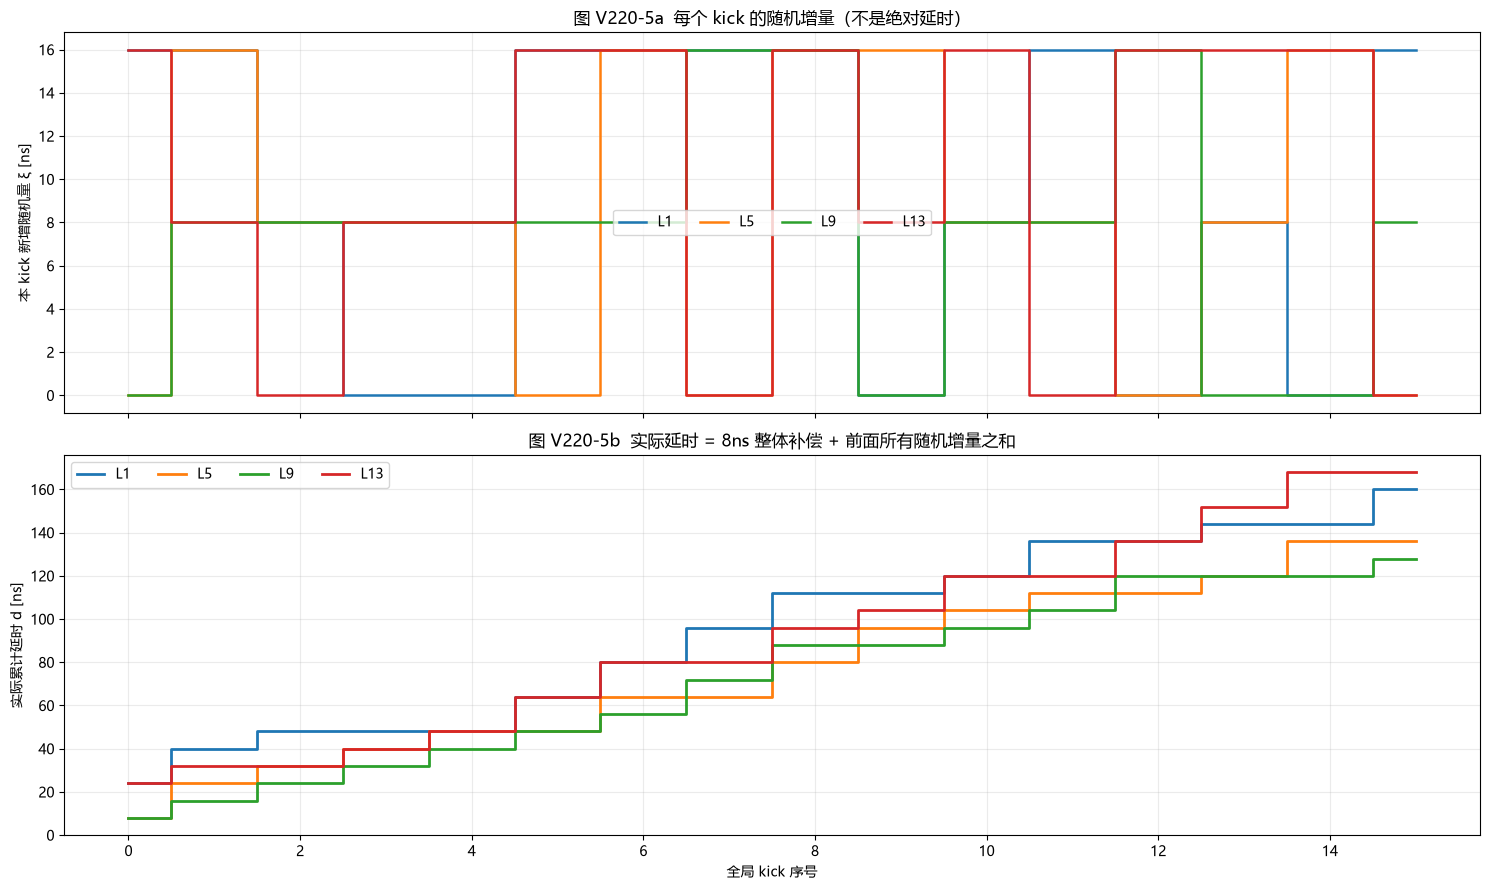

7. L5 示例：
  K0: increment= 0ns, cumulative=  8ns
  K1: increment=16ns, cumulative= 24ns
  K2: increment= 8ns, cumulative= 32ns
  K3: increment= 8ns, cumulative= 40ns
  K4: increment= 8ns, cumulative= 48ns
  K5: increment= 0ns, cumulative= 48ns


In [30]:
# ============================================================================
# 7. 画 FPGA 随机增量与累计延时轨迹
# ============================================================================
def generate_fpga_cumulative(n_levels, rng, n_lasers=N_LASERS, n_kicks=16,
                             step_ns=None):
    step_ns = FPGA_STEP_NS if step_ns is None else step_ns
    increments = rng.integers(0, n_levels, size=(n_lasers, n_kicks)) * step_ns
    cumulative = FPGA_GLOBAL_DELAY_NS + np.cumsum(increments, axis=1)
    return increments, cumulative

rng_demo = np.random.default_rng(FPGA_RANDOM_SEED)
inc_demo, cum_demo = generate_fpga_cumulative(FPGA_N_LEVELS, rng_demo)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
for lid in [1, 5, 9, 13]:
    axes[0].step(range(16), inc_demo[lid-1], where="mid", lw=1.8,
                 label=f"L{lid}")
    axes[1].step(range(16), cum_demo[lid-1], where="mid", lw=2.0,
                 label=f"L{lid}")
axes[0].set_ylabel("本 kick 新增随机量 ξ [ns]")
axes[0].set_title("图 V220-5a  每个 kick 的随机增量（不是绝对延时）")
axes[0].legend(ncol=4); axes[0].grid(alpha=0.25)
axes[1].set_xlabel("全局 kick 序号"); axes[1].set_ylabel("实际累计延时 d [ns]")
axes[1].set_title("图 V220-5b  实际延时 = 8ns 整体补偿 + 前面所有随机增量之和")
axes[1].legend(ncol=4); axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

lid = 5
print(f"7. L{lid} 示例：")
for k in range(6):
    print(f"  K{k}: increment={inc_demo[lid-1,k]:>2d}ns, "
          f"cumulative={cum_demo[lid-1,k]:>3d}ns")


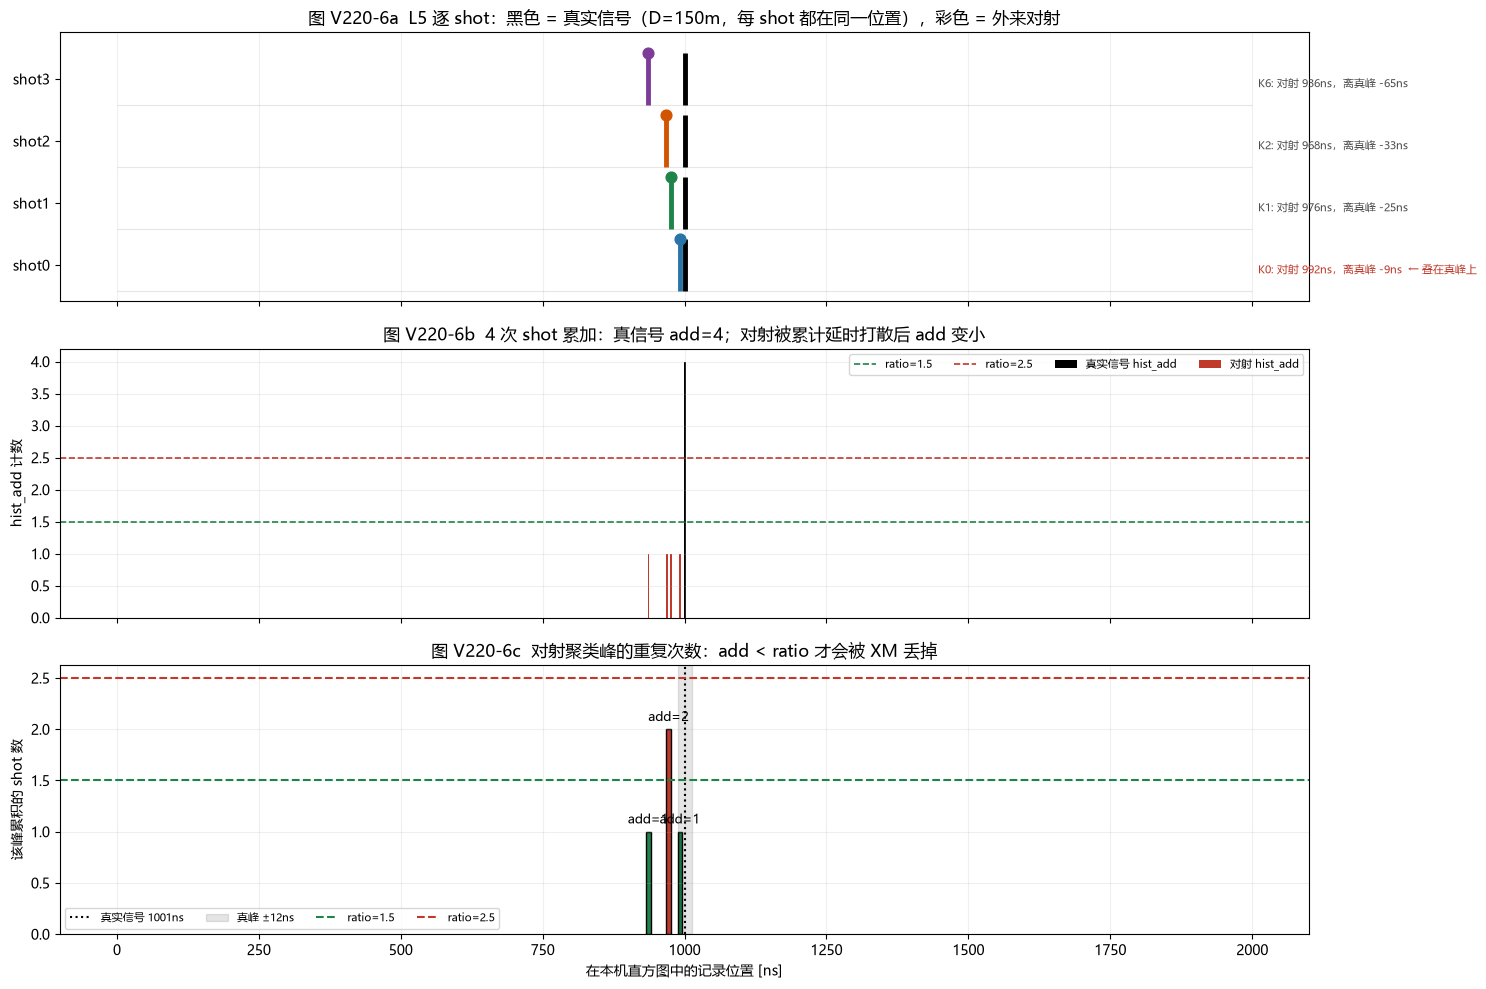

8. L5：真实信号在 1000.7 ns（D=150m）
  对射落点 = [992.0, 976.0, 968.0, 936.0] ns
  其中与真峰重叠（|Δ| < 12ns）的有 1 次
  -> 对射叠到真峰上：这一部分靠 XM 是分不开的，只能靠改相位/一字滤波


In [31]:
# ============================================================================
# 8. 一次雷达对射：真实信号 + 对射落点 + XM 聚类
# ============================================================================
KICK_PERIOD_NS = KICK_SPACING / NS      # 外来雷达同频，落点对它取模
V220_DEMO_D = XM_DEMO_D                 # 沿用 v13/v20 演示距离，便于对照

def cluster_positions(positions, sep_ns):
    # 按峰宽把相邻落点聚成峰；返回 [[position...], ...]。
    if len(positions) == 0:
        return []
    pos = sorted(float(x) for x in positions)
    clusters = [[pos[0]]]
    for x in pos[1:]:
        if x - clusters[-1][-1] < sep_ns:
            clusters[-1].append(x)
        else:
            clusters.append([x])
    return clusters

def radar_positions_for_laser(lid, cumulative, phase_ns=RADAR_PHASE_NS,
                              wrap=True):
    # 同频对射：脉冲每 KICK_PERIOD_NS 到一次，记录位置对周期取模；
    # 只有落进 [0, TOF_WINDOW] 才会被记录。
    kicks = SHOT_KICKS[lid]
    positions = np.array([phase_ns - cumulative[lid-1, k] for k in kicks],
                         dtype=float)
    if wrap:
        positions = np.mod(positions, KICK_PERIOD_NS)
    visible = positions[(positions >= 0) & (positions <= TOF_WINDOW / NS)]
    return kicks, positions, visible


def true_signal_position_ns(D):
    # 真回波 rec_tof = 2D/c，与编码、与 FPGA 延时都无关（发射与参考零点一起平移）
    return 2.0 * D / C_LIGHT / NS


demo_lid = 5
demo_kicks, demo_pos, demo_visible = radar_positions_for_laser(demo_lid, cum_demo)
demo_clusters = cluster_positions(demo_visible, RADAR_PULSE_SEP_NS)
true_ns = true_signal_position_ns(V220_DEMO_D)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
colors = ["#2874a6", "#1e8449", "#d35400", "#7d3c98"]

# (a) 逐 shot：真实信号 + 对射，纵向错开，看它们是否叠在一起
ax = axes[0]
for i, (kick, pos) in enumerate(zip(demo_kicks, demo_pos)):
    y = i * 1.2
    ax.hlines(y, 0, TOF_WINDOW / NS, color="0.9", lw=0.8, zorder=0)
    ax.vlines(true_ns, y, y + 1, color="black", lw=3.5, zorder=3)
    ax.vlines(pos, y, y + 1, color=colors[i], lw=3.5, zorder=3)
    ax.scatter([pos], [y + 1], color=colors[i], s=60, zorder=4)
    overlap = abs(pos - true_ns) < RADAR_PULSE_SEP_NS
    ax.text(TOF_WINDOW / NS * 1.005, y + 0.4,
            f"K{kick}: 对射 {pos:.0f}ns，离真峰 {pos-true_ns:+.0f}ns"
            + ("  ← 叠在真峰上" if overlap else ""),
            fontsize=8, va="center",
            color="#c0392b" if overlap else "0.3")
ax.set_ylim(-0.2, len(demo_kicks) * 1.2 + 0.2)
ax.set_yticks([i * 1.2 + 0.5 for i in range(len(demo_kicks))])
ax.set_yticklabels([f"shot{i}" for i in range(len(demo_kicks))])
ax.set_title(f"图 V220-6a  L{demo_lid} 逐 shot：黑色 = 真实信号（D={V220_DEMO_D:.0f}m，"
             f"每 shot 都在同一位置），彩色 = 外来对射")
ax.grid(alpha=0.2, axis="x")

# (b) 4 次 shot 累加后的直方图：真信号累到 4，对射被推散
ax = axes[1]
bin_ns = HIST_BIN_NS
n_bin = int(TOF_WINDOW / NS / bin_ns)
edges = np.arange(n_bin + 1) * bin_ns
add_true = np.zeros(n_bin)
add_radar = np.zeros(n_bin)
add_true[min(int(true_ns / bin_ns), n_bin - 1)] += len(demo_kicks)
for pos in demo_visible:
    add_radar[min(int(pos / bin_ns), n_bin - 1)] += 1
centers = edges[:-1] + bin_ns / 2
ax.bar(centers, add_true, width=bin_ns * 3, color="black", label="真实信号 hist_add")
ax.bar(centers, add_radar, width=bin_ns * 3, color="#c0392b", label="对射 hist_add")
ax.axhline(RADAR_PULSE_SEP_NS * 0 + 1.5, color="#1e8449", ls="--", lw=1.2,
           label="ratio=1.5")
ax.axhline(2.5, color="#c0392b", ls="--", lw=1.2, label="ratio=2.5")
ax.set_ylabel("hist_add 计数")
ax.set_title("图 V220-6b  4 次 shot 累加：真信号 add=4；对射被累计延时打散后 add 变小")
ax.legend(ncol=4, fontsize=8); ax.grid(alpha=0.2)

# (c) 聚类后每个对射峰的重复次数
ax = axes[2]
for cluster in demo_clusters:
    center = np.mean(cluster)
    ax.bar(center, len(cluster), width=max(4, RADAR_PULSE_SEP_NS * 0.7),
           color="#c0392b" if len(cluster) >= 2 else "#1e8449",
           edgecolor="black")
    ax.text(center, len(cluster) + 0.08, f"add={len(cluster)}",
            ha="center", fontsize=9)
ax.axvline(true_ns, color="black", ls=":", lw=1.5,
           label=f"真实信号 {true_ns:.0f}ns")
ax.axvspan(true_ns - RADAR_PULSE_SEP_NS, true_ns + RADAR_PULSE_SEP_NS,
           color="black", alpha=0.10, label=f"真峰 ±{RADAR_PULSE_SEP_NS}ns")
ax.axhline(1.5, color="#1e8449", ls="--", label="ratio=1.5")
ax.axhline(2.5, color="#c0392b", ls="--", label="ratio=2.5")
ax.set_xlabel("在本机直方图中的记录位置 [ns]")
ax.set_ylabel("该峰累积的 shot 数")
ax.set_title("图 V220-6c  对射聚类峰的重复次数：add < ratio 才会被 XM 丢掉")
ax.legend(ncol=4, fontsize=8); ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

n_overlap = int(np.sum(np.abs(demo_pos - true_ns) < RADAR_PULSE_SEP_NS))
print(f"8. L{demo_lid}：真实信号在 {true_ns:.1f} ns（D={V220_DEMO_D:.0f}m）")
print(f"  对射落点 = {[round(float(p),1) for p in demo_pos]} ns")
print(f"  其中与真峰重叠（|Δ| < {RADAR_PULSE_SEP_NS}ns）的有 {n_overlap} 次")
if n_overlap:
    print("  -> 对射叠到真峰上：这一部分靠 XM 是分不开的，只能靠改相位/一字滤波")


9. 累计 FPGA 对射蒙卡
   峰宽 SEP=12ns，步长=8ns => 单个增量要跨过峰宽必须 ≥ 16ns，即 N ≥ 3
    N    P(单增量≥SEP)     MC残留|命中 r1.5    解析 r1.5     MC残留|命中 r2.5      命中率       平均最大累计
  --------------------------------------------------------------------------------------------
    1          0.00          100.00%    100.00%          100.00%    90.7%          8ns
    2          0.00           98.80%    100.00%           98.44%    91.9%        100ns
    3          0.33           88.83%     91.01%           47.53%    93.5%        182ns
    4          0.50           75.53%     78.29%           27.07%    94.2%        263ns
    5          0.60           64.41%     67.69%           17.47%    95.2%        344ns
    6          0.67           56.03%     59.31%           12.20%    96.3%        424ns
    8          0.75           43.80%     47.29%            6.88%    97.8%        585ns


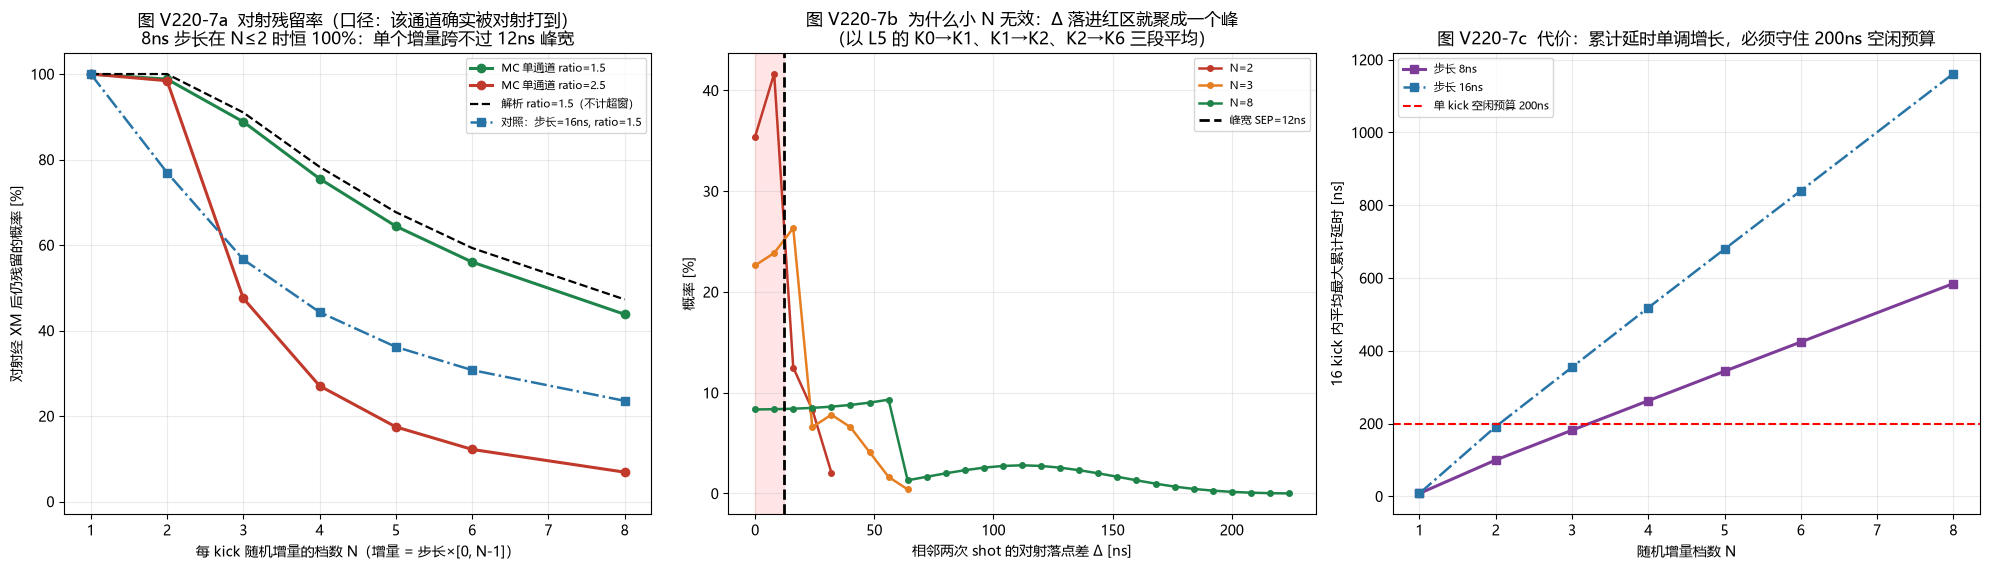


解读：
  1) 8ns 步长 + 12ns 峰宽：单个增量只有取到 16ns 以上才算「分开」，
     所以 N=1,2 残留 100%，与随机空间有 2^16 种无关 —— 卡的是【一步的大小】。
  2) 大多数激光器有 3 个连续 kick（如 L5 的 K0,K1,K2），这两段间隔各只有 1 个增量，
     是整条链上最难分开的地方，决定了整体残留率。
  3) 把步长提到 16ns，N=2 就能大幅压低残留，但累计延时也翻倍，
     要同时看图 V220-7c 的 200ns 预算线。


In [32]:
# ============================================================================
# 9. 为什么 N 小的时候滤不掉对射：解析 + 蒙特卡洛
# ============================================================================
# 结论先写在前面：
#   累计延时单调递增 => 同一激光器 4 次 shot 的对射落点按 kick 顺序单调排列。
#   所以只要【相邻两次 shot】的落点差 >= SEP，就不会聚成一个峰。
#   相邻两次 shot 的落点差 = 这两个 kick 之间所有增量之和 Δ。
#   对相邻 kick（如 L5 的 K0->K1），Δ 就是【单个增量 ξ】。
#   ξ ∈ 8×{0..N-1}；要 ξ >= SEP=12ns 必须 ξ >= 16ns，即 N >= 3。
#   => N=1,2 时相邻 kick 的对射【必然】重合，add>=2，ratio=1.5/2.5 都滤不掉。
#   这与「累计 16 个 kick 的随机空间有 N^16 种」无关。
FPGA_STEP_CONTRAST_NS = 16   # 仅作对照：把步长提到一步就能跨过峰宽

def survives_xm_unit_pulses(positions, ratio, sep_ns):
    # 每个 shot 一个单位脉冲；任一聚类峰的 shot 数 >= ratio 即有残留。
    clusters = cluster_positions(positions, sep_ns)
    return any(len(c) >= ratio for c in clusters)


def sum_increment_pmf(m, n_levels, step_ns):
    # m 个独立增量之和的分布；返回 (取值[ns], 概率)
    pmf = np.array([1.0])
    single = np.ones(n_levels) / n_levels
    for _ in range(m):
        nxt = np.zeros(len(pmf) + n_levels - 1)
        for i, p in enumerate(pmf):
            if p:
                nxt[i:i + n_levels] += p * single
        pmf = nxt
    return np.arange(len(pmf)) * step_ns, pmf


def analytic_survive_ratio15(n_levels, step_ns, sep_ns):
    # ratio=1.5 => 只要任意相邻两 shot 落点差 < sep 就残留
    per_laser = []
    for lid in laser_ids:
        ks = SHOT_KICKS[lid]
        p_all_separated = 1.0
        for ka, kb in zip(ks[:-1], ks[1:]):
            vals, pmf = sum_increment_pmf(kb - ka, n_levels, step_ns)
            p_all_separated *= float(pmf[vals >= sep_ns].sum())
        per_laser.append(1.0 - p_all_separated)
    return float(np.mean(per_laser))


def monte_carlo_radar_cumulative(n_levels, ratio, n_trials, rng, step_ns=None):
    survive_module = survive_channels = hit_channels = survive_given_hit = 0
    max_delay_sum = 0.0
    for _ in range(n_trials):
        increments, cumulative = generate_fpga_cumulative(
            n_levels, rng, step_ns=step_ns)
        max_delay_sum += cumulative.max()
        trial_survive = False
        # 外来雷达与我们同频：相对相位在【整个 kick 周期】内均匀
        phase = rng.uniform(0, KICK_PERIOD_NS)
        for lid in laser_ids:
            _, _, visible = radar_positions_for_laser(lid, cumulative, phase)
            hit = len(visible) > 0
            hit_channels += int(hit)
            channel_survives = survives_xm_unit_pulses(
                visible, ratio, RADAR_PULSE_SEP_NS)
            survive_channels += int(channel_survives)
            if hit:
                survive_given_hit += int(channel_survives)
            if channel_survives:
                trial_survive = True
        survive_module += int(trial_survive)
    n_ch = n_trials * N_LASERS
    return {
        "p_hit_channel": hit_channels / n_ch,
        "p_survive_channel": survive_channels / n_ch,
        "p_survive_given_hit": survive_given_hit / max(hit_channels, 1),
        "p_survive_module": survive_module / n_trials,
        "mean_max_delay": max_delay_sum / n_trials,
    }


N_LEVEL_LIST = [1, 2, 3, 4, 5, 6, 8]
MC_ROWS, MC_CONTRAST = [], []
rng_mc = np.random.default_rng(FPGA_RANDOM_SEED + 1)

print("9. 累计 FPGA 对射蒙卡")
print(f"   峰宽 SEP={RADAR_PULSE_SEP_NS}ns，步长={FPGA_STEP_NS}ns "
      f"=> 单个增量要跨过峰宽必须 ≥ {int(np.ceil(RADAR_PULSE_SEP_NS/FPGA_STEP_NS))*FPGA_STEP_NS}ns，"
      f"即 N ≥ {int(np.ceil(RADAR_PULSE_SEP_NS/FPGA_STEP_NS))+1}")
print(f"  {'N':>3} {'P(单增量≥SEP)':>13} {'MC残留|命中 r1.5':>16} "
      f"{'解析 r1.5':>10} {'MC残留|命中 r2.5':>16} {'命中率':>8} {'平均最大累计':>12}")
print("  " + "-" * 92)
for n_level in N_LEVEL_LIST:
    res = {}
    for ratio in (1.5, 2.5):
        res[ratio] = monte_carlo_radar_cumulative(
            n_level, ratio, FPGA_MC_TRIALS, rng_mc)
        MC_ROWS.append((n_level, ratio, res[ratio]))
    p_step = sum(1 for i in range(n_level)
                 if i * FPGA_STEP_NS >= RADAR_PULSE_SEP_NS) / n_level
    ana = analytic_survive_ratio15(n_level, FPGA_STEP_NS, RADAR_PULSE_SEP_NS)
    print(f"  {n_level:>3d} {p_step:>13.2f} {res[1.5]['p_survive_given_hit']:>16.2%} "
          f"{ana:>10.2%} {res[2.5]['p_survive_given_hit']:>16.2%} "
          f"{res[1.5]['p_hit_channel']:>8.1%} "
          f"{res[1.5]['mean_max_delay']:>10.0f}ns")

# 对照：把步长从 8ns 提到 16ns（一步即可跨过 12ns 峰宽），其余不变
rng_c = np.random.default_rng(FPGA_RANDOM_SEED + 2)
for n_level in N_LEVEL_LIST:
    MC_CONTRAST.append((n_level, monte_carlo_radar_cumulative(
        n_level, 1.5, max(FPGA_MC_TRIALS // 4, 1000), rng_c,
        step_ns=FPGA_STEP_CONTRAST_NS)))

fig, axes = plt.subplots(1, 3, figsize=(20, 5.8))

# (a) 残留概率
ax = axes[0]
for ratio, color in [(1.5, "#1e8449"), (2.5, "#c0392b")]:
    rows = [(n, r) for n, rr, r in MC_ROWS if rr == ratio]
    ax.plot([n for n, _ in rows], [r["p_survive_given_hit"] * 100 for _, r in rows],
            "o-", lw=2.2, color=color, label=f"MC 单通道 ratio={ratio}")
ax.plot(N_LEVEL_LIST,
        [analytic_survive_ratio15(n, FPGA_STEP_NS, RADAR_PULSE_SEP_NS) * 100
         for n in N_LEVEL_LIST],
        "k--", lw=1.6, label="解析 ratio=1.5（不计超窗）")
ax.plot([n for n, _ in MC_CONTRAST],
        [r["p_survive_given_hit"] * 100 for _, r in MC_CONTRAST],
        "s-.", lw=1.8, color="#2874a6",
        label=f"对照：步长={FPGA_STEP_CONTRAST_NS}ns, ratio=1.5")
ax.set_xlabel(f"每 kick 随机增量的档数 N（增量 = 步长×[0, N-1]）")
ax.set_ylabel("对射经 XM 后仍残留的概率 [%]")
ax.set_title("图 V220-7a  对射残留率（口径：该通道确实被对射打到）\n"
             "8ns 步长在 N≤2 时恒 100%：单个增量跨不过 12ns 峰宽")
ax.set_ylim(-3, 105)
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# (b) 相邻 shot 落点差的分布（诊断图）
ax = axes[1]
demo_pairs = [(0, 1), (1, 2), (2, 6)]     # L5 的三段相邻 shot 间隔
for n_level, color in [(2, "#c0392b"), (3, "#e67e22"), (8, "#1e8449")]:
    vals_all, pmf_all = [], []
    for ka, kb in demo_pairs:
        vals, pmf = sum_increment_pmf(kb - ka, n_level, FPGA_STEP_NS)
        vals_all.append(vals); pmf_all.append(pmf)
    m = max(len(p) for p in pmf_all)
    agg = np.zeros(m)
    for p in pmf_all:
        agg[:len(p)] += p / len(pmf_all)
    ax.plot(np.arange(m) * FPGA_STEP_NS, agg * 100, "o-", color=color,
            lw=1.8, ms=4, label=f"N={n_level}")
ax.axvline(RADAR_PULSE_SEP_NS, color="black", ls="--", lw=2,
           label=f"峰宽 SEP={RADAR_PULSE_SEP_NS}ns")
ax.axvspan(0, RADAR_PULSE_SEP_NS, color="red", alpha=0.10)
ax.set_xlabel("相邻两次 shot 的对射落点差 Δ [ns]")
ax.set_ylabel("概率 [%]")
ax.set_title("图 V220-7b  为什么小 N 无效：Δ 落进红区就聚成一个峰\n"
             "（以 L5 的 K0→K1、K1→K2、K2→K6 三段平均）")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# (c) 延时预算
ax = axes[2]
rows15 = [(n, r) for n, rr, r in MC_ROWS if rr == 1.5]
ax.plot([n for n, _ in rows15], [r["mean_max_delay"] for _, r in rows15],
        "s-", lw=2.2, color="#7d3c98", label=f"步长 {FPGA_STEP_NS}ns")
ax.plot([n for n, _ in MC_CONTRAST], [r["mean_max_delay"] for _, r in MC_CONTRAST],
        "s-.", lw=1.8, color="#2874a6", label=f"步长 {FPGA_STEP_CONTRAST_NS}ns")
ax.axhline((KICK_SPACING - TOF_WINDOW) / NS, color="red", ls="--",
           label="单 kick 空闲预算 200ns")
ax.set_xlabel("随机增量档数 N")
ax.set_ylabel("16 kick 内平均最大累计延时 [ns]")
ax.set_title("图 V220-7c  代价：累计延时单调增长，必须守住 200ns 空闲预算")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print()
print("解读：")
print(f"  1) 8ns 步长 + {RADAR_PULSE_SEP_NS}ns 峰宽：单个增量只有取到 16ns 以上才算「分开」，")
print(f"     所以 N=1,2 残留 100%，与随机空间有 2^16 种无关 —— 卡的是【一步的大小】。")
print("  2) 大多数激光器有 3 个连续 kick（如 L5 的 K0,K1,K2），这两段间隔各只有 1 个增量，")
print("     是整条链上最难分开的地方，决定了整体残留率。")
print(f"  3) 把步长提到 {FPGA_STEP_CONTRAST_NS}ns，N=2 就能大幅压低残留，但累计延时也翻倍，")
print("     要同时看图 V220-7c 的 200ns 预算线。")


In [33]:
# ============================================================================
# 10. v220 总结
# ============================================================================
print("=" * 82)
print("v220 总结")
print("=" * 82)
print(f'''
1. 模组内串扰：
   - ratio=1.5 使用 56ns tcode
   - ratio=2.5 使用 24ns tcode
   - 两套都满足：同类鬼影间隔 ≥ 12ns，且鬼影离真峰 ≥ 12ns

2. FPGA 模型已纠正：
   - random_increment 是本 kick 新增随机量
   - actual_delay = 8ns 整体补偿 + 从 K0 到当前 kick 的全部增量之和
   - 例：16ns 后再加 8ns，实际累计为 24ns

3. 雷达对射：
   - tcode 不控制外来雷达
   - 累计 FPGA 延时让对射峰在多个 shot 间移动，再由 XM 判断
   - ratio=1.5 对双碰敏感；ratio=2.5 允许双碰但不允许三碰
   - 对射有可能直接叠在真峰上（见图 V220-6），那一部分 XM 分不开

4. 决定滤除效果的不是随机空间大小，而是【一步的大小】：
   - 累计延时单调递增 -> 4 次 shot 落点单调排列 -> 只需相邻两次分开
   - 相邻 kick 之间只有一个增量 ξ，要跨过 12ns 峰宽必须 ξ ≥ 16ns
   - 8ns 步长下 N=1,2 的 ξ 只能取 0 或 8ns，恒 < 12ns -> 残留 100%
   - 解析式与蒙卡在图 V220-7a 中重合，说明这是模型必然，不是统计噪声

5. 工程约束：
   - 增量档数 N 增大，随机性更强
   - 但累计延时随 kick 单调增长，必须同时检查 200ns 空闲预算
   - 提高步长（如 16ns）能用很小的 N 解决问题，代价是累计延时翻倍

6. 下一步：
   - tcode + 累计 FPGA 的联合模组内/外来雷达仿真（见 v23）
   - 连续三个角度的一字滤波（见 v24）
''')


v220 总结

1. 模组内串扰：
   - ratio=1.5 使用 56ns tcode
   - ratio=2.5 使用 24ns tcode
   - 两套都满足：同类鬼影间隔 ≥ 12ns，且鬼影离真峰 ≥ 12ns

2. FPGA 模型已纠正：
   - random_increment 是本 kick 新增随机量
   - actual_delay = 8ns 整体补偿 + 从 K0 到当前 kick 的全部增量之和
   - 例：16ns 后再加 8ns，实际累计为 24ns

3. 雷达对射：
   - tcode 不控制外来雷达
   - 累计 FPGA 延时让对射峰在多个 shot 间移动，再由 XM 判断
   - ratio=1.5 对双碰敏感；ratio=2.5 允许双碰但不允许三碰
   - 对射有可能直接叠在真峰上（见图 V220-6），那一部分 XM 分不开

4. 决定滤除效果的不是随机空间大小，而是【一步的大小】：
   - 累计延时单调递增 -> 4 次 shot 落点单调排列 -> 只需相邻两次分开
   - 相邻 kick 之间只有一个增量 ξ，要跨过 12ns 峰宽必须 ξ ≥ 16ns
   - 8ns 步长下 N=1,2 的 ξ 只能取 0 或 8ns，恒 < 12ns -> 残留 100%
   - 解析式与蒙卡在图 V220-7a 中重合，说明这是模型必然，不是统计噪声

5. 工程约束：
   - 增量档数 N 增大，随机性更强
   - 但累计延时随 kick 单调增长，必须同时检查 200ns 空闲预算
   - 提高步长（如 16ns）能用很小的 N 解决问题，代价是累计延时翻倍

6. 下一步：
   - tcode + 累计 FPGA 的联合模组内/外来雷达仿真（见 v23）
   - 连续三个角度的一字滤波（见 v24）

